In [110]:
import os
import yaml

def load_yaml(filename: str) -> dict:
    """Loads an input PKL file safely.

    Args:
        filename: The path to pickled file.

    Raises:
        FileNotFoundError: When the specified file does not exist.

    Returns:
        The data read from the input file.
    """
    if not os.path.exists(filename):
        raise FileNotFoundError(f"File not found: {filename}")
    with open(filename) as f:
        data = yaml.full_load(f)
    return data

In [111]:
import torch

def convert_tensors_to_lists(obj):
    """
    Recursively traverse a nested structure (dict, list, etc.) 
    and convert all PyTorch tensors to Python lists.
    """
    # Case 1: If `obj` is a dictionary, process each key-value pair
    if isinstance(obj, dict):
        for k, v in obj.items():
            obj[k] = convert_tensors_to_lists(v)
        return obj

    # Case 2: If `obj` is a list (or tuple), process each element
    elif isinstance(obj, (list, tuple)):
        converted_list = []
        for item in obj:
            converted_list.append(convert_tensors_to_lists(item))
        # If original was a tuple, convert back to tuple. Otherwise return list.
        return tuple(converted_list) if isinstance(obj, tuple) else converted_list

    # Case 3: If `obj` is a PyTorch tensor, convert to Python list
    elif torch.is_tensor(obj):
        return obj.tolist()

In [112]:
import random

# Function to calculate task success rate through sub-sampling with replacement
def calculate_subsampled_success_rate(data, num_samples):
    num_tasks = len(data[0]["success_list"])  # Number of tasks
    success_rates = []

    # Repeat sub-sampling num_samples times
    for _ in range(num_samples):
        success_rate = [0.0] * num_tasks

        # Sub-sample with replacement from the data
        sampled_runs = random.choices(data, k=len(data))  # Randomly choose runs with replacement

        # Calculate success rate for the sampled runs
        for run in sampled_runs:
            for task in range(len(run["success_list"])):
                success_rate[task] += run["success_list"][task]

        # Normalize by the number of sampled runs
        success_rate = [x / len(sampled_runs) for x in success_rate]
        success_rates.append(success_rate)

    return success_rates

In [113]:
def calculate_subsampled_cylinder_contact_rate(data, num_samples):
    num_tasks = len(data[0]["cylinder_contact_list_per_env"])  # Number of tasks (environments)
    cylinder_contact_rates = []

    # Repeat sub-sampling num_samples times
    for _ in range(num_samples):
        cylinder_contacts = [0] * num_tasks

        # Sub-sample with replacement from the data
        sampled_runs = random.choices(data, k=len(data))  # Randomly choose runs with replacement

        # Calculate cylinder contact rate for the sampled runs
        for run in sampled_runs:
            for task in range(len(run["cylinder_contact_list_per_env"])):
                cylinder_contacts[task] += run["cylinder_contact_list_per_env"][task]

        # Normalize by the number of sampled runs
        cylinder_contact_rate = [x / len(sampled_runs) for x in cylinder_contacts]
        cylinder_contact_rates.append(cylinder_contact_rate)

    return cylinder_contact_rates

In [114]:
def calculate_subsampled_quantity(data, num_samples, keys):
    
    quantities = []
    # print(f"num_tasks: {num_tasks}")
    
    random.seed(42)  # Set seed for reproducibility

    # Repeat sub-sampling num_samples times
    for _ in range(num_samples):
        if type(keys) == str:
            # print(f"data[0]: {data[0]}")
            num_tasks = len(data[0][keys])  # Number of tasks
        elif type(keys) == list:
            num_tasks = len(data[0][keys[0]])
        quantity = [0.0] * num_tasks

        # Sub-sample with replacement from the data
        sampled_runs = random.choices(data, k=len(data))  # Randomly choose runs with replacement

        # Calculate quantity for the sampled runs
        if type(keys) == str:
            # print(f"keys: {keys}")
            for run in sampled_runs:
                for task in range(len(run[keys])):
                    quantity[task] += run[keys][task]
                    # if keys == "cumulative_rewards":
                    #     quantity[task] -= run["end_effector_position_tracking_shaped_per_env"][task]
        elif type(keys) == list:
            for run in sampled_runs:
                for key in keys:
                    for task in range(len(run[key])):
                        quantity[task] += run[key][task]

        # Normalize by the number of sampled runs
        quantity = [x / len(sampled_runs) for x in quantity]
        quantities.append(quantity)
        
    # print(f"Quantities: {quantities}")
    
    return quantities

In [115]:
def calculate_subsampled_time_quantity(data, num_samples, keys):
    
    quantities = []
    # print(f"num_tasks: {num_tasks}")
    
    random.seed(42)  # Set seed for reproducibility

    # Repeat sub-sampling num_samples times
    for _ in range(num_samples):
        if type(keys) == str:
            # print(f"data[0]: {data[0]}")
            num_tasks = len(data[0][keys])  # Number of tasks
        elif type(keys) == list:
            num_tasks = len(data[0][keys[0]])
        quantity = [0.0] * num_tasks

        # Sub-sample with replacement from the data
        sampled_runs = random.choices(data, k=len(data))  # Randomly choose runs with replacement

        # times_idx_counter = [0] * num_tasks
        # create num_runs x num_tasks times_idx_counter
        times_idx_counter = [[0] * num_tasks for _ in range(len(sampled_runs))]
        
        # Calculate quantity for the sampled runs
        if type(keys) == str:
            # print(f"keys: {keys}")
            for run_idx, run in enumerate(sampled_runs):
                # print(f"run[keys]: {run[keys]}")
                
                for task in range(len(run[keys])):
                    if run[keys][task] != 0.0:
                        # print(f"run[keys][task]: {run[keys][task]}")
                        quantity[task] += run[keys][task]
                        times_idx_counter[run_idx][task] += 1
                # times_idx_counter[task] = 0
        elif type(keys) == list:
            for run in sampled_runs:
                for key in keys:
                    for task in range(len(run[keys])):
                        if run[keys][task]:
                            quantity[task] += run[key][task] # [times_idx_counter[run_idx][task]]
                            times_idx_counter[run_idx][task] += 1
                    # times_idx_counter[task] = 0
        # Normalize by the number of sampled runs
        # caclculate the total number of times for each task the quantity was sampled (shaped like num_tasks)
        times_idx_counter = [sum(x) for x in zip(*times_idx_counter)]  
        # prevent division by zero
        times_idx_counter = [x if x > 0 else 1 for x in times_idx_counter]
        
        quantity = [x / times_idx_counter[idx] for idx, x in enumerate(quantity)]
        
        quantities.append(quantity)
        
    # print(f"Quantities: {quantities}")
    
    return quantities

In [116]:
# Get the data from the YAML file

import numpy as np

# aim is to generate matrices for statistics in the shape of
# [num_runs x num_tasks x ...]
# success_rate = [None] * len(data[0]["success_rate"])
def read_from_yaml(filename: str, rliable_data: np.array, algorithm: str, statistic: str) -> dict:
    """This function formats data from a yaml file into the format for rliable plotting.
    
    It takes a dictionary containing data from other algorithms, and adds the data from the new algorithm.
    
    Args:
        filename: The path to the yaml file.
        rliable_data: A dictionary containing data from other algorithms. Can be empty to start with.
        algorithm: The name of the algorithm to be added.
        statistic: The statistic to be added.
        
    Returns:
        A dictionary containing the data from all processes algorithms thusfar.
    """
    data = load_yaml(filename)
    num_samples  = 10

    cumulative_rewards = [None] * len(data)
    per_step_rewards = [None] * len(data)
    time_out_list_per_env = [None] * len(data)
    cylinder_contact_list_per_env = [None] * len(data)
    env_contacts = [None] * len(data)
    env_cylinder_contacts = [None] * len(data)
    # give_up_list_per_env = [None] * len(data)
    success_list = [None] * len(data)
    failed_list = [None] * len(data)
    success_times = [None] * len(data)
    failed_times = [None] * len(data)
    all_times = [None] * len(data)
    chosen_data = None
    
    per_env_quantities = {}
    
    all_quantities = {}
    
    # initialise the per_env_quantities keys and values
    for key in data[0].keys():
        if "per_env" in key:
            per_env_quantities.update({key: [None] * len(data)})
            
    for key in data[0].keys():
        all_quantities.update({key: [None] * len(data)})

    if "lift" not in filename: 
        for idx, run in enumerate(data.values()):
            success_list[idx] = run["success_list"]
            failed_list[idx] = run["failed_list"]
            # success_times[idx] = run["success_times"]
            # failed_times[idx] = run["failed_times"]
            all_times[idx] = run["all_times"]

            cumulative_rewards[idx] = run["cumulative_rewards"]
            per_step_rewards[idx] = run["per_step_rewards"]
            time_out_list_per_env[idx] = run["time_out_list_per_env"]
            cylinder_contact_list_per_env[idx] = run["cylinder_contact_list_per_env"]
            # give_up_list_per_env[idx] = run["give_up_list_per_env"]
            env_contacts[idx] = run["env_contact_list_per_env"]
            # print(f"run['env_contact_list_per_env']: {run['env_contact_list_per_env']}")
            # print(f"run['cylinder_contact_list_per_env']: {run['cylinder_contact_list_per_env']}")
            # print(f"run[env_contact_list_per_env] or run[cylinder_contact_list_per_env]: {run['env_contact_list_per_env'] or run['cylinder_contact_list_per_env']}")
            # env_cylinder_contacts[idx] = run["env_contact_list_per_env"] or run["cylinder_contact_list_per_env"]
            # print(f"run['env_contact_list_per_env'] or run['cylinder_contact_list_per_env']: {run['env_contact_list_per_env'] or run['cylinder_contact_list_per_env']}")

            # add the per_env quantities to the dictionary
            for key in run.keys():
                if "per_env" in key:
                    per_env_quantities[key][idx] = run[key]

                if statistic == "all":
                    all_quantities[key][idx] = run[key]
                    
        # env_cylinder_contacts = [[x or y for x, y in zip(a, b)] for a, b in zip(run["env_contact_list_per_env"], run["cylinder_contact_list_per_env"])]

    else:
        
        for idx, run in enumerate(data.values()):
            success_list[idx] = run["success_list"]
            failed_list[idx] = run["failed_list"]
            success_times[idx] = run["success_times"]
            time_out_list_per_env[idx] = run["time_out_list_per_env"]
            failed_times[idx] = run["failed_times"]
            all_times[idx] = run["all_times"]
            cumulative_rewards[idx] = run["cumulative_rewards"]
            env_contacts[idx] = run["env_contact_list_per_env"]
            
            
            
            # add the per_env quantities to the dictionary
            for key in run.keys():
                if "per_env" in key:
                    per_env_quantities[key][idx] = run[key]

                if statistic == "all":
                    all_quantities[key][idx] = run[key]


    # swith case for the statistic
    if statistic == "cumulative_rewards":
        chosen_data = cumulative_rewards
        # cumulative_rewards = calculate_subsampled_quantity(data, num_samples, "cumulative_rewards")
        # chosen_data = np.expand_dims(cumulative_rewards, 2)
        
        # new
        cumulative_rewards = np.array(cumulative_rewards)
        task_cumulative_rewards = cumulative_rewards.mean(axis=0)
        chosen_data = np.expand_dims(task_cumulative_rewards, 1)
        # chosen_data = np.expand_dims(task_cumulative_rewards, 1)
        
    elif statistic == "per_step_rewards":
        chosen_data = per_step_rewards
    elif statistic == "success_rate":
        # calculate the success rate for each task
        # success_list shape: [num_runs x num_tasks]
        # success_rates = calculate_subsampled_quantity(data, num_samples, "success_list")
        # chosen_data = np.expand_dims(success_rates, 2) 
        
        # new 
        success_scores = np.array(success_list)
        task_success_rate = success_scores.mean(axis=0)
        chosen_data = np.expand_dims(task_success_rate, 1) 

    elif statistic == "time_out_list_per_env":
        # time_outs = [0] * len(data[0]["time_out_list_per_env"])
        # for run in range(len(data)):
        #     for task in range(len(data[run]["time_out_list_per_env"])):
        #         time_outs[task] += data[run]["time_out_list_per_env"][task]
            
        # time_out_rates = calculate_subsampled_quantity(data, num_samples, "time_out_list_per_env")
        # # print(f"time out rates shape: {np.array(time_out_rates).shape}")
        # chosen_data = np.expand_dims(time_out_rates, 2)
        
        # new
        time_outs = np.array(time_out_list_per_env)
        task_time_out_rate = time_outs.mean(axis=0)
        chosen_data = np.expand_dims(task_time_out_rate, 1)

    elif statistic == "cylinder_contact_rate":
        # cylinder_contact_rates = calculate_subsampled_cylinder_contact_rate(data, 100)
        # cylinder_contact_rates = calculate_subsampled_quantity(data, num_samples, "cylinder_contact_list_per_env")
        # chosen_data = np.expand_dims(cylinder_contact_rates, 2)
        
        # new
        cylinder_contacts = np.array(cylinder_contact_list_per_env)
        task_cylinder_contact_rate = cylinder_contacts.mean(axis=0)
        chosen_data = np.expand_dims(task_cylinder_contact_rate, 1)
        
    elif statistic == "env_cylinder_contacts":
        # env_cylinder_contacts = [0] * len(data[0]["env_contact_list_per_env"])
        # for run in range(len(data)):
        #     for task in range(len(data[run]["env_contact_list_per_env"])):
        #         env_cylinder_contacts[task] += (data[run]["env_contact_list_per_env"][task] or data[run]["cylinder_contact_list_per_env"][task])
        # # cylinder_contact_rates = calculate_subsampled_cylinder_contact_rate(data, 100)
        # env_cylinder_contact_rates = calculate_subsampled_quantity(data, num_samples, ["cylinder_contact_list_per_env", "env_contact_list_per_env"])
        # chosen_data = np.expand_dims(env_cylinder_contact_rates, 2)
        
        # new
        cylinder_contacts = np.array(cylinder_contact_list_per_env)
        env_contacts = np.array(env_contacts)
        print(f"env_contacts: {env_contacts[0][:5]}")
        print(f"cylinder_contacts: {cylinder_contacts[0][:5]}")
        env_cylinder_contacts = [[x or y for x, y in zip(a, b)] for a, b in zip(env_contacts, cylinder_contacts)]
        print(f"env_cylinder_contacts: {env_cylinder_contacts[0][:5]}")
        env_cylinder_contacts = np.array(env_cylinder_contacts)
        task_env_cylinder_contact_rate = env_cylinder_contacts.mean(axis=0)
        chosen_data = np.expand_dims(task_env_cylinder_contact_rate, 1)
        
    # elif statistic == "give_up_rate":
    #     give_ups = [0] * len(data[0]["give_up_list_per_env"])
    #     for run in range(len(data)):
    #         for task in range(len(data[run]["give_up_list_per_env"])):
    #             give_ups[task] += data[run]["give_up_list_per_env"][task]

    #     # print if any values in give_ups are greater than 0
    #     if any(x > 0 for x in give_ups):
    #         print("Give up list has values greater than 0")
    #         print(give_ups)
    #     # cylinder_contact_rates = calculate_subsampled_cylinder_contact_rate(data, 100)
    #     give_up_rates = calculate_subsampled_quantity(data, num_samples, "give_up_list_per_env")
    #     chosen_data = np.expand_dims(give_up_rates, 2)

    elif statistic == "env_contact_list_per_env":
        # env_contacts = [0] * len(data[0]["env_contact_list_per_env"])
        # for run in range(len(data)):
        #     for task in range(len(data[run]["env_contact_list_per_env"])):
        #         env_contacts[task] += data[run]["env_contact_list_per_env"][task]
        
        # env_contact_rates = calculate_subsampled_quantity(data, num_samples, "env_contact_list_per_env")
        # chosen_data = np.expand_dims(env_contact_rates, 2)
        
        # new
        env_contacts = np.array(env_contacts)
        task_env_contact_rate = env_contacts.mean(axis=0)
        chosen_data = np.expand_dims(task_env_contact_rate, 1)
        
        
    elif statistic == "undesired_contacts_penalty_per_env":
        cumulative_undesired_contact_penalty = [0] * len(data[0]["undesired_contacts_penalty_per_env"])
        for run in range(len(data)):
            for task in range(len(data[run]["undesired_contacts_penalty_per_env"])):
                cumulative_undesired_contact_penalty[task] += data[run]["undesired_contacts_penalty_per_env"][task]
        cumulative_undesired_contact_penalty_rates = calculate_subsampled_quantity(data, num_samples, "undesired_contacts_penalty_per_env")
        chosen_data = np.expand_dims(cumulative_undesired_contact_penalty_rates, 2)
    elif statistic == "success_list":
        chosen_data = success_list
    elif statistic == "failed_list":
        chosen_data = failed_list
    elif statistic == "success_times" and "lift" in filename:
        # chosen_data = success_times
        # success_times = calculate_subsampled_time_quantity(data, num_samples, "success_times")
        # chosen_data = np.expand_dims(success_times, 2)
        print(f"statistic: {statistic}")
        print(f"success_times: {success_times}")
        success_times = np.array(success_times)
        successful_mask = success_times > 0.0
        # ZERO‐OUT the “non‐failures” in each task, then sum _along_ runs
        masked_times = np.where(successful_mask, success_times, 0.0)
        # Now this is shape (n_runs, n_tasks); sum(axis=0) gives one total per task
        masked_total_times = masked_times.sum(axis=0)
        # masked_total_times = success_times[successful_mask].sum(axis=0)
        success_counts = successful_mask.sum(axis=0)
        average_success_time = np.zeros_like(masked_total_times, dtype=float)
        valid = success_counts > 0
        average_success_time[valid] = masked_total_times[valid] / success_counts[valid]
        
        chosen_data = np.expand_dims(average_success_time, 1)
        
    elif statistic == "failed_times" and "lift" in filename:
        # chosen_data = failed_times
        # failed_times = calculate_subsampled_time_quantity(data, num_samples, "failed_times")
        # chosen_data = np.expand_dims(failed_times, 2)
        
        failed_times = np.array(failed_times)
        failed_mask = np.logical_and(failed_times > 0.0,
                             failed_times < 6.0)
        
        
        # ZERO‐OUT the “non‐failures” in each task, then sum _along_ runs
        masked_times = np.where(failed_mask, failed_times, 0.0)
        # Now this is shape (n_runs, n_tasks); sum(axis=0) gives one total per task
        masked_total_times = masked_times.sum(axis=0)

        # masked_total_times = failed_times[failed_mask].sum(axis=0)
        failed_counts = failed_mask.sum(axis=0)
        average_failed_time = np.zeros_like(masked_total_times, dtype=float)
        valid = failed_counts > 0
        average_failed_time[valid] = masked_total_times[valid] / failed_counts[valid]
        chosen_data = np.expand_dims(average_failed_time, 1)
        
    elif statistic == "all_times":
        # chosen_data = all_times
        # all_times = calculate_subsampled_quantity(data, num_samples, "all_times")
        # chosen_data = np.expand_dims(all_times, 2)
        
        all_times = np.array(all_times)
        all_times_average = all_times.mean(axis=0)
        chosen_data = np.expand_dims(all_times_average, 1)
        
    elif "per_env" in statistic:
        if statistic in per_env_quantities.keys():
            statistic_rates = calculate_subsampled_quantity(data, num_samples, statistic)
            chosen_data = np.expand_dims(statistic_rates, 2)
        else:
            raise ValueError(f"Statistic {statistic} not recognised.")
    
    
    elif statistic == "all":
        # get all the data from the yaml file
        all_data = {}
        # print(f"statistic: {statistic}")
        for key in data[0].keys():
            if "Termination" in key or "per_step_rewards" in key or "risk_sensitivity" in key:
                
                continue
            # print(f"key: {key}")
            if "alive" in key:
                alive_key = ["alive_per_env", "padded_alive_per_env"]
                # all_data.update({key: np.expand_dims(calculate_subsampled_quantity(data, num_samples, alive_key), 2)})
                
                alive_reward = np.array(all_quantities["alive_per_env"]) + np.array(all_quantities["padded_alive_per_env"])
                # print(f"all_quantities['alive_per_env']: {all_quantities['alive_per_env']}")
                # print(f"all_quantities['alive_per_env'] len: {len(all_quantities['alive_per_env'])}")
                # print(f"all_quantities['alive_per_env'][0] len: {len(all_quantities['alive_per_env'][0])}")
                # print(f"alive_reward: {alive_reward.shape}")
                alive_reward = np.expand_dims(alive_reward, 2)
                all_data.update({key: alive_reward})
                continue
            if "vel" in key:
                if "static" in key:
                    # vel_key = key
                    # print(f"vel_key: {vel_key}")
                    # all_data.update({key: np.expand_dims(calculate_subsampled_quantity(data, num_samples, vel_key), 2)})
                    all_data.update({key: np.expand_dims(np.array(all_quantities[key]), 2)})
                    # all_data.update({key: np.array(all_quantities[key])})
                    continue
                else:
                    vel_key = ["arm_joint_vel_per_env", "base_vel_per_env"]
                    # print(f"vel_key: {vel_key}")
                    # all_data.update({key: np.expand_dims(calculate_subsampled_quantity(data, num_samples, vel_key), 2)})
                    vel_reward = np.array(all_quantities["arm_joint_vel_per_env"]) + np.array(all_quantities["base_vel_per_env"])
                    vel_reward = np.expand_dims(vel_reward, 2)
                    all_data.update({key: vel_reward})
                    continue
            if "acc" in key:
                if "ee" in key:
                    ee_key = "ee_acc_per_env"
                    # all_data.update({key: np.expand_dims(calculate_subsampled_quantity(data, num_samples, ee_key), 2)})
                    all_data.update({key: np.expand_dims(np.array(all_quantities[ee_key]), 2)})
                    # all_data.update({key: np.array(all_quantities[ee_key])})
                    continue
                else:
                    acc_key = ["arm_joint_acc_per_env", "base_acc_per_env"]
                    # all_data.update({key: np.expand_dims(calculate_subsampled_quantity(data, num_samples, acc_key), 2)})
                    acc_reward = np.array(all_quantities["arm_joint_acc_per_env"]) + np.array(all_quantities["base_acc_per_env"])
                    acc_reward = np.expand_dims(acc_reward, 2)
                    all_data.update({key: acc_reward})
                    continue
            if "success_times" in key and "lift" in filename:
                # all_data.update({key: np.expand_dims(calculate_subsampled_time_quantity(data, num_samples, key), 2)})
                # all_data.update({key: np.expand_dims(calculate_subsampled_quantity(data, num_samples, key), 2)})
                print(f"success_times: {success_times}")
                success_times = np.array(success_times)
                successful_mask = success_times > 0.0
                total_times = success_times.sum(axis=0)
                success_counts = successful_mask.sum(axis=0)
                average_success_time = np.zeros_like(total_times, dtype=float)
                valid = success_counts > 0
                average_success_time[valid] = total_times[valid] / success_counts[valid]
                
                all_data.update({key: np.expand_dims(average_success_time, 1)})
                continue
            if "failed_times" in key and "lift" in filename:
                # all_data.update({key: np.expand_dims(calculate_subsampled_time_quantity(data, num_samples, key), 2)})
                # all_data.update({key: np.expand_dims(calculate_subsampled_quantity(data, num_samples, key), 2)})
                failed_times = np.array(failed_times) # (num_runs, num_tasks)
                failed_mask = np.logical_and(failed_times > 0.0,
                             failed_times < 6.0) # (num_runs, num_tasks)
                # ZERO‐OUT the “non‐failures” in each task, then sum _along_ runs
                masked_times = np.where(failed_mask, failed_times, 0.0) # (num_runs, num_tasks)
                # Now this is shape (n_runs, n_tasks); sum(axis=0) gives one total per task
                masked_total_times = masked_times.sum(axis=0)
                failed_counts = failed_mask.sum(axis=0)
                average_failed_time = np.zeros_like(masked_total_times, dtype=float)
                valid = failed_counts > 0
                average_failed_time[valid] = masked_total_times[valid] / failed_counts[valid]
                all_data.update({key: np.expand_dims(average_failed_time, 1)})
                continue
            if "all_times" in key:
                # all_data.update({key: np.expand_dims(calculate_subsampled_time_quantity(data, num_samples, key), 2)})
                # all_data.update({key: np.expand_dims(calculate_subsampled_quantity(data, num_samples, key), 2)})
                all_times = np.array(all_times)
                all_times_average = all_times.mean(axis=0)
                all_data.update({key: np.expand_dims(all_times_average, 1)})
                continue
            # if "give_up_times" in key:
            #     continue
            if "success_list" in key:
                success_scores = np.array(success_list)
                task_success_rate = success_scores.mean(axis=0)
                all_data.update({"success_rate": np.expand_dims(task_success_rate, 1)})
                continue 
            if "time_out_list_per_env" in key:
                time_outs = np.array(time_out_list_per_env)
                task_time_out_rate = time_outs.mean(axis=0)
                all_data.update({key: np.expand_dims(task_time_out_rate, 1)})
                continue
            if "env_contact_list_per_env" in key:
                env_contacts_array = np.array(env_contacts)
                print(f"env_contacts: {env_contacts}")
                # print(f"env_contacts_array: {env_contacts_array[0][:5]}")
                task_env_contact_rate = env_contacts_array.mean(axis=0)
                # chosen_data = np.expand_dims(task_env_contact_rate, 1)
                all_data.update({key: np.expand_dims(task_env_contact_rate, 1)})
                continue
                
            # print(f"key: {key}")
            # all_data.update({key: np.expand_dims(calculate_subsampled_quantity(data, num_samples, key), 2)})
            if ("success_times" in key and "lift" not in filename) or ("failed_times" in key and "lift" not in filename) or ("all_times" in key and "lift" not in filename):
                continue
            else:
                print(f"key: {key}")
                all_data.update({key: np.expand_dims(np.array(all_quantities[key]), 2)})
            # all_data.update({key: np.array(all_quantities[key])})
    else:
        raise ValueError(f"Statistic {statistic} not recognised.")

    if chosen_data is not None:
        if algorithm in rliable_data:
            # append the data to the existing data
            # print(f"rliable_data[algorithm]: {np.array(rliable_data[algorithm]).shape}")
            # shape is [n, num_tasks x ...]
            # append so shape is [n x num_tasks x ... + 1]
            # print(f"chosen_data: {np.array(chosen_data).shape}")
            # print(f"rliable_data[algorithm]: {np.array(rliable_data[algorithm]).shape}")
            rliable_data[algorithm] = np.concatenate((np.array(rliable_data[algorithm]), np.array(chosen_data)), axis=-1)
            # print(f"after rliable_data[algorithm]: {np.array(rliable_data[algorithm]).shape}")
            # print(f"rliable_data[algorithm]: {np.array(rliable_data[algorithm]).shape}")
        else:
            rliable_data.update({algorithm: chosen_data})
    else:
        # check if rliable_data is empty dict
        if not rliable_data:
            for key in all_data.keys():
                rliable_data.update({key: {}})
        for key in all_data.keys():
            if key in rliable_data:
                if algorithm in rliable_data[key]:
                    # append the data to the existing data
                    # print(f"np.array(rliable_data[key][algorithm].shape): {np.array(rliable_data[key][algorithm]).shape}")
                    # print(f"np.array(all_data[key]).shape: {np.array(all_data[key]).shape}")
                    rliable_data[key][algorithm] = np.concatenate((np.array(rliable_data[key][algorithm]), np.array(all_data[key])), axis=-1)
                    # print(f"np.array(rliable_data[key][algorithm]).shape: {np.array(rliable_data[key][algorithm]).shape}")
                    # print(f"rliable_data[key][algorithm]: {np.array(rliable_data[key][algorithm]).shape}")
                else:
                    rliable_data[key].update({algorithm: all_data[key]})
            else:
                # check if rliable_data is a tuple
                if isinstance(rliable_data, tuple):
                    rliable_data = rliable_data[0]
                rliable_data.update({algorithm: {key: all_data[key]}})
        
    return rliable_data

# print(time_outs)
# print(cylinder_contacts)
# print(env_contacts)

# # print(success_rate)
# print(cumulative_rewards)
# print(f"Shape of cumulative rewards: {len(cumulative_rewards)} x {len(cumulative_rewards[0])}")

# print(success_rate)
# print(f"Shape of success rate: {len(success_rate)}")

# # TODO: Deal with the fact that per_step_rewards is not the same shape for each run as the number of steps varies
# # This will also need us to replace rewards with zero once an rollout has ended
# print(per_step_rewards)
# print(f"Shape of per step rewards: {len(per_step_rewards)} x {len(per_step_rewards[0])} x {len(per_step_rewards[0][0])}")

# print(cylinder_contact_list_per_env)
# print(f"Shape of cylinder contact list: {len(cylinder_contact_list_per_env)} x {len(cylinder_contact_list_per_env[0])}")

In [117]:
def read_from_yaml_risk_aware(filename: str, rliable_data: np.array, algorithm: str, statistic: str) -> tuple:

    rliable_data = read_from_yaml(filename, rliable_data, algorithm, statistic)
    # data = read_from_yaml(filename, rliable_data, algorithm, statistic)

    data = load_yaml(filename)

    risk_sensitivity = data[0]["risk_sensitivity"]

    return rliable_data, risk_sensitivity

In [118]:
def read_from_many_yaml_risk_aware(filenames: list, algorithm_name: str, statistic: str, input_rliable_data: dict) -> tuple:
    """This function reads data from many yaml files and formats it for rliable plotting.

    Read across many DPPO runs with different risk_sensitivities and formats the data for rliable plotting.
    
    Args:
        filenames: A list of paths to yaml files.
        algorithm_names: A list of names for the algorithms.
        statistic: The statistic to be added. Data 
        
    Returns:
        A dictionary containing the data from all processes algorithms thusfar.
    """
    if input_rliable_data is not None:
        rliable_data = input_rliable_data
    else:
        rliable_data = {}
    risk_sensitivities = []
    for filename in filenames:
        # print(f"filename: {filename}")
        rliable_data, risk_sensitivity = read_from_yaml_risk_aware(filename, rliable_data, algorithm_name, statistic)
        risk_sensitivities.append(risk_sensitivity)
    return rliable_data, risk_sensitivities

In [119]:
def read_from_one_yaml_many_times(filename: str, algorithm_name: str, statistic: str, rliable_data: dict) -> dict:
    """This function is for reading in PPO data from a single yaml, and formatting it for rliable plotting
    on the same plot as the risk aware data.
    
    This should be called after read_from_many_yaml_risk_aware, and the rliable_data should be passed in."""

    # print(f"rliable keys: {rliable_data.keys()}")
    # print(f"rliable_data: {rliable_data}")
    # print(f"filename: {filename}")
    rliable_data = read_from_yaml(filename, rliable_data, algorithm_name, statistic)
    
    if statistic == "all":
        number_of_risk_sensitivities = rliable_data['time_out_list_per_env']['DPPO - Wang'].shape[1] # shape[2]
        # for i in range(number_of_risk_sensitivities-1):
        #     for key in rliable_data.keys():
        #         rliable_data[key][algorithm_name] = np.concatenate((np.array(rliable_data[key][algorithm_name]), np.array(rliable_data[key][algorithm_name])), axis=1) # axis=2
        for key in rliable_data.keys():
            orig = rliable_data[key][algorithm_name]  # shape (N, M)
            rliable_data[key][algorithm_name] = np.tile(
                orig,
                (1, number_of_risk_sensitivities)
            )
    else:
        number_of_risk_sensitivities = rliable_data['DPPO - Wang'].shape[1] # shape[2]
        # print(f"number_of_risk_sensitivities: {number_of_risk_sensitivities}")
        # rliable_data_buffer = rliable_data[algorithm_name]
        # for i in range(number_of_risk_sensitivities-1):
        #     rliable_data_buffer = np.concatenate((np.array(rliable_data_buffer), np.array(rliable_data[algorithm_name])), axis=1) # axis=2
        rliable_data[algorithm_name] = np.tile(rliable_data[algorithm_name], (1, number_of_risk_sensitivities))
    return rliable_data

In [120]:
# import rliable packages
from rliable import library as rly
from rliable import metrics
from rliable import plot_utils
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [121]:
def plot_sample_efficiency_curve(frames,
                                 point_estimates,
                                 interval_estimates,
                                 algorithms=None,
                                 colors=None,
                                 color_palette='colorblind',
                                 figsize=(7, 5),
                                 xlabel=r'Number of Frames (in millions)',
                                 ylabel='Aggregate Human Normalized Score',
                                 ax=None,
                                 markers=None,
                                 labelsize='xx-large',
                                 ticklabelsize='xx-large',
                                 **kwargs):
  """Plots an aggregate metric with CIs as a function of environment frames.

  Args:
    frames: Array or list containing environment frames to mark on the x-axis.
    point_estimates: Dictionary mapping algorithm to a list or array of point
      estimates of the metric corresponding to the values in `frames`.
    interval_estimates: Dictionary mapping algorithms to interval estimates
      corresponding to the `point_estimates`. Typically, consists of stratified
      bootstrap CIs.
    algorithms: List of methods used for plotting. If None, defaults to all the
      keys in `point_estimates`.
    colors: Dictionary that maps each algorithm to a color. If None, then this
      mapping is created based on `color_palette`.
    color_palette: `seaborn.color_palette` object for mapping each method to a
      color.
    figsize: Size of the figure passed to `matplotlib.subplots`. Only used when
      `ax` is None.
    markers: Dictionary that maps each algorithm to a marker. If None, then 
      defaults to 'o'.
    xlabel: Label for the x-axis.
    ylabel: Label for the y-axis.
    ax: `matplotlib.axes` object.
    labelsize: Font size of the x-axis label.
    ticklabelsize: Font size of the ticks.
    **kwargs: Arbitrary keyword arguments.

  Returns:
    `axes.Axes` object containing the plot.
  """
  if ax is None:
    _, ax = plt.subplots(figsize=figsize)
  if algorithms is None:
    algorithms = list(point_estimates.keys())
  if colors is None:
    color_palette = sns.color_palette(color_palette, n_colors=len(algorithms))
    colors = dict(zip(algorithms, color_palette))

  for algorithm in algorithms:
    metric_values = point_estimates[algorithm]
    lower, upper = interval_estimates[algorithm]
    ax.plot(
        frames,
        metric_values,
        color=colors[algorithm],
        # marker=kwargs.get('marker', 'o'),
        marker=markers.get(algorithm, 'o'),
        linewidth=kwargs.get('linewidth', 2),
        label=algorithm)
    ax.fill_between(
        frames, y1=lower, y2=upper, color=colors[algorithm], alpha=0.2)
  kwargs.pop('marker', '0')
  kwargs.pop('linewidth', '2')
  
  
  ax.set_xlabel(xlabel, fontsize=labelsize)
  ax.set_ylabel(ylabel, fontsize=labelsize)
  ax.grid(True, alpha=0.2)
  
  return ax
  
  # return plot_utils._annotate_and_decorate_axis(
  #     ax,
  #     xlabel=xlabel,
  #     ylabel=ylabel,
  #     labelsize=labelsize,
  #     ticklabelsize=ticklabelsize,
  #     legend=True,
  #     **kwargs)

In [ ]:
import matplotlib.ticker as mtick

def plot_sample_efficiency_style_curve(rliable_data_wang, wang_risk_sensitivities, rliable_data_cvar=None, cvar_risk_sensitivities=None, statistic=None, ax=None, set_major_formatter=True, statistic_y_labels=None):   
  wang_algorithms = ['DPPO - Wang', # 'DPPO - Wang (Medium)','DPPO - Wang (Easy)',   
                # 'DPPO - Wang (Teacher)',
                'DPPO - Neutral', # 'DPPO - Neutral (Medium)', 'DPPO - Neutral (Easy)',
                # 'DPPO - Neutral (Teacher)',
                'PPO', # 'PPO (Medium)', 'PPO (Easy)',
                # 'PPO (Teacher)',
                ]
  cvar_algorithms = ['DPPO - CVaR',
                    # 'DPPO - CVaR (Teacher)'
                    ] #, 'DPPO - CVaR (Medium)', 'DPPO - CVaR (Easy)']
  if statistic_y_labels is None:
    statistic_y_labels = {
      "success_rate": "Task Success Rate",
      "success_rate_difference": "Task Success Rate Difference",
      "cylinder_contact_rate": "Cylinder Contact Rate",
      "time_out_list_per_env": "Time Out Rate",
      "env_contact_list_per_env": "Environment Contact Rate",
      "give_up_rate": "Give Up Rate",
      "cumulative_rewards": "Cumulative Return",
      "cumulative_rewards_difference": "Cumulative Return Difference",
      "env_cylinder_contacts": "Contact Rate",
      "env_cylinder_contacts_difference": "Contact Rate Difference",
      "alive_per_env": "Alive Reward",
      "termination_penalty_per_env": "Termination Reward",
      "end_effector_position_tracking_goal_per_env": "Goal Success Reward",
      "end_effector_position_tracking_shaped_per_env": "Shaped Distance Reward",
      "action_rate_per_env": "Action Rate Reward",
      "arm_joint_vel_per_env": "Velocity Reward",
      "arm_joint_acc_per_env": "Acceleration Reward",
      "base_vel_per_env": "Velocity Reward",
      "base_acc_per_env": "Acceleration Reward",
      "ee_acc_per_env": "End Effector Acceleration Reward",
      "padded_alive_per_env": "Padded Alive Reward",
      "give_up_reward_term_per_env": "Give Up Reward",}
  
  
  wang_frames = np.array([x for x in range(len(wang_risk_sensitivities))]) - 1
  # wang_ale_frames_scores_dict = {algorithm: score[:, :, wang_frames] for algorithm, score
  #                           in rliable_data_wang.items()}
  wang_ale_frames_scores_dict = {algorithm: score[:, wang_frames] for algorithm, score
                            in rliable_data_wang.items()}
  wang_iqm = lambda scores: np.array([metrics.aggregate_iqm(scores[..., frame])
                                for frame in range(scores.shape[-1])])
  
  # wang_iqm = lambda scores: np.array([metrics.aggregate_mean(scores[..., frame])
  #                               for frame in range(scores.shape[-1])])
  wang_iqm_scores, wang_iqm_cis = rly.get_interval_estimates(
    wang_ale_frames_scores_dict, wang_iqm, reps=50000)
  wang_frames = np.array(wang_risk_sensitivities) - 1
  # wang_colors = {
  #   wang_algorithms[0]: '#0173b2', 
  #   wang_algorithms[1]: '#0173b2', 
  #   wang_algorithms[2]: '#0173b2',
  #   wang_algorithms[3]: '#de8f05', 
  #   wang_algorithms[4]: '#de8f05', 
  #   wang_algorithms[5]: '#de8f05',
  # }
  # wang_colors = {
  #   wang_algorithms[0]: '#0173b2',   
  #   wang_algorithms[1]: '#de8f05',
  #   wang_algorithms[2]: '#cc78bc',
  #   wang_algorithms[3]: '#d55e00',
  # }
  # wang_markers = {
  #   wang_algorithms[0]: 'o',
  #   wang_algorithms[1]: 's',
  #   wang_algorithms[2]: '^',
  #   wang_algorithms[3]: 'v',
  # }
  
  wang_colors = {
    wang_algorithms[0]: '#0173b2',   # blue
    wang_algorithms[1]: '#de8f05',   # orangeus filled
      # wang_algorithms[5]: 'X',  # x
    wang_algorithms[2]: '#cc78bc',   # purple
    # wang_algorithms[3]: '#d55e00',   # red
    # wang_algorithms[4]: '#949494',   # grey
    # wang_algorithms[5]: '#56b4e9',   # sky blue
  }

  wang_markers = {
      wang_algorithms[0]: 'o',  # circle
      wang_algorithms[1]: 's',  # square
      wang_algorithms[2]: '^',  # triangle up
      # wang_algorithms[3]: 'v',  # triangle down
      # wang_algorithms[4]: 'P',  # plus filled
      # wang_algorithms[5]: 'X',  # x filled
  }

  if rliable_data_cvar is not None:
    cvar_frames = np.array([x for x in range(len(cvar_risk_sensitivities))]) - 1
    # cvar_ale_frames_scores_dict = {algorithm: score[:, :, cvar_frames] for algorithm, score
    #                           in rliable_data_cvar.items()}
    cvar_ale_frames_scores_dict = {algorithm: score[:, cvar_frames] for algorithm, score
                              in rliable_data_cvar.items()}
    cvar_iqm = lambda scores: np.array([metrics.aggregate_iqm(scores[..., frame])
                                  for frame in range(scores.shape[-1])])
    
    # cvar_iqm = lambda scores: np.array([metrics.aggregate_mean(scores[..., frame])
    #                               for frame in range(scores.shape[-1])])
    cvar_iqm_scores, cvar_iqm_cis = rly.get_interval_estimates(
      cvar_ale_frames_scores_dict, cvar_iqm, reps=50000)
    cvar_frames = np.array(cvar_risk_sensitivities) - 1
    cvar_colors = {
      cvar_algorithms[0]: '#029e73', 
      # cvar_algorithms[1]: '#fbafe4', 
      # cvar_algorithms[2]: '#029e73',
    }
    cvar_markers = {
      cvar_algorithms[0]: 'D', 
      # cvar_algorithms[1]: '<', 
      # cvar_algorithms[2]: 's',
    }
  
  
  ax = plot_sample_efficiency_curve(
      wang_frames+1, wang_iqm_scores, wang_iqm_cis, algorithms=wang_algorithms,
      xlabel=r'Risk Sensitivity',
      ylabel=statistic_y_labels[statistic],
      colors=wang_colors,
      markers=wang_markers, 
      ax=ax)
  # ax.legend(fontsize='x-large')
  
  if rliable_data_cvar is not None:
    ax = plot_sample_efficiency_curve(
        cvar_frames+1, cvar_iqm_scores, cvar_iqm_cis, algorithms=cvar_algorithms,
        xlabel=r'Risk Sensitivity',
        ylabel=statistic_y_labels[statistic], 
        colors=cvar_colors,
        markers=cvar_markers,
        ax=ax)
  # ax.legend(fontsize='x-large')
  
  if set_major_formatter:
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
  
  return ax

In [123]:
def plot_sample_efficiency_style_curve_just_wang(rliable_data_wang, wang_risk_sensitivities, rliable_data_cvar=None, cvar_risk_sensitivities=None, statistic=None, ax=None, set_major_formatter=True):   
  wang_algorithms = ['DPPO - Wang', # 'DPPO - Wang (Medium)','DPPO - Wang (Easy)',  
                # 'DPPO - CVaR (Easy)', 
                # 'PPO', # 'PPO (Medium)', 'PPO (Easy)',
                # 'DPPO - Neutral', # 'DPPO - Neutral (Medium)', 'DPPO - Neutral (Easy)',
                ]
  cvar_algorithms = ['DPPO - CVaR'] #, 'DPPO - CVaR (Medium)', 'DPPO - CVaR (Easy)']
  statistic_y_labels = {
    "success_rate": "Task Success Rate",
    "cylinder_contact_rate": "Cylinder Contact Rate",
    "time_out_list_per_env": "Time Out Rate",
    "env_contact_list_per_env": "Environment Contact Rate",
    "give_up_rate": "Give Up Rate",
    "cumulative_rewards": "Cumulative Return",
    "env_cylinder_contacts": "Contact Rate",
    "alive_per_env": "Alive Reward",
    "termination_penalty_per_env": "Termination Reward",
    "end_effector_position_tracking_goal_per_env": "Goal Success Reward",
    "end_effector_position_tracking_shaped_per_env": "Shaped Distance Reward",
    "action_rate_per_env": "Action Rate Reward",
    "arm_joint_vel_per_env": "Arm Joint Velocity Reward",
    "arm_joint_acc_per_env": "Arm Joint Acceleration Reward",
    "base_vel_per_env": "Base Velocity Reward",
    "base_acc_per_env": "Base Acceleration Reward",
    "ee_acc_per_env": "End Effector Acceleration Reward",
    "padded_alive_per_env": "Padded Alive Reward",
    "give_up_reward_term_per_env": "Give Up Reward",}
  
  wang_frames = np.array([x for x in range(len(wang_risk_sensitivities))]) - 1
  wang_ale_frames_scores_dict = {algorithm: score[:, :, wang_frames] for algorithm, score
                            in rliable_data_wang.items()}
  wang_iqm = lambda scores: np.array([metrics.aggregate_iqm(scores[..., frame])
                                for frame in range(scores.shape[-1])])
  wang_iqm_scores, wang_iqm_cis = rly.get_interval_estimates(
    wang_ale_frames_scores_dict, wang_iqm, reps=50000)
  wang_frames = np.array(wang_risk_sensitivities) - 1
  # wang_colors = {
  #   wang_algorithms[0]: '#0173b2', 
  #   wang_algorithms[1]: '#0173b2', 
  #   wang_algorithms[2]: '#0173b2',
  #   wang_algorithms[3]: '#de8f05', 
  #   wang_algorithms[4]: '#de8f05', 
  #   wang_algorithms[5]: '#de8f05',
  # }
  wang_colors = {
    wang_algorithms[0]: '#0173b2',   
    # wang_algorithms[1]: '#de8f05',
    # wang_algorithms[2]: '#cc78bc',
  }
  wang_markers = {
    wang_algorithms[0]: 'o',
    # wang_algorithms[1]: 's',
    # wang_algorithms[2]: '^',
  }

  if rliable_data_cvar is not None:
    cvar_frames = np.array([x for x in range(len(cvar_risk_sensitivities))]) - 1
    cvar_ale_frames_scores_dict = {algorithm: score[:, :, cvar_frames] for algorithm, score
                              in rliable_data_cvar.items()}
    cvar_iqm = lambda scores: np.array([metrics.aggregate_iqm(scores[..., frame])
                                  for frame in range(scores.shape[-1])])
    cvar_iqm_scores, cvar_iqm_cis = rly.get_interval_estimates(
      cvar_ale_frames_scores_dict, cvar_iqm, reps=50000)
    cvar_frames = np.array(cvar_risk_sensitivities) - 1
    cvar_colors = {
      cvar_algorithms[0]: '#029e73', 
      # cvar_algorithms[1]: '#029e73', 
      # cvar_algorithms[2]: '#029e73',
    }
    cvar_markers = {
      cvar_algorithms[0]: 'v', 
      # cvar_algorithms[1]: '^', 
      # cvar_algorithms[2]: 's',
    }
  
  
  ax = plot_sample_efficiency_curve(
      wang_frames+1, wang_iqm_scores, wang_iqm_cis, algorithms=wang_algorithms,
      xlabel=r'Risk Sensitivity',
      ylabel=statistic_y_labels[statistic],
      colors=wang_colors,
      markers=wang_markers, 
      ax=ax)
  # ax.legend(fontsize='x-large')
  
  if rliable_data_cvar is not None:
    ax = plot_sample_efficiency_curve(
        cvar_frames+1, cvar_iqm_scores, cvar_iqm_cis, algorithms=cvar_algorithms,
        xlabel=r'Risk Sensitivity',
        ylabel=statistic_y_labels[statistic], 
        colors=cvar_colors,
        markers=cvar_markers,
        ax=ax)
  # ax.legend(fontsize='x-large')
  
  if set_major_formatter:
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
  
  return ax

In [124]:
file_path = "/home/mike/DPhil/risk_aware_manip_docker/IsaacLab/AAMAS_grid_experiments"
lift_file_path = "/home/mike/DPhil/risk_aware_manip_docker/IsaacLab/AAMAS_hsrb_lift_experiments"
aamas_grid_filepath = "/home/mike/DPhil/risk_aware_manip_docker/IsaacLab/new_AAMAS_grid_experiments"

DPPO - Wang log filenames

In [125]:
DPPO_Wang_filenames_dict = {
    "DPPO - Wang": [
        file_path + "/Wang/hard2025-04-26_00-44-53.yaml",  # -1.0
        file_path + "/Wang/hard2025-04-26_01-19-59.yaml",  # -0.5
        file_path + "/Wang/hard2025-04-26_01-51-30.yaml",  # 0.0
        file_path + "/Wang/hard2025-04-26_02-26-18.yaml",  # 0.5
        file_path + "/Wang/hard2025-04-26_02-55-05.yaml"   # 1.0
    ],
}

teacher_DPPO_Wang_filenames_dict = {
    "DPPO - Wang (Teacher)": [
        file_path + "/teacher/Wang/hard2025-04-25_22-16-02.yaml",  # -1.0
        file_path + "/teacher/Wang/hard2025-04-25_22-43-48.yaml",  # -0.5
        file_path + "/teacher/Wang/hard2025-04-25_23-12-53.yaml",  # 0.0
        file_path + "/teacher/Wang/hard2025-04-25_23-44-19.yaml",  # 0.5
        file_path + "/teacher/Wang/hard2025-04-26_00-10-11.yaml"   # 1.0
    ],
}

no_shaped_DPPO_Wang_filenames_dict = {
    "DPPO - Wang": [
        file_path + "/no_shaped/Wang/hard2025-04-26_09-30-59.yaml",  # -1.0
        file_path + "/no_shaped/Wang/hard2025-04-26_09-51-17.yaml",  # -0.5
        file_path + "/no_shaped/Wang/hard2025-04-26_10-14-21.yaml",  # 0.0
        file_path + "/no_shaped/Wang/hard2025-04-26_10-33-42.yaml",  # 0.5
        file_path + "/no_shaped/Wang/hard2025-04-26_10-55-27.yaml"   # 1.0
    ],
}

teacher_no_shaped_DPPO_Wang_filenames_dict = {
    "DPPO - Wang (Teacher)": [
        file_path + "/no_shaped/teacher/Wang/hard2025-04-26_07-15-54.yaml",  # -1.0
        file_path + "/no_shaped/teacher/Wang/hard2025-04-26_07-44-23.yaml",  # -0.5
        file_path + "/no_shaped/teacher/Wang/hard2025-04-26_08-13-06.yaml",  # 0.0
        file_path + "/no_shaped/teacher/Wang/hard2025-04-26_08-41-23.yaml",  # 0.5
        file_path + "/no_shaped/teacher/Wang/hard2025-04-26_09-12-35.yaml"   # 1.0
    ],
}

# smaller_range_DPPO_Wang_filenames_dict = {
#     "DPPO - Wang": [
#         file_path + "/smaller_range/Wang/hard2025-04-26_01-39-26.yaml",  # -1.0
#         file_path + "/smaller_range/Wang/hard2025-04-26_02-11-04.yaml",  # -0.5
#         file_path + "/smaller_range/Wang/hard2025-04-26_02-42-42.yaml",  # 0.0
#         file_path + "/smaller_range/Wang/hard2025-04-26_03-15-47.yaml",  # 0.5
#         file_path + "/smaller_range/Wang/hard2025-04-26_03-42-46.yaml"   # 1.0
#     ],
# }

# teacher_smaller_range_DPPO_Wang_filenames_dict = {
#     "DPPO - Wang (Teacher)": [
#         file_path + "/smaller_range/teacher/Wang/hard2025-04-25_23-05-42.yaml",  # -1.0
#         file_path + "/smaller_range/teacher/Wang/hard2025-04-25_23-38-52.yaml",  # -0.5
#         file_path + "/smaller_range/teacher/Wang/hard2025-04-26_00-10-34.yaml",  # 0.0
#         file_path + "/smaller_range/teacher/Wang/hard2025-04-26_00-37-35.yaml",  # 0.5
#         file_path + "/smaller_range/teacher/Wang/hard2025-04-26_01-05-02.yaml"   # 1.0
#     ],
# }


# smaller_range_DPPO_Wang_filenames_dict = {
#     "DPPO - Wang": [
#         file_path + "/Wang/2025-09-28_15-04-00/eval/hard2025-09-28_15-16-11.yaml",  # -1.0
#         file_path + "/Wang/2025-09-28_15-04-00/eval/hard2025-09-28_15-28-18.yaml",  # -0.5
#         file_path + "/Wang/2025-09-28_15-04-00/eval/hard2025-09-28_15-40-18.yaml",  # 0.0
#         file_path + "/Wang/2025-09-28_15-04-00/eval/hard2025-09-28_15-52-07.yaml",  # 0.5
#         file_path + "/Wang/2025-09-28_15-04-00/eval/hard2025-09-28_16-04-00.yaml"   # 1.0
#     ],    
# }

# teacher_smaller_range_DPPO_Wang_filenames_dict = {  
#     "DPPO - Wang (Teacher)": [
#         file_path + "/Wang/2025-09-28_16-04-15/eval/hard2025-09-28_16-12-51.yaml",  # -1.0
#         file_path + "/Wang/2025-09-28_16-04-15/eval/hard2025-09-28_16-21-02.yaml",  # -0.5
#         file_path + "/Wang/2025-09-28_16-04-15/eval/hard2025-09-28_16-29-03.yaml",  # 0.0
#         file_path + "/Wang/2025-09-28_16-04-15/eval/hard2025-09-28_16-37-11.yaml",  # 0.5
#         file_path + "/Wang/2025-09-28_16-04-15/eval/hard2025-09-28_16-45-07.yaml"   # 1.0
#     ],                                                  
# }

smaller_range_DPPO_Wang_filenames_dict = {
    "DPPO - Wang": [
        aamas_grid_filepath + "/Wang/2025-10-07_22-56-24/eval/hard2025-10-07_23-09-06.yaml",  # -1.0
        aamas_grid_filepath + "/Wang/2025-10-07_22-56-24/eval/hard2025-10-07_23-21-14.yaml",  # -0.5
        aamas_grid_filepath + "/Wang/2025-10-07_22-56-24/eval/hard2025-10-07_23-33-37.yaml",  # 0.0
        aamas_grid_filepath + "/Wang/2025-10-07_22-56-24/eval/hard2025-10-07_23-46-54.yaml",  # 0.5
        aamas_grid_filepath + "/Wang/2025-10-07_22-56-24/eval/hard2025-10-07_23-58-44.yaml"   # 1.0
    ],    
}

teacher_smaller_range_DPPO_Wang_filenames_dict = {  
    "DPPO - Wang (Teacher)": [
        aamas_grid_filepath + "/Wang/2025-10-07_23-58-59/eval/hard2025-10-08_00-06-47.yaml",  # -1.0
        aamas_grid_filepath + "/Wang/2025-10-07_23-58-59/eval/hard2025-10-08_00-14-36.yaml",  # -0.5
        aamas_grid_filepath + "/Wang/2025-10-07_23-58-59/eval/hard2025-10-08_00-22-06.yaml",  # 0.0
        aamas_grid_filepath + "/Wang/2025-10-07_23-58-59/eval/hard2025-10-08_00-29-24.yaml",  # 0.5
        aamas_grid_filepath + "/Wang/2025-10-07_23-58-59/eval/hard2025-10-08_00-36-50.yaml"   # 1.0
    ],                                                  
}


DPPO - CVaR log filenames

In [133]:
DPPO_CVaR_filenames_dict = {
    "DPPO - CVaR": [
        file_path + "/CVaR/hard2025-04-26_08-37-29.yaml",  
        file_path + "/CVaR/hard2025-04-26_09-32-57.yaml",  
        file_path + "/CVaR/hard2025-04-26_10-24-36.yaml",  
        file_path + "/CVaR/hard2025-04-26_11-23-34.yaml",  
        file_path + "/CVaR/hard2025-04-26_12-29-45.yaml"   
    ],
}

teacher_DPPO_CVaR_filenames_dict = {
    "DPPO - CVaR (Teacher)": [
        file_path + "/teacher/CVaR/hard2025-04-26_04-24-56.yaml",  
        file_path + "/teacher/CVaR/hard2025-04-26_05-08-17.yaml",  
        file_path + "/teacher/CVaR/hard2025-04-26_05-45-49.yaml",  
        file_path + "/teacher/CVaR/hard2025-04-26_06-31-26.yaml",  
        file_path + "/teacher/CVaR/hard2025-04-26_07-14-43.yaml"   
    ],
}

# smaller_range_DPPO_CVaR_filenames_dict = {
#     "DPPO - CVaR": [
#         file_path + "/smaller_range/CVaR/hard2025-04-26_07-58-36.yaml",  
#         file_path + "/smaller_range/CVaR/hard2025-04-26_08-42-32.yaml",  
#         file_path + "/smaller_range/CVaR/hard2025-04-26_09-26-07.yaml",  
#         file_path + "/smaller_range/CVaR/hard2025-04-26_10-09-07.yaml",  
#         file_path + "/smaller_range/CVaR/hard2025-04-26_10-56-42.yaml"   
#     ],
# }

# teacher_smaller_range_DPPO_CVaR_filenames_dict = {
#     "DPPO - CVaR (Teacher)": [
#         file_path + "/smaller_range/teacher/CVaR/hard2025-04-26_04-27-56.yaml",  
#         file_path + "/smaller_range/teacher/CVaR/hard2025-04-26_05-08-18.yaml",  
#         file_path + "/smaller_range/teacher/CVaR/hard2025-04-26_05-45-49.yaml",  
#         file_path + "/smaller_range/teacher/CVaR/hard2025-04-26_06-31-26.yaml",  
#         file_path + "/smaller_range/teacher/CVaR/hard2025-04-26_07-14-43.yaml"   
#     ],
# }

# smaller_range_DPPO_CVaR_filenames_dict = {
#     "DPPO - CVaR": [
#         file_path + "/CVaR/2025-09-28_16-45-24/eval/hard2025-09-28_17-02-48.yaml",  
#         file_path + "/CVaR/2025-09-28_16-45-24/eval/hard2025-09-28_17-19-19.yaml",  
#         file_path + "/CVaR/2025-09-28_16-45-24/eval/hard2025-09-28_17-37-45.yaml", 
#         file_path + "/CVaR/2025-09-28_16-45-24/eval/hard2025-09-28_17-54-03.yaml", 
#         file_path + "/CVaR/2025-09-28_16-45-24/eval/hard2025-09-28_18-11-21.yaml"  
#     ],
# }

# teacher_smaller_range_DPPO_CVaR_filenames_dict = {
#     "DPPO - CVaR (Teacher)": [
#         file_path + "/CVaR/2025-09-28_18-11-37/eval/hard2025-09-28_18-23-04.yaml",  
#         file_path + "/CVaR/2025-09-28_18-11-37/eval/hard2025-09-28_18-33-46.yaml",  
#         file_path + "/CVaR/2025-09-28_18-11-37/eval/hard2025-09-28_18-44-09.yaml",  
#         file_path + "/CVaR/2025-09-28_18-11-37/eval/hard2025-09-28_18-54-15.yaml",  
#         file_path + "/CVaR/2025-09-28_18-11-37/eval/hard2025-09-28_19-05-19.yaml"  
#     ],
# }

smaller_range_DPPO_CVaR_filenames_dict = {
    "DPPO - CVaR": [
        aamas_grid_filepath + "/CVaR/2025-10-08_00-37-06/eval/hard2025-10-08_00-55-57.yaml",  
        aamas_grid_filepath + "/CVaR/2025-10-08_00-37-06/eval/hard2025-10-08_01-14-22.yaml",  
        aamas_grid_filepath + "/CVaR/2025-10-08_00-37-06/eval/hard2025-10-08_01-30-46.yaml", 
        aamas_grid_filepath + "/CVaR/2025-10-08_00-37-06/eval/hard2025-10-08_01-47-49.yaml", 
        aamas_grid_filepath + "/CVaR/2025-10-08_00-37-06/eval/hard2025-10-08_02-04-42.yaml"  
    ],
}

teacher_smaller_range_DPPO_CVaR_filenames_dict = {
    "DPPO - CVaR (Teacher)": [
        aamas_grid_filepath + "/CVaR/2025-10-08_02-04-58/eval/hard2025-10-08_02-15-19.yaml",  
        aamas_grid_filepath + "/CVaR/2025-10-08_02-04-58/eval/hard2025-10-08_02-25-45.yaml",  
        aamas_grid_filepath + "/CVaR/2025-10-08_02-04-58/eval/hard2025-10-08_02-35-45.yaml",  
        aamas_grid_filepath + "/CVaR/2025-10-08_02-04-58/eval/hard2025-10-08_02-47-09.yaml",  
        aamas_grid_filepath + "/CVaR/2025-10-08_02-04-58/eval/hard2025-10-08_02-57-36.yaml"  
    ],
}

PPO logs filenames

In [135]:
PPO_filenames_dict = {
    "PPO": file_path + "/PPO/hard2025-04-26_14-34-58.yaml",
}

teacher_PPO_filenames_dict = {
    "PPO (Teacher)": file_path + "/teacher/PPO/hard2025-04-26_13-34-14.yaml"
}

# smaller_range_PPO_filenames_dict = {
#     "PPO": file_path + "/smaller_range/PPO/hard2025-04-26_12-18-29.yaml",
# }

# teacher_smaller_range_PPO_filenames_dict = {
#     "PPO (Teacher)": file_path + "/smaller_range/teacher/PPO/hard2025-04-26_11-37-22.yaml"
# }

# smaller_range_PPO_filenames_dict = {
#     "PPO": file_path + "/PPO/2025-09-28_19-05-38/eval/hard2025-09-28_19-20-54.yaml"
# }

# teacher_smaller_range_PPO_filenames_dict = {
#     "PPO (Teacher)": file_path + "/PPO/2025-09-28_19-21-10/eval/hard2025-09-28_19-30-56.yaml"
# }

smaller_range_PPO_filenames_dict = {
    "PPO": aamas_grid_filepath + "/PPO/2025-10-08_02-57-54/eval/hard2025-10-08_03-13-05.yaml"
}

teacher_smaller_range_PPO_filenames_dict = {
    "PPO (Teacher)": aamas_grid_filepath + "/PPO/2025-10-08_03-13-21/eval/hard2025-10-08_03-22-52.yaml"
}

DPPO Neutral filenames

In [129]:
DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral": file_path + "/DPPONeutral/hard2025-04-26_16-46-50.yaml",
}

teacher_DPPO_Neutral_dict = {
    "DPPO - Neutral (Teacher)": file_path + "/teacher/Neutral/hard2025-04-26_15-42-06.yaml",
}

lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral": lift_file_path + "/Neutral/2025-04-25_21-53-58.yaml",
}

teacher_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral (Teacher)": lift_file_path + "/teacher/Neutral/2025-04-25_21-47-48.yaml",
}

no_shaped_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral": file_path + "/no_shaped/DPPONeutral/hard2025-04-26_11-28-29.yaml",
}

teacher_no_shaped_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral (Teacher)": file_path + "/no_shaped/teacher/Neutral/hard2025-04-26_11-11-46.yaml",
}

# smaller_range_DPPO_Neutral_filenames_dict = {
#     "DPPO - Neutral": file_path + "/Neutral/2025-09-28_19-31-14/eval/hard2025-09-28_19-42-41.yaml",
# }

# teacher_smaller_range_DPPO_Neutral_filenames_dict = {
#     "DPPO - Neutral (Teacher)": file_path + "/Neutral/2025-09-28_19-42-56/eval/hard2025-09-28_19-51-02.yaml",
# }

smaller_range_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral": aamas_grid_filepath + "/Neutral/2025-10-08_03-23-09/eval/hard2025-10-08_03-33-39.yaml",
}

teacher_smaller_range_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral (Teacher)": aamas_grid_filepath + "/Neutral/2025-10-08_03-33-53/eval/hard2025-10-08_03-41-05.yaml",
}

Lift - no goal termination filenames

In [85]:
no_termination_lift_DPPO_Wang_filenames_dict = {
    "DPPO - Wang": [
        lift_file_path + "/no_termination/Wang/2025-04-26_14-37-25.yaml",  # -1.0
        lift_file_path + "/no_termination/Wang/2025-04-26_14-43-49.yaml",  # -0.5
        lift_file_path + "/no_termination/Wang/2025-04-26_14-49-49.yaml",  # 0.0
        lift_file_path + "/no_termination/Wang/2025-04-26_14-56-02.yaml",  # 0.5
        lift_file_path + "/no_termination/Wang/2025-04-26_15-01-57.yaml"   # 1.0
    ],
}

no_termination_teacher_lift_DPPO_Wang_filenames_dict = {
    'DPPO - Wang (Teacher)': [
        lift_file_path + "/no_termination/teacher/Wang/2025-04-26_14-02-15.yaml",  # -1.0
        lift_file_path + "/no_termination/teacher/Wang/2025-04-26_14-08-49.yaml",  # -0.5
        lift_file_path + "/no_termination/teacher/Wang/2025-04-26_14-16-00.yaml",  # 0.0
        lift_file_path + "/no_termination/teacher/Wang/2025-04-26_14-23-11.yaml",  # 0.5
        lift_file_path + "/no_termination/teacher/Wang/2025-04-26_14-30-18.yaml"   # 1.0
    ],
}

no_termination_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral": lift_file_path + "/no_termination/Neutral/2025-04-26_15-15-20.yaml",
    # /home/mike/DPhil/risk_aware_manip_docker/IsaacLab/experiment_logs/hsrb_lift_experiments/no_termination/Neutral/2025-04-22_18-26-56.yaml
}

no_termination_teacher_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral (Teacher)": lift_file_path + "/no_termination/teacher/Neutral/2025-04-26_15-08-21.yaml",
    # /home/mike/DPhil/risk_aware_manip_docker/IsaacLab/experiment_logs/hsrb_lift_experiments/no_termination/teacher/Neutral/2025-04-22_18-20-48.yaml
}

with_termination_lift_DPPO_Wang_filenames_dict = {
    "DPPO - Wang": [
        lift_file_path + "/Wang/2025-04-25_21-18-56.yaml",  # -1.0
        lift_file_path + "/Wang/2025-04-25_21-24-42.yaml",  # -0.5
        lift_file_path + "/Wang/2025-04-25_21-30-23.yaml",  # 0.0
        lift_file_path + "/Wang/2025-04-25_21-36-05.yaml",  # 0.5
        lift_file_path + "/Wang/2025-04-25_21-42-07.yaml"   # 1.0
    ],
}

with_termination_teacher_lift_DPPO_Wang_filenames_dict = {
    'DPPO - Wang (Teacher)': [
        lift_file_path + "/teacher/Wang/2025-04-25_20-50-42.yaml",  # -1.0
        lift_file_path + "/teacher/Wang/2025-04-25_20-56-12.yaml",  # -0.5
        lift_file_path + "/teacher/Wang/2025-04-25_21-01-39.yaml",  # 0.0
        lift_file_path + "/teacher/Wang/2025-04-25_21-07-09.yaml",  # 0.5
        lift_file_path + "/teacher/Wang/2025-04-25_21-12-43.yaml"   # 1.0
    ],
}

with_termination_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral": lift_file_path + "/Neutral/2025-04-25_21-53-58.yaml",
}

with_termination_teacher_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral (Teacher)": lift_file_path + "/teacher/Neutral/2025-04-25_21-47-48.yaml",
}

# Student policies trained for longer
longer_trained_with_termination_lift_DPPO_Wang_filenames_dict = {
    "DPPO - Wang": [
        lift_file_path + "/longer_training/Wang/2025-04-25_14-47-15.yaml",  # -1.0
        lift_file_path + "/longer_training/Wang/2025-04-25_14-53-51.yaml",  # -0.5
        lift_file_path + "/longer_training/Wang/2025-04-25_15-00-33.yaml",  # 0.0
        lift_file_path + "/longer_training/Wang/2025-04-25_15-07-20.yaml",  # 0.5
        lift_file_path + "/longer_training/Wang/2025-04-25_15-14-07.yaml"   # 1.0
    ],
}

# pretraining student policies

pretrained_with_termination_lift_DPPO_Wang_filenames_dict = {
    "DPPO - Wang": [
        lift_file_path + "/pretraining/termination/2025-04-27_20-57-32.yaml",  # -1.0
        lift_file_path + "/pretraining/termination/2025-04-27_21-03-54.yaml",  # -0.5
        lift_file_path + "/pretraining/termination/2025-04-27_21-10-16.yaml",  # 0.0
        lift_file_path + "/pretraining/termination/2025-04-27_21-16-39.yaml",  # 0.5
        lift_file_path + "/pretraining/termination/2025-04-27_21-23-02.yaml"   # 1.0
    ],
}

pretrained_no_termination_lift_DPPO_Wang_filenames_dict = {
    "DPPO - Wang": [
        lift_file_path + "/pretraining/no_termination/2025-04-27_22-19-35.yaml",  # -1.0
        lift_file_path + "/pretraining/no_termination/2025-04-27_22-25-50.yaml",  # -0.5
        lift_file_path + "/pretraining/no_termination/2025-04-27_22-32-00.yaml",  # 0.0
        lift_file_path + "/pretraining/no_termination/2025-04-27_22-38-19.yaml",  # 0.5
        lift_file_path + "/pretraining/no_termination/2025-04-27_22-44-49.yaml"   # 1.0
    ],
}

copy_with_termination_lift_DPPO_Wang_filenames_dict = {
    "DPPO - Wang": [
        lift_file_path + "/Wang_copy/2025-04-25_16-21-21.yaml",  # -1.0
        lift_file_path + "/Wang_copy/2025-04-25_16-28-36.yaml",  # -0.5
        lift_file_path + "/Wang_copy/2025-04-25_16-35-25.yaml",  # 0.0
        lift_file_path + "/Wang_copy/2025-04-25_16-42-19.yaml",  # 0.5
        lift_file_path + "/Wang_copy/2025-04-25_16-49-14.yaml"   # 1.0
    ],
}


# harder task files 

harder_task_no_termination_lift_DPPO_Wang_filenames_dict = {
    "DPPO - Wang": [
        lift_file_path + "/harder_task/no_termination/Wang/2025-04-29_09-04-50.yaml",  # -1.0
        lift_file_path + "/harder_task/no_termination/Wang/2025-04-29_09-10-55.yaml",  # -0.5
        lift_file_path + "/harder_task/no_termination/Wang/2025-04-29_09-16-59.yaml",  # 0.0
        lift_file_path + "/harder_task/no_termination/Wang/2025-04-29_09-23-02.yaml",  # 0.5
        lift_file_path + "/harder_task/no_termination/Wang/2025-04-29_09-29-05.yaml"   # 1.0
    ],
}

harder_task_no_termination_teacher_lift_DPPO_Wang_filenames_dict = {
    'DPPO - Wang (Teacher)': [
        lift_file_path + "/harder_task/no_termination/teacher/Wang/2025-04-29_08-34-18.yaml",  # -1.0
        lift_file_path + "/harder_task/no_termination/teacher/Wang/2025-04-29_08-40-19.yaml",  # -0.5
        lift_file_path + "/harder_task/no_termination/teacher/Wang/2025-04-29_08-46-18.yaml",  # 0.0
        lift_file_path + "/harder_task/no_termination/teacher/Wang/2025-04-29_08-52-19.yaml",  # 0.5
        lift_file_path + "/harder_task/no_termination/teacher/Wang/2025-04-29_08-58-17.yaml"   # 1.0
    ],
}

harder_task_with_termination_lift_DPPO_Wang_filenames_dict = {
    "DPPO - Wang": [
        lift_file_path + "/harder_task/termination/Wang/2025-04-30_07-17-39.yaml",  # -1.0
        lift_file_path + "/harder_task/termination/Wang/2025-04-30_07-23-35.yaml",  # -0.5
        lift_file_path + "/harder_task/termination/Wang/2025-04-30_07-29-24.yaml",  # 0.0
        lift_file_path + "/harder_task/termination/Wang/2025-04-30_07-35-17.yaml",  # 0.5
        lift_file_path + "/harder_task/termination/Wang/2025-04-30_07-41-13.yaml"   # 1.0
    ],
}

harder_task_with_termination_teacher_lift_DPPO_Wang_filenames_dict = {
    'DPPO - Wang (Teacher)': [
        lift_file_path + "/harder_task/termination/teacher/Wang/2025-04-30_06-49-42.yaml",  # -1.0
        lift_file_path + "/harder_task/termination/teacher/Wang/2025-04-30_06-55-03.yaml",  # -0.5
        lift_file_path + "/harder_task/termination/teacher/Wang/2025-04-30_07-00-26.yaml",  # 0.0
        lift_file_path + "/harder_task/termination/teacher/Wang/2025-04-30_07-05-53.yaml",  # 0.5
        lift_file_path + "/harder_task/termination/teacher/Wang/2025-04-30_07-11-25.yaml"   # 1.0
    ],
}

harder_task_no_termination_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral": lift_file_path + "/harder_task/no_termination/Neutral/2025-04-29_17-08-21.yaml",
}

harder_task_no_termination_teacher_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral (Teacher)": lift_file_path + "/harder_task/no_termination/teacher/Neutral/2025-04-29_17-01-41.yaml",
}

harder_task_with_termination_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral": lift_file_path + "/harder_task/termination/Neutral/2025-04-30_07-53-59.yaml",
}

harder_task_with_termination_teacher_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral (Teacher)": lift_file_path + "/harder_task/termination/teacher/Neutral/2025-04-30_07-47-29.yaml",
}


# small batch experiments - these are the ones done on a single task repeatedly

small_batch_no_termination_lift_DPPO_Wang_filenames_dict = {
    "DPPO - Wang": [
        lift_file_path + "/small_batch/no_termination/Wang/2025-04-30_10-45-13.yaml",  # -1.0
        lift_file_path + "/small_batch/no_termination/Wang/2025-04-30_10-50-56.yaml",  # -0.5
        lift_file_path + "/small_batch/no_termination/Wang/2025-04-30_10-56-45.yaml",  # 0.0
        lift_file_path + "/small_batch/no_termination/Wang/2025-04-30_11-02-28.yaml",  # 0.5
        lift_file_path + "/small_batch/no_termination/Wang/2025-04-30_11-08-13.yaml"   # 1.0
    ],
}

small_batch_no_termination_teacher_lift_DPPO_Wang_filenames_dict = {
    'DPPO - Wang (Teacher)': [
        lift_file_path + "/small_batch/no_termination/teacher/Wang/2025-04-30_10-16-54.yaml",  # -1.0
        lift_file_path + "/small_batch/no_termination/teacher/Wang/2025-04-30_10-22-24.yaml",  # -0.5
        lift_file_path + "/small_batch/no_termination/teacher/Wang/2025-04-30_10-27-54.yaml",  # 0.0
        lift_file_path + "/small_batch/no_termination/teacher/Wang/2025-04-30_10-33-27.yaml",  # 0.5
        lift_file_path + "/small_batch/no_termination/teacher/Wang/2025-04-30_10-39-01.yaml"   # 1.0
    ],
}

small_batch_no_termination_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral": lift_file_path + "/small_batch/no_termination/Neutral/2025-04-30_11-20-33.yaml",
}

small_batch_no_termination_teacher_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral (Teacher)": lift_file_path + "/small_batch/no_termination/teacher/Neutral/2025-04-30_11-14-19.yaml",
}

small_batch_with_termination_lift_DPPO_Wang_filenames_dict = {
    "DPPO - Wang": [
        lift_file_path + "/small_batch/termination/Wang/2025-04-30_09-23-02.yaml",  # -1.0
        lift_file_path + "/small_batch/termination/Wang/2025-04-30_09-27-40.yaml",  # -0.5
        lift_file_path + "/small_batch/termination/Wang/2025-04-30_09-32-16.yaml",  # 0.0
        lift_file_path + "/small_batch/termination/Wang/2025-04-30_09-36-43.yaml",  # 0.5
        lift_file_path + "/small_batch/termination/Wang/2025-04-30_09-41-18.yaml"   # 1.0
    ],
}

small_batch_with_termination_teacher_lift_DPPO_Wang_filenames_dict = {
    "DPPO - Wang (Teacher)": [
        lift_file_path + "/small_batch/termination/teacher/Wang/2025-04-30_08-57-36.yaml",  # -1.0
        lift_file_path + "/small_batch/termination/teacher/Wang/2025-04-30_09-02-42.yaml",  # -0.5
        lift_file_path + "/small_batch/termination/teacher/Wang/2025-04-30_09-07-30.yaml",  # 0.0
        lift_file_path + "/small_batch/termination/teacher/Wang/2025-04-30_09-12-10.yaml",  # 0.5
        lift_file_path + "/small_batch/termination/teacher/Wang/2025-04-30_09-17-10.yaml"   # 1.0
    ],
}

small_batch_with_termination_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral": lift_file_path + "/small_batch/termination/Neutral/2025-04-30_09-53-55.yaml",
}

small_batch_with_termination_teacher_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral (Teacher)": lift_file_path + "/small_batch/termination/teacher/Neutral/2025-04-30_09-47-13.yaml",
}

In [86]:
# small batch experiments - these are the ones done on a single task repeatedly
# These ones are done with a "hard" task

hard_small_batch_no_termination_lift_DPPO_Wang_filenames_dict = {
    "DPPO - Wang": [
        lift_file_path + "/hard_small_batch/no_termination/Wang/2025-04-30_20-20-04.yaml",  # -1.0
        lift_file_path + "/hard_small_batch/no_termination/Wang/2025-04-30_20-25-56.yaml",  # -0.5
        lift_file_path + "/hard_small_batch/no_termination/Wang/2025-04-30_20-32-00.yaml",  # 0.0
        lift_file_path + "/hard_small_batch/no_termination/Wang/2025-04-30_20-37-53.yaml",  # 0.5
        lift_file_path + "/hard_small_batch/no_termination/Wang/2025-04-30_20-43-36.yaml"   # 1.0
    ],
}

hard_small_batch_no_termination_teacher_lift_DPPO_Wang_filenames_dict = {
    'DPPO - Wang (Teacher)': [
        lift_file_path + "/hard_small_batch/no_termination/teacher/Wang/2025-04-30_19-51-21.yaml",  # -1.0
        lift_file_path + "/hard_small_batch/no_termination/teacher/Wang/2025-04-30_19-56-57.yaml",  # -0.5
        lift_file_path + "/hard_small_batch/no_termination/teacher/Wang/2025-04-30_20-02-32.yaml",  # 0.0
        lift_file_path + "/hard_small_batch/no_termination/teacher/Wang/2025-04-30_20-08-10.yaml",  # 0.5
        lift_file_path + "/hard_small_batch/no_termination/teacher/Wang/2025-04-30_20-13-49.yaml"   # 1.0
    ],
}

hard_small_batch_no_termination_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral": lift_file_path + "/hard_small_batch/no_termination/Neutral/2025-04-30_20-57-12.yaml",
}

hard_small_batch_no_termination_teacher_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral (Teacher)": lift_file_path + "/hard_small_batch/no_termination/teacher/Neutral/2025-04-30_20-50-19.yaml",
}

hard_small_batch_with_termination_lift_DPPO_Wang_filenames_dict = {
    "DPPO - Wang": [
        lift_file_path + "/hard_small_batch/termination/Wang/2025-04-30_21-40-12.yaml",  # -1.0
        lift_file_path + "/hard_small_batch/termination/Wang/2025-04-30_21-45-40.yaml",  # -0.5
        lift_file_path + "/hard_small_batch/termination/Wang/2025-04-30_21-50-50.yaml",  # 0.0
        lift_file_path + "/hard_small_batch/termination/Wang/2025-04-30_21-55-42.yaml",  # 0.5
        lift_file_path + "/hard_small_batch/termination/Wang/2025-04-30_22-01-12.yaml"   # 1.0
    ],
}

hard_small_batch_with_termination_teacher_lift_DPPO_Wang_filenames_dict = {
    "DPPO - Wang (Teacher)": [
        lift_file_path + "/hard_small_batch/termination/teacher/Wang/2025-04-30_21-12-45.yaml",  # -1.0
        lift_file_path + "/hard_small_batch/termination/teacher/Wang/2025-04-30_21-18-05.yaml",  # -0.5
        lift_file_path + "/hard_small_batch/termination/teacher/Wang/2025-04-30_21-23-28.yaml",  # 0.0
        lift_file_path + "/hard_small_batch/termination/teacher/Wang/2025-04-30_21-28-49.yaml",  # 0.5
        lift_file_path + "/hard_small_batch/termination/teacher/Wang/2025-04-30_21-34-11.yaml"   # 1.0
    ],
}

hard_small_batch_with_termination_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral": lift_file_path + "/hard_small_batch/termination/Neutral/2025-04-30_22-12-58.yaml",
}

hard_small_batch_with_termination_teacher_lift_DPPO_Neutral_filenames_dict = {
    "DPPO - Neutral (Teacher)": lift_file_path + "/hard_small_batch/termination/teacher/Neutral/2025-04-30_22-07-14.yaml",
}

In [147]:
# # check if all the files exist
# for algorithm, filenames in DPPO_Wang_filenames_dict.items():
#     for filename in filenames:
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filenames in DPPO_CVaR_filenames_dict.items():
#     for filename in filenames:
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filename in PPO_filenames_dict.items():
#     if not os.path.exists(filename):
#         print(f"File not found: {filename}")
# for algorithm, filename in DPPO_Neutral_filenames_dict.items():
#     if not os.path.exists(filename):
#         print(f"File not found: {filename}")

# # teacher files
# for algorithm, filenames in teacher_DPPO_Wang_filenames_dict.items():
#     for filename in filenames:
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filenames in teacher_DPPO_CVaR_filenames_dict.items():
#     for filename in filenames:
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filename in teacher_PPO_filenames_dict.items():
#     if not os.path.exists(filename):
#         print(f"File not found: {filename}")
# for algorithm, filename in teacher_DPPO_Neutral_dict.items():
#     if not os.path.exists(filename):
#         print(f"File not found: {filename}")
            
# # no shaped files
# for algorithm, filenames in no_shaped_DPPO_Wang_filenames_dict.items():
#     for filename in filenames:
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filename in no_shaped_DPPO_Neutral_filenames_dict.items():
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filenames in teacher_no_shaped_DPPO_Wang_filenames_dict.items():
#     for filename in filenames:
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filename in teacher_no_shaped_DPPO_Neutral_filenames_dict.items():
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")

# # lift files
# for algorithm, filenames in lift_DPPO_Wang_filenames_dict.items():
#     for filename in filenames:
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filename in lift_DPPO_Neutral_filenames_dict.items():
#     if not os.path.exists(filename):
#         print(f"File not found: {filename}")
            
# # lift teacher files
# for algorithm, filenames in teacher_lift_DPPO_Wang_filenames_dict.items():
#     for filename in filenames:
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filename in teacher_lift_DPPO_Neutral_filenames_dict.items():
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
            
            
# # lift no goal termination files
# for algorithm, filenames in no_termination_lift_DPPO_Wang_filenames_dict.items():
#     for filename in filenames:
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filename in no_termination_lift_DPPO_Neutral_filenames_dict.items():
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filenames in no_termination_teacher_lift_DPPO_Wang_filenames_dict.items():
#     for filename in filenames:
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filename in no_termination_teacher_lift_DPPO_Neutral_filenames_dict.items():
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filename in longer_trained_with_termination_lift_DPPO_Wang_filenames_dict.items():
#     for filename in filenames:
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
            
# # lift with goal termination files
# for algorithm, filenames in with_termination_lift_DPPO_Wang_filenames_dict.items():
#     for filename in filenames:
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filename in with_termination_lift_DPPO_Neutral_filenames_dict.items():

#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filenames in with_termination_teacher_lift_DPPO_Wang_filenames_dict.items():
#     for filename in filenames:
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filename in with_termination_teacher_lift_DPPO_Neutral_filenames_dict.items():
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
            
# smaller range files
for algorithm, filenames in smaller_range_DPPO_Wang_filenames_dict.items():
    for filename in filenames:
        if not os.path.exists(filename):
            print(f"File not found: {filename}")
for algorithm, filename in smaller_range_DPPO_Neutral_filenames_dict.items():
        if not os.path.exists(filename):
            print(f"File not found: {filename}")
for algorithm, filenames in smaller_range_DPPO_CVaR_filenames_dict.items():
    for filename in filenames:
        if not os.path.exists(filename):
            print(f"File not found: {filename}")
for algorithm, filename in smaller_range_PPO_filenames_dict.items():
        if not os.path.exists(filename):
            print(f"File not found: {filename}")
            
# smaller range teacher files
for algorithm, filenames in teacher_smaller_range_DPPO_Wang_filenames_dict.items():
    for filename in filenames:
        if not os.path.exists(filename):
            print(f"File not found: {filename}")
for algorithm, filename in teacher_smaller_range_DPPO_Neutral_filenames_dict.items():
        if not os.path.exists(filename):
            print(f"File not found: {filename}")
for algorithm, filenames in teacher_smaller_range_DPPO_CVaR_filenames_dict.items():
    for filename in filenames:
        if not os.path.exists(filename):
            print(f"File not found: {filename}")
for algorithm, filename in teacher_smaller_range_PPO_filenames_dict.items():
        if not os.path.exists(filename):
            print(f"File not found: {filename}")
            
            
# for algorithm, filenames in harder_task_no_termination_lift_DPPO_Wang_filenames_dict.items():
#     for filename in filenames:
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")
# for algorithm, filenames in harder_task_no_termination_teacher_lift_DPPO_Wang_filenames_dict.items():
#     for filename in filenames:
#         if not os.path.exists(filename):
#             print(f"File not found: {filename}")

In [ ]:
for key, value in statistic_data.items():
    rliable_data = {"Wang": None,
                    "CVaR": None,}
    for key in DPPO_Wang_filenames_dict.keys():
        rliable_data["Wang"], wang_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_Wang_filenames_dict[key], key, statistic=key, input_rliable_data=rliable_data["Wang"])
        
    for key in DPPO_CVaR_filenames_dict.keys():
        rliable_data["CVaR"], cvar_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_CVaR_filenames_dict[key], key, statistic=key, input_rliable_data=rliable_data["CVaR"])
        
    

Original grid task policies

In [ ]:
# filenames should be sorted by risk sensitivity e.g., [-1.0, -0.5, 0.0, 0.5, 1.0]
statistic = "success_rate"
# statistic = "cylinder_contact_rate"
# statistic = "time_out_list_per_env"


success_wang_rliable_data = None

# no shaped TODO: add Neutral teacher
# for key in no_shaped_DPPO_Wang_filenames_dict.keys():
#     no_shaped_success_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, None)
    
# for key in no_shaped_DPPO_Neutral_filenames_dict.keys():
#     no_shaped_success_rliable_data = read_from_one_yaml_many_times(no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_success_rliable_data)
    
# for key in teacher_no_shaped_DPPO_Wang_filenames_dict.keys():
#     no_shaped_success_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, no_shaped_success_rliable_data)

# Original 
for key in DPPO_Wang_filenames_dict.keys():
    success_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_Wang_filenames_dict[key], key, statistic, success_wang_rliable_data)
    
success_cvar_rliable_data = None
for key in DPPO_CVaR_filenames_dict.keys():
    success_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_CVaR_filenames_dict[key], key, statistic, success_cvar_rliable_data)

for key in DPPO_Neutral_filenames_dict.keys():
    success_wang_rliable_data = read_from_one_yaml_many_times(DPPO_Neutral_filenames_dict[key], key, statistic, success_wang_rliable_data)

for key in PPO_filenames_dict.keys():
    success_wang_rliable_data = read_from_one_yaml_many_times(PPO_filenames_dict[key], key, statistic, success_wang_rliable_data)

for key in teacher_DPPO_Wang_filenames_dict.keys():
    success_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_DPPO_Wang_filenames_dict[key], key, statistic, success_wang_rliable_data)
    
for key in teacher_DPPO_CVaR_filenames_dict.keys():
    success_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_DPPO_CVaR_filenames_dict[key], key, statistic, success_cvar_rliable_data)
    
for key in teacher_DPPO_Neutral_dict.keys():
    success_wang_rliable_data = read_from_one_yaml_many_times(teacher_DPPO_Neutral_dict[key], key, statistic, success_wang_rliable_data)
for key in teacher_PPO_filenames_dict.keys():
    success_wang_rliable_data = read_from_one_yaml_many_times(teacher_PPO_filenames_dict[key], key, statistic, success_wang_rliable_data)


In [ ]:
statistic = "cylinder_contact_rate"

cylinder_wang_rliable_data = None

# for key in no_shaped_DPPO_Wang_filenames_dict.keys():
#     no_shaped_cylinder_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, None)
    
# for key in no_shaped_DPPO_Neutral_filenames_dict.keys():
#     no_shaped_cylinder_rliable_data = read_from_one_yaml_many_times(no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_cylinder_rliable_data)

# for key in teacher_no_shaped_DPPO_Wang_filenames_dict.keys():
#     no_shaped_cylinder_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, no_shaped_cylinder_rliable_data)

for key in DPPO_Wang_filenames_dict.keys():
    cylinder_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_Wang_filenames_dict[key], key, statistic, cylinder_wang_rliable_data)
    
cylinder_cvar_rliable_data = None
for key in DPPO_CVaR_filenames_dict.keys():
    cylinder_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_CVaR_filenames_dict[key], key, statistic, cylinder_cvar_rliable_data)

for key in PPO_filenames_dict.keys():
    cylinder_rliable_data = read_from_one_yaml_many_times(PPO_filenames_dict[key], key, statistic, cylinder_wang_rliable_data)
    
for key in DPPO_Neutral_filenames_dict.keys():
    cylinder_rliable_data = read_from_one_yaml_many_times(DPPO_Neutral_filenames_dict[key], key, statistic, cylinder_rliable_data)
    
for key in teacher_DPPO_Wang_filenames_dict.keys():
    cylinder_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_DPPO_Wang_filenames_dict[key], key, statistic, cylinder_wang_rliable_data)
    
for key in teacher_DPPO_CVaR_filenames_dict.keys():
    cylinder_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_DPPO_CVaR_filenames_dict[key], key, statistic, cylinder_cvar_rliable_data)
    
for key in teacher_DPPO_Neutral_dict.keys():
    cylinder_rliable_data = read_from_one_yaml_many_times(teacher_DPPO_Neutral_dict[key], key, statistic, cylinder_rliable_data)
    
for key in teacher_PPO_filenames_dict.keys():
    cylinder_rliable_data = read_from_one_yaml_many_times(teacher_PPO_filenames_dict[key], key, statistic, cylinder_rliable_data)
    


In [ ]:
statistic = "time_out_list_per_env"

time_wang_rliable_data = None

# for key in no_shaped_DPPO_Wang_filenames_dict.keys():
#     no_shaped_time_out_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, None)
    
# for key in no_shaped_DPPO_Neutral_filenames_dict.keys():
#     no_shaped_time_out_rliable_data = read_from_one_yaml_many_times(no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_time_out_rliable_data)

for key in DPPO_Wang_filenames_dict.keys():
    time_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_Wang_filenames_dict[key], key, statistic, time_wang_rliable_data)
    
time_cvar_rliable_data = None
for key in DPPO_CVaR_filenames_dict.keys():
    time_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_CVaR_filenames_dict[key], key, statistic, time_cvar_rliable_data)

for key in DPPO_Neutral_filenames_dict.keys():
    time_wang_rliable_data = read_from_one_yaml_many_times(DPPO_Neutral_filenames_dict[key], key, statistic, time_wang_rliable_data)

for key in PPO_filenames_dict.keys():
    time_wang_rliable_data = read_from_one_yaml_many_times(PPO_filenames_dict[key], key, statistic, time_wang_rliable_data)
       
for key in teacher_DPPO_Wang_filenames_dict.keys():
    time_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_DPPO_Wang_filenames_dict[key], key, statistic, time_wang_rliable_data)
    
for key in teacher_DPPO_CVaR_filenames_dict.keys():
    time_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_DPPO_CVaR_filenames_dict[key], key, statistic, time_cvar_rliable_data)
    
for key in teacher_DPPO_Neutral_dict.keys():
    time_wang_rliable_data = read_from_one_yaml_many_times(teacher_DPPO_Neutral_dict[key], key, statistic, time_wang_rliable_data)
    
for key in teacher_PPO_filenames_dict.keys():
    time_wang_rliable_data = read_from_one_yaml_many_times(teacher_PPO_filenames_dict[key], key, statistic, time_wang_rliable_data)

In [ ]:
statistic = "env_contact_list_per_env"

env_contact_wang_rliable_data = None

# for key in no_shaped_DPPO_Wang_filenames_dict.keys():
#     no_shaped_env_contact_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, None)
    
# for key in no_shaped_DPPO_Neutral_filenames_dict.keys():
#     no_shaped_env_contact_rliable_data = read_from_one_yaml_many_times(no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_env_contact_rliable_data)

# for key in teacher_no_shaped_DPPO_Wang_filenames_dict.keys():
#     no_shaped_env_contact_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, no_shaped_env_contact_rliable_data)


for key in DPPO_Wang_filenames_dict.keys():
    env_contact_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_Wang_filenames_dict[key], key, statistic, env_contact_wang_rliable_data)
    
env_contact_cvar_rliable_data = None
for key in DPPO_CVaR_filenames_dict.keys():
    env_contact_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_CVaR_filenames_dict[key], key, statistic, env_contact_cvar_rliable_data)

for key in PPO_filenames_dict.keys():
    env_contact_rliable_data = read_from_one_yaml_many_times(PPO_filenames_dict[key], key, statistic, env_contact_wang_rliable_data)
    
for key in DPPO_Neutral_filenames_dict.keys():
    env_contact_rliable_data = read_from_one_yaml_many_times(DPPO_Neutral_filenames_dict[key], key, statistic, env_contact_rliable_data)
    
for key in teacher_DPPO_Wang_filenames_dict.keys():
    env_contact_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_DPPO_Wang_filenames_dict[key], key, statistic, env_contact_wang_rliable_data)
    
for key in teacher_DPPO_CVaR_filenames_dict.keys():
    env_contact_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_DPPO_CVaR_filenames_dict[key], key, statistic, env_contact_cvar_rliable_data)
    
for key in teacher_DPPO_Neutral_dict.keys():
    env_contact_rliable_data = read_from_one_yaml_many_times(teacher_DPPO_Neutral_dict[key], key, statistic, env_contact_rliable_data)
    
for key in teacher_PPO_filenames_dict.keys():
    env_contact_rliable_data = read_from_one_yaml_many_times(teacher_PPO_filenames_dict[key], key, statistic, env_contact_rliable_data)

In [ ]:
statistic = "give_up_rate"

give_up_wang_rliable_data = None

# for key in no_shaped_DPPO_Wang_filenames_dict.keys():
#     no_shaped_give_up_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, None)

# for key in no_shaped_DPPO_Neutral_filenames_dict.keys():
#     no_shaped_give_up_rliable_data = read_from_one_yaml_many_times(no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_give_up_wang_rliable_data)

for key in DPPO_Wang_filenames_dict.keys():
    give_up_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_Wang_filenames_dict[key], key, statistic, give_up_wang_rliable_data)
    
give_up_cvar_rliable_data = None
for key in DPPO_CVaR_filenames_dict.keys():
    give_up_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_CVaR_filenames_dict[key], key, statistic, give_up_cvar_rliable_data)

for key in PPO_filenames_dict.keys():
    give_up_rliable_data = read_from_one_yaml_many_times(PPO_filenames_dict[key], key, statistic, give_up_wang_rliable_data)
    
for key in DPPO_Neutral_filenames_dict.keys():
    give_up_rliable_data = read_from_one_yaml_many_times(DPPO_Neutral_filenames_dict[key], key, statistic, give_up_rliable_data)
    
for key in teacher_DPPO_Wang_filenames_dict.keys():
    give_up_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_DPPO_Wang_filenames_dict[key], key, statistic, give_up_wang_rliable_data)
for key in teacher_DPPO_CVaR_filenames_dict.keys():
    give_up_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_DPPO_CVaR_filenames_dict[key], key, statistic, give_up_cvar_rliable_data)
    
for key in teacher_DPPO_Neutral_dict.keys():
    give_up_rliable_data = read_from_one_yaml_many_times(teacher_DPPO_Neutral_dict[key], key, statistic, give_up_rliable_data)
for key in teacher_PPO_filenames_dict.keys():
    give_up_rliable_data = read_from_one_yaml_many_times(teacher_PPO_filenames_dict[key], key, statistic, give_up_rliable_data)

In [ ]:
statistic = "env_cylinder_contacts"

env_cylinder_contacts_wang_rliable_data = None

# for key in no_shaped_DPPO_Wang_filenames_dict.keys():
#     no_shaped_env_cylinder_contacts_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, None)
    
# for key in no_shaped_DPPO_Neutral_filenames_dict.keys():
#     no_shaped_env_cylinder_contacts_rliable_data = read_from_one_yaml_many_times(no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_env_cylinder_contacts_rliable_data)

# for key in teacher_no_shaped_DPPO_Wang_filenames_dict.keys():
#     no_shaped_env_cylinder_contacts_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, no_shaped_env_cylinder_contacts_rliable_data)   

for key in DPPO_Wang_filenames_dict.keys():
    env_cylinder_contacts_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_Wang_filenames_dict[key], key, statistic, env_cylinder_contacts_wang_rliable_data)
    
env_cylinder_contacts_cvar_rliable_data = None
for key in DPPO_CVaR_filenames_dict.keys():
    env_cylinder_contacts_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_CVaR_filenames_dict[key], key, statistic, env_cylinder_contacts_cvar_rliable_data)

for key in DPPO_Neutral_filenames_dict.keys():
    env_cylinder_contacts_wang_rliable_data = read_from_one_yaml_many_times(DPPO_Neutral_filenames_dict[key], key, statistic, env_cylinder_contacts_wang_rliable_data)

for key in PPO_filenames_dict.keys():
    env_cylinder_contacts_rliable_data = read_from_one_yaml_many_times(PPO_filenames_dict[key], key, statistic, env_cylinder_contacts_wang_rliable_data)
    
for key in teacher_DPPO_Wang_filenames_dict.keys():
    env_cylinder_contacts_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_DPPO_Wang_filenames_dict[key], key, statistic, env_cylinder_contacts_rliable_data)
    
for key in teacher_DPPO_CVaR_filenames_dict.keys():
    env_cylinder_contacts_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_DPPO_CVaR_filenames_dict[key], key, statistic, env_cylinder_contacts_cvar_rliable_data)
    
for key in teacher_DPPO_Neutral_dict.keys():
    env_cylinder_contacts_rliable_data = read_from_one_yaml_many_times(teacher_DPPO_Neutral_dict[key], key, statistic, env_cylinder_contacts_rliable_data)
    
for key in teacher_PPO_filenames_dict.keys():
    env_cylinder_contacts_rliable_data = read_from_one_yaml_many_times(teacher_PPO_filenames_dict[key], key, statistic, env_cylinder_contacts_rliable_data)

In [ ]:
statistic = "cumulative_rewards"

cumulative_rewards_wang_rliable_data = None

# for key in no_shaped_DPPO_Wang_filenames_dict.keys():
#     no_shaped_cumulative_rewards_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, None)

# for key in no_shaped_DPPO_Neutral_filenames_dict.keys():
#     no_shaped_cumulative_rewards_rliable_data = read_from_one_yaml_many_times(no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_cumulative_rewards_rliable_data)
    
# for key in teacher_no_shaped_DPPO_Wang_filenames_dict.keys():
#     no_shaped_cumulative_rewards_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, no_shaped_cumulative_rewards_rliable_data)

for key in DPPO_Wang_filenames_dict.keys():
    cumulative_rewards_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_Wang_filenames_dict[key], key, statistic, cumulative_rewards_wang_rliable_data)
cumulative_rewards_cvar_rliable_data = None

for key in DPPO_CVaR_filenames_dict.keys():
    cumulative_rewards_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_CVaR_filenames_dict[key], key, statistic, cumulative_rewards_cvar_rliable_data)
    
for key in DPPO_Neutral_filenames_dict.keys():
    cumulative_rewards_wang_rliable_data = read_from_one_yaml_many_times(DPPO_Neutral_filenames_dict[key], key, statistic, cumulative_rewards_wang_rliable_data)    

for key in PPO_filenames_dict.keys():
    cumulative_rewards_wang_rliable_data = read_from_one_yaml_many_times(PPO_filenames_dict[key], key, statistic, cumulative_rewards_wang_rliable_data)
    
for key in teacher_DPPO_Wang_filenames_dict.keys():
    cumulative_rewards_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_DPPO_Wang_filenames_dict[key], key, statistic, cumulative_rewards_wang_rliable_data)
    
for key in teacher_DPPO_CVaR_filenames_dict.keys():
    cumulative_rewards_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_DPPO_CVaR_filenames_dict[key], key, statistic, cumulative_rewards_cvar_rliable_data)
    
for key in teacher_DPPO_Neutral_dict.keys():
    cumulative_rewards_wang_rliable_data = read_from_one_yaml_many_times(teacher_DPPO_Neutral_dict[key], key, statistic, cumulative_rewards_wang_rliable_data)
    
for key in teacher_PPO_filenames_dict.keys():
    cumulative_rewards_wang_rliable_data = read_from_one_yaml_many_times(teacher_PPO_filenames_dict[key], key, statistic, cumulative_rewards_wang_rliable_data)

In [ ]:
statistic = "all"

# # no shaped student data
# for key in no_shaped_DPPO_Wang_filenames_dict.keys():
#     no_shaped_rliable_data = read_from_many_yaml_risk_aware(no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, None)
    
# for key in no_shaped_DPPO_Neutral_filenames_dict.keys():
#     no_shaped_rliable_data = read_from_one_yaml_many_times(no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_rliable_data[0])
  
for key in DPPO_Wang_filenames_dict.keys():
    all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_Wang_filenames_dict[key], key, statistic, None)

for key in DPPO_CVaR_filenames_dict.keys():
    all_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_CVaR_filenames_dict[key], key, statistic, None)
    
for key in DPPO_Neutral_filenames_dict.keys():
    all_wang_rliable_data = read_from_one_yaml_many_times(DPPO_Neutral_filenames_dict[key], key, statistic, all_wang_rliable_data)

for key in PPO_filenames_dict.keys():
    all_wang_rliable_data = read_from_one_yaml_many_times(PPO_filenames_dict[key], key, statistic, all_wang_rliable_data)

    
# teacher data
for key in teacher_DPPO_Wang_filenames_dict.keys():
    all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_DPPO_Wang_filenames_dict[key], key, statistic, all_wang_rliable_data)
    
for key in teacher_DPPO_CVaR_filenames_dict.keys():
    all_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_DPPO_CVaR_filenames_dict[key], key, statistic, all_cvar_rliable_data)
    
for key in teacher_DPPO_Neutral_dict.keys():
    all_wang_rliable_data = read_from_one_yaml_many_times(teacher_DPPO_Neutral_dict[key], key, statistic, all_wang_rliable_data)
    
for key in teacher_PPO_filenames_dict.keys():
    all_wang_rliable_data = read_from_one_yaml_many_times(teacher_PPO_filenames_dict[key], key, statistic, all_wang_rliable_data)
  

No shaped grid task policies

In [ ]:
statistic = "success_rate"

no_shaped_success_rliable_data = None

# Original 
for key in no_shaped_DPPO_Wang_filenames_dict.keys():
    no_shaped_success_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, no_shaped_success_rliable_data)
    
for key in no_shaped_DPPO_Neutral_filenames_dict.keys():
    no_shaped_success_rliable_data = read_from_one_yaml_many_times(no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_success_rliable_data)

for key in teacher_no_shaped_DPPO_Wang_filenames_dict.keys():
    no_shaped_success_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, no_shaped_success_rliable_data)
      
for key in teacher_no_shaped_DPPO_Neutral_filenames_dict.keys():
    no_shaped_success_rliable_data = read_from_one_yaml_many_times(teacher_no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_success_rliable_data)

In [ ]:
statistic = "time_out_list_per_env"

no_shaped_time_out_rliable_data = None

for key in no_shaped_DPPO_Wang_filenames_dict.keys():
    no_shaped_time_out_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, no_shaped_time_out_rliable_data)
    
for key in no_shaped_DPPO_Neutral_filenames_dict.keys():
    no_shaped_time_out_rliable_data = read_from_one_yaml_many_times(no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_time_out_rliable_data)
      
for key in teacher_no_shaped_DPPO_Wang_filenames_dict.keys():
    no_shaped_time_out_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, no_shaped_time_out_rliable_data)
      
for key in teacher_no_shaped_DPPO_Neutral_filenames_dict.keys():
    no_shaped_time_out_rliable_data = read_from_one_yaml_many_times(teacher_no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_time_out_rliable_data)

In [ ]:
statistic = "env_cylinder_contacts"

no_shaped_env_cylinder_contacts_wang_rliable_data = None

for key in no_shaped_DPPO_Wang_filenames_dict.keys():
    no_shaped_env_cylinder_contacts_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, no_shaped_env_cylinder_contacts_wang_rliable_data)
    
for key in no_shaped_DPPO_Neutral_filenames_dict.keys():
    no_shaped_env_cylinder_contacts_wang_rliable_data = read_from_one_yaml_many_times(no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_env_cylinder_contacts_wang_rliable_data)
  
for key in teacher_no_shaped_DPPO_Wang_filenames_dict.keys():
    no_shaped_env_cylinder_contacts_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, no_shaped_env_cylinder_contacts_wang_rliable_data)
 
for key in teacher_no_shaped_DPPO_Neutral_filenames_dict.keys():
    no_shaped_env_cylinder_contacts_wang_rliable_data = read_from_one_yaml_many_times(teacher_no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_env_cylinder_contacts_wang_rliable_data)

In [ ]:
statistic = "cumulative_rewards"

no_shaped_cumulative_rewards_wang_rliable_data = None

for key in no_shaped_DPPO_Wang_filenames_dict.keys():
    no_shaped_cumulative_rewards_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, no_shaped_cumulative_rewards_wang_rliable_data)

for key in no_shaped_DPPO_Neutral_filenames_dict.keys():
    no_shaped_cumulative_rewards_wang_rliable_data = read_from_one_yaml_many_times(no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_cumulative_rewards_wang_rliable_data)    
  
for key in teacher_no_shaped_DPPO_Wang_filenames_dict.keys():
    no_shaped_cumulative_rewards_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, no_shaped_cumulative_rewards_wang_rliable_data)
    
for key in teacher_no_shaped_DPPO_Neutral_filenames_dict.keys():
    no_shaped_cumulative_rewards_wang_rliable_data = read_from_one_yaml_many_times(teacher_no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_cumulative_rewards_wang_rliable_data)

In [ ]:
statistic = "all"
  
for key in no_shaped_DPPO_Wang_filenames_dict.keys():
    no_shaped_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, None)
    
for key in no_shaped_DPPO_Neutral_filenames_dict.keys():
    no_shaped_all_wang_rliable_data = read_from_one_yaml_many_times(no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_all_wang_rliable_data)

for key in teacher_no_shaped_DPPO_Wang_filenames_dict.keys():
    no_shaped_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_no_shaped_DPPO_Wang_filenames_dict[key], key, statistic, no_shaped_all_wang_rliable_data)
    
for key in teacher_no_shaped_DPPO_Neutral_filenames_dict.keys():
    no_shaped_all_wang_rliable_data = read_from_one_yaml_many_times(teacher_no_shaped_DPPO_Neutral_filenames_dict[key], key, statistic, no_shaped_all_wang_rliable_data)

Smaller range grid task policies

In [90]:
smaller_range_DPPO_Wang_filenames_dict.keys()

dict_keys(['DPPO - Wang'])

In [159]:
# statistic = "success_rate_test" 

# for key in smaller_range_DPPO_Wang_filenames_dict.keys():
#     smaller_range_success_test_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(smaller_range_DPPO_Wang_filenames_dict[key], key, statistic, None)

statistic = "success_rate"

smaller_range_success_rliable_data = None

# Original 
for key in smaller_range_DPPO_Wang_filenames_dict.keys():
    smaller_range_success_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(smaller_range_DPPO_Wang_filenames_dict[key], key, statistic, smaller_range_success_rliable_data)
  
   
smaller_range_success_cvar_rliable_data = None
for key in smaller_range_DPPO_CVaR_filenames_dict.keys():
    smaller_range_success_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(smaller_range_DPPO_CVaR_filenames_dict[key], key, statistic, smaller_range_success_cvar_rliable_data)

for key in smaller_range_DPPO_Neutral_filenames_dict.keys():
    smaller_range_success_rliable_data = read_from_one_yaml_many_times(smaller_range_DPPO_Neutral_filenames_dict[key], key, statistic, smaller_range_success_rliable_data)

for key in smaller_range_PPO_filenames_dict.keys():
    smaller_range_success_rliable_data = read_from_one_yaml_many_times(smaller_range_PPO_filenames_dict[key], key, statistic, smaller_range_success_rliable_data)

for key in teacher_smaller_range_DPPO_Wang_filenames_dict.keys():
    smaller_range_success_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_smaller_range_DPPO_Wang_filenames_dict[key], key, statistic, smaller_range_success_rliable_data)
    
for key in teacher_smaller_range_DPPO_CVaR_filenames_dict.keys():
    smaller_range_success_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_smaller_range_DPPO_CVaR_filenames_dict[key], key, statistic, smaller_range_success_cvar_rliable_data)
    
for key in teacher_smaller_range_DPPO_Neutral_filenames_dict.keys():
    smaller_range_success_rliable_data = read_from_one_yaml_many_times(teacher_smaller_range_DPPO_Neutral_filenames_dict[key], key, statistic, smaller_range_success_rliable_data)
for key in teacher_smaller_range_PPO_filenames_dict.keys():
    smaller_range_success_rliable_data = read_from_one_yaml_many_times(teacher_smaller_range_PPO_filenames_dict[key], key, statistic, smaller_range_success_rliable_data)

In [148]:
smaller_range_success_rliable_data['DPPO - Wang'].shape

(32, 5)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# plot_sample_efficiency_style_curve(smaller_range_success_test_rliable_data, 
#                                             wang_risk_sensitivities, 
#                                             None, 
#                                             None, 
#                                             "success_rate", 
#                                             ax=ax,
#                                             set_major_formatter=True)

def iqm_per_frame(all_scores):
    return np.array([
        metrics.aggregate_iqm(all_scores[..., f])
        for f in range(all_scores.shape[-1])
    ])

# one call does it all:
iqm_curve, iqm_cis = rly.get_interval_estimates(
    smaller_range_success_rliable_data,
    iqm_per_frame,
    reps=50000
)

wang_algorithms = ['DPPO - Wang', # 'DPPO - Wang (Medium)','DPPO - Wang (Easy)',   
                'DPPO - Wang (Teacher)',
                'DPPO - Neutral', # 'DPPO - Neutral (Medium)', 'DPPO - Neutral (Easy)',
                'DPPO - Neutral (Teacher)',
                'PPO', # 'PPO (Medium)', 'PPO (Easy)',
                'PPO (Teacher)',
                ]

wang_colors = {
    'DPPO - Wang': '#0173b2',   # blue
    wang_algorithms[1]: '#de8f05',   # orange
    wang_algorithms[2]: '#cc78bc',   # purple
    wang_algorithms[3]: '#d55e00',   # red
    wang_algorithms[4]: '#949494',   # grey
    wang_algorithms[5]: '#56b4e9',   # sky blue
  }

wang_markers = {
      'DPPO - Wang': 'o',  # circle
      wang_algorithms[1]: 's',  # square
      wang_algorithms[2]: '^',  # triangle up
      wang_algorithms[3]: 'v',  # triangle down
      wang_algorithms[4]: 'P',  # plus filled
      wang_algorithms[5]: 'X',  # x filled
  }

# wang_frames = np.array([x for x in range(len(wang_risk_sensitivities))]) - 1
wang_frames = np.array(wang_risk_sensitivities) - 1

ax = plot_sample_efficiency_curve(
      wang_frames+1, iqm_curve, iqm_cis, algorithms=wang_algorithms,
      xlabel=r'Risk Sensitivity',
      ylabel="test", 
      colors=wang_colors,
        markers=wang_markers,
      ax=axs[0])

# plot_sample_efficiency_style_curve(smaller_range_success_rliable_data, 
#                                             wang_risk_sensitivities, 
#                                             smaller_range_success_cvar_rliable_data,
#                                             cvar_risk_sensitivities,
#                                             "success_rate", 
#                                             ax=axs[1],
#                                             set_major_formatter=True)

In [160]:
smaller_range_time_out_rliable_data = None

for key in smaller_range_DPPO_Wang_filenames_dict.keys():
    smaller_range_time_out_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(smaller_range_DPPO_Wang_filenames_dict[key], key, statistic, smaller_range_time_out_rliable_data)
    
smaller_range_time_cvar_rliable_data = None
for key in smaller_range_DPPO_CVaR_filenames_dict.keys():
    smaller_range_time_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(smaller_range_DPPO_CVaR_filenames_dict[key], key, statistic, smaller_range_time_cvar_rliable_data)

for key in smaller_range_DPPO_Neutral_filenames_dict.keys():
    smaller_range_time_out_rliable_data = read_from_one_yaml_many_times(smaller_range_DPPO_Neutral_filenames_dict[key], key, statistic, smaller_range_time_out_rliable_data)

for key in smaller_range_PPO_filenames_dict.keys():
    smaller_range_time_out_rliable_data = read_from_one_yaml_many_times(smaller_range_PPO_filenames_dict[key], key, statistic, smaller_range_time_out_rliable_data)
       
for key in teacher_smaller_range_DPPO_Wang_filenames_dict.keys():
    smaller_range_time_out_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_smaller_range_DPPO_Wang_filenames_dict[key], key, statistic, smaller_range_time_out_rliable_data)
    
for key in teacher_smaller_range_DPPO_CVaR_filenames_dict.keys():
    smaller_range_time_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_smaller_range_DPPO_CVaR_filenames_dict[key], key, statistic, smaller_range_time_cvar_rliable_data)
    
for key in teacher_smaller_range_DPPO_Neutral_filenames_dict.keys():
    smaller_range_time_out_rliable_data = read_from_one_yaml_many_times(teacher_smaller_range_DPPO_Neutral_filenames_dict[key], key, statistic, smaller_range_time_out_rliable_data)
    
for key in teacher_smaller_range_PPO_filenames_dict.keys():
    smaller_range_time_out_rliable_data = read_from_one_yaml_many_times(teacher_smaller_range_PPO_filenames_dict[key], key, statistic, smaller_range_time_out_rliable_data)

In [161]:
statistic = "env_cylinder_contacts"
# this one too

smaller_range_env_cylinder_contacts_wang_rliable_data = None

for key in smaller_range_DPPO_Wang_filenames_dict.keys():
    smaller_range_env_cylinder_contacts_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(smaller_range_DPPO_Wang_filenames_dict[key], key, statistic, smaller_range_env_cylinder_contacts_wang_rliable_data)
    
smaller_range_env_cylinder_contacts_cvar_rliable_data = None
for key in smaller_range_DPPO_CVaR_filenames_dict.keys():
    smaller_range_env_cylinder_contacts_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(smaller_range_DPPO_CVaR_filenames_dict[key], key, statistic, smaller_range_env_cylinder_contacts_cvar_rliable_data)

for key in smaller_range_DPPO_Neutral_filenames_dict.keys():
    smaller_range_env_cylinder_contacts_wang_rliable_data = read_from_one_yaml_many_times(smaller_range_DPPO_Neutral_filenames_dict[key], key, statistic, smaller_range_env_cylinder_contacts_wang_rliable_data)

for key in smaller_range_PPO_filenames_dict.keys():
    smaller_range_env_cylinder_contacts_wang_rliable_data = read_from_one_yaml_many_times(smaller_range_PPO_filenames_dict[key], key, statistic, smaller_range_env_cylinder_contacts_wang_rliable_data)
    
for key in teacher_smaller_range_DPPO_Wang_filenames_dict.keys():
    smaller_range_env_cylinder_contacts_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_smaller_range_DPPO_Wang_filenames_dict[key], key, statistic, smaller_range_env_cylinder_contacts_wang_rliable_data)
    
for key in teacher_smaller_range_DPPO_CVaR_filenames_dict.keys():
    smaller_range_env_cylinder_contacts_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_smaller_range_DPPO_CVaR_filenames_dict[key], key, statistic, smaller_range_env_cylinder_contacts_cvar_rliable_data)
    
for key in teacher_smaller_range_DPPO_Neutral_filenames_dict.keys():
    smaller_range_env_cylinder_contacts_wang_rliable_data = read_from_one_yaml_many_times(teacher_smaller_range_DPPO_Neutral_filenames_dict[key], key, statistic, smaller_range_env_cylinder_contacts_wang_rliable_data)
    
for key in teacher_smaller_range_PPO_filenames_dict.keys():
    smaller_range_env_cylinder_contacts_wang_rliable_data = read_from_one_yaml_many_times(teacher_smaller_range_PPO_filenames_dict[key], key, statistic, smaller_range_env_cylinder_contacts_wang_rliable_data)

env_contacts: [False False  True False False]
cylinder_contacts: [False False False False False]
env_cylinder_contacts: [False, False, True, False, False]
env_contacts: [False False  True False False]
cylinder_contacts: [False False False False False]
env_cylinder_contacts: [False, False, True, False, False]
env_contacts: [False False  True False False]
cylinder_contacts: [False False False False False]
env_cylinder_contacts: [False, False, True, False, False]
env_contacts: [ True False  True False False]
cylinder_contacts: [False False False False False]
env_cylinder_contacts: [True, False, True, False, False]
env_contacts: [ True False  True False False]
cylinder_contacts: [False False False False False]
env_cylinder_contacts: [True, False, True, False, False]
env_contacts: [ True False False False  True]
cylinder_contacts: [False False False False False]
env_cylinder_contacts: [True, False, False, False, True]
env_contacts: [ True False False  True False]
cylinder_contacts: [False F

In [162]:
statistic = "cylinder_contact_rate"

smaller_range_cylinder_contacts_wang_rliable_data = None

for key in smaller_range_DPPO_Wang_filenames_dict.keys():
    smaller_range_cylinder_contacts_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(smaller_range_DPPO_Wang_filenames_dict[key], key, statistic, smaller_range_cylinder_contacts_wang_rliable_data)
    
smaller_range_cylinder_contacts_cvar_rliable_data = None
for key in smaller_range_DPPO_CVaR_filenames_dict.keys():
    smaller_range_cylinder_contacts_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(smaller_range_DPPO_CVaR_filenames_dict[key], key, statistic, smaller_range_cylinder_contacts_cvar_rliable_data)

for key in smaller_range_DPPO_Neutral_filenames_dict.keys():
    smaller_range_cylinder_contacts_wang_rliable_data = read_from_one_yaml_many_times(smaller_range_DPPO_Neutral_filenames_dict[key], key, statistic, smaller_range_cylinder_contacts_wang_rliable_data)

for key in smaller_range_PPO_filenames_dict.keys():
    smaller_range_cylinder_contacts_wang_rliable_data = read_from_one_yaml_many_times(smaller_range_PPO_filenames_dict[key], key, statistic, smaller_range_cylinder_contacts_wang_rliable_data)
    
for key in teacher_smaller_range_DPPO_Wang_filenames_dict.keys():
    smaller_range_cylinder_contacts_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_smaller_range_DPPO_Wang_filenames_dict[key], key, statistic, smaller_range_cylinder_contacts_wang_rliable_data)
    
for key in teacher_smaller_range_DPPO_CVaR_filenames_dict.keys():
    smaller_range_cylinder_contacts_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_smaller_range_DPPO_CVaR_filenames_dict[key], key, statistic, smaller_range_cylinder_contacts_cvar_rliable_data)
    
for key in teacher_smaller_range_DPPO_Neutral_filenames_dict.keys():
    smaller_range_cylinder_contacts_wang_rliable_data = read_from_one_yaml_many_times(teacher_smaller_range_DPPO_Neutral_filenames_dict[key], key, statistic, smaller_range_cylinder_contacts_wang_rliable_data)
    
for key in teacher_smaller_range_PPO_filenames_dict.keys():
    smaller_range_cylinder_contacts_wang_rliable_data = read_from_one_yaml_many_times(teacher_smaller_range_PPO_filenames_dict[key], key, statistic, smaller_range_cylinder_contacts_wang_rliable_data)

In [163]:
statistic = "env_contact_list_per_env"
# this one

smaller_range_env_contacts_wang_rliable_data = None

for key in smaller_range_DPPO_Wang_filenames_dict.keys():
    smaller_range_env_contacts_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(smaller_range_DPPO_Wang_filenames_dict[key], key, statistic, smaller_range_env_contacts_wang_rliable_data)
    
smaller_range_env_contacts_cvar_rliable_data = None
for key in smaller_range_DPPO_CVaR_filenames_dict.keys():
    smaller_range_env_contacts_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(smaller_range_DPPO_CVaR_filenames_dict[key], key, statistic, smaller_range_env_contacts_cvar_rliable_data)

for key in smaller_range_DPPO_Neutral_filenames_dict.keys():
    smaller_range_env_contacts_wang_rliable_data = read_from_one_yaml_many_times(smaller_range_DPPO_Neutral_filenames_dict[key], key, statistic, smaller_range_env_contacts_wang_rliable_data)

for key in smaller_range_PPO_filenames_dict.keys():
    smaller_range_env_contacts_wang_rliable_data = read_from_one_yaml_many_times(smaller_range_PPO_filenames_dict[key], key, statistic, smaller_range_env_contacts_wang_rliable_data)
    
for key in teacher_smaller_range_DPPO_Wang_filenames_dict.keys():
    smaller_range_env_contacts_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_smaller_range_DPPO_Wang_filenames_dict[key], key, statistic, smaller_range_env_contacts_wang_rliable_data)
    
for key in teacher_smaller_range_DPPO_CVaR_filenames_dict.keys():
    smaller_range_env_contacts_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_smaller_range_DPPO_CVaR_filenames_dict[key], key, statistic, smaller_range_env_contacts_cvar_rliable_data)
    
for key in teacher_smaller_range_DPPO_Neutral_filenames_dict.keys():
    smaller_range_env_contacts_wang_rliable_data = read_from_one_yaml_many_times(teacher_smaller_range_DPPO_Neutral_filenames_dict[key], key, statistic, smaller_range_env_contacts_wang_rliable_data)
    
for key in teacher_smaller_range_PPO_filenames_dict.keys():
    smaller_range_env_contacts_wang_rliable_data = read_from_one_yaml_many_times(teacher_smaller_range_PPO_filenames_dict[key], key, statistic, smaller_range_env_contacts_wang_rliable_data)

In [164]:
statistic = "cumulative_rewards"

smaller_range_cumulative_rewards_wang_rliable_data = None

for key in smaller_range_DPPO_Wang_filenames_dict.keys():
    smaller_range_cumulative_rewards_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(smaller_range_DPPO_Wang_filenames_dict[key], key, statistic, smaller_range_cumulative_rewards_wang_rliable_data)
smaller_range_cumulative_rewards_cvar_rliable_data = None

for key in smaller_range_DPPO_CVaR_filenames_dict.keys():
    smaller_range_cumulative_rewards_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(smaller_range_DPPO_CVaR_filenames_dict[key], key, statistic, smaller_range_cumulative_rewards_cvar_rliable_data)
    
for key in smaller_range_DPPO_Neutral_filenames_dict.keys():
    smaller_range_cumulative_rewards_wang_rliable_data = read_from_one_yaml_many_times(smaller_range_DPPO_Neutral_filenames_dict[key], key, statistic, smaller_range_cumulative_rewards_wang_rliable_data)    

for key in smaller_range_PPO_filenames_dict.keys():
    smaller_range_cumulative_rewards_wang_rliable_data = read_from_one_yaml_many_times(smaller_range_PPO_filenames_dict[key], key, statistic, smaller_range_cumulative_rewards_wang_rliable_data)
    
for key in teacher_smaller_range_DPPO_Wang_filenames_dict.keys():
    smaller_range_cumulative_rewards_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_smaller_range_DPPO_Wang_filenames_dict[key], key, statistic, smaller_range_cumulative_rewards_wang_rliable_data)
    
for key in teacher_smaller_range_DPPO_CVaR_filenames_dict.keys():
    smaller_range_cumulative_rewards_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_smaller_range_DPPO_CVaR_filenames_dict[key], key, statistic, smaller_range_cumulative_rewards_cvar_rliable_data)
    
for key in teacher_smaller_range_DPPO_Neutral_filenames_dict.keys():
    smaller_range_cumulative_rewards_wang_rliable_data = read_from_one_yaml_many_times(teacher_smaller_range_DPPO_Neutral_filenames_dict[key], key, statistic, smaller_range_cumulative_rewards_wang_rliable_data)
    
for key in teacher_smaller_range_PPO_filenames_dict.keys():
    smaller_range_cumulative_rewards_wang_rliable_data = read_from_one_yaml_many_times(teacher_smaller_range_PPO_filenames_dict[key], key, statistic, smaller_range_cumulative_rewards_wang_rliable_data)

In [141]:
statistic = "all"
  
for key in smaller_range_DPPO_Wang_filenames_dict.keys():
    smaller_range_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(smaller_range_DPPO_Wang_filenames_dict[key], key, statistic, None)

for key in smaller_range_DPPO_CVaR_filenames_dict.keys():
    smaller_range_all_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(smaller_range_DPPO_CVaR_filenames_dict[key], key, statistic, None)
    
for key in smaller_range_DPPO_Neutral_filenames_dict.keys():
    smaller_range_all_wang_rliable_data = read_from_one_yaml_many_times(smaller_range_DPPO_Neutral_filenames_dict[key], key, statistic, smaller_range_all_wang_rliable_data)

for key in smaller_range_PPO_filenames_dict.keys():
    smaller_range_all_wang_rliable_data = read_from_one_yaml_many_times(smaller_range_PPO_filenames_dict[key], key, statistic, smaller_range_all_wang_rliable_data)

    
# teacher data
for key in teacher_smaller_range_DPPO_Wang_filenames_dict.keys():
    smaller_range_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_smaller_range_DPPO_Wang_filenames_dict[key], key, statistic, smaller_range_all_wang_rliable_data)
    
for key in teacher_smaller_range_DPPO_CVaR_filenames_dict.keys():
    smaller_range_all_cvar_rliable_data, cvar_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_smaller_range_DPPO_CVaR_filenames_dict[key], key, statistic, smaller_range_all_cvar_rliable_data)
    
for key in teacher_smaller_range_DPPO_Neutral_filenames_dict.keys():
    smaller_range_all_wang_rliable_data = read_from_one_yaml_many_times(teacher_smaller_range_DPPO_Neutral_filenames_dict[key], key, statistic, smaller_range_all_wang_rliable_data)
    
for key in teacher_smaller_range_PPO_filenames_dict.keys():
    smaller_range_all_wang_rliable_data = read_from_one_yaml_many_times(teacher_smaller_range_PPO_filenames_dict[key], key, statistic, smaller_range_all_wang_rliable_data)

key: cumulative_rewards
key: failed_list
env_contacts: [[False, False, True, False, False, False, False, False, False, True, True, True, False, False, True, False, False, True, True, True, False, False, False, False, True, False, False, False, False, False, True, True], [True, True, True, False, True, True, False, False, False, True, False, False, False, False, False, False, False, False, False, True, True, True, True, False, True, False, True, False, False, False, False, True], [False, False, True, False, True, False, True, True, False, True, False, False, True, False, False, False, False, False, False, True, False, False, True, True, True, False, False, False, False, True, True, True], [False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, True, True, False, True, False, True, True, True, True, True, False, True, False, False, False], [False, False, False, False, False, False, False, True, True, False, False, False, False

In [142]:
smaller_range_all_wang_rliable_data.keys()

dict_keys(['cumulative_rewards', 'success_rate', 'failed_list', 'all_times', 'env_contact_list_per_env', 'cylinder_contact_list_per_env', 'time_out_list_per_env', 'failed_list_per_env', 'alive_per_env', 'termination_penalty_per_env', 'end_effector_position_tracking_goal_per_env', 'end_effector_position_tracking_shaped_per_env', 'action_rate_per_env', 'arm_joint_vel_per_env', 'arm_joint_acc_per_env', 'base_vel_per_env', 'base_acc_per_env', 'ee_acc_per_env', 'padded_alive_per_env'])

In [140]:
statistic_data = {"success_rate": None,
                  "cylinder_contact_rate": None,
                  "time_out_list_per_env": None,
                  "env_contact_list_per_env": None,
                  "give_up_rate": None,
                  "cumulative_rewards": None,
                  "env_cylinder_contacts": None,
                  "alive_per_env": None,
                  "termination_penalty_per_env": None,
                  "end_effector_position_tracking_goal_per_env": None,
                  "end_effector_position_tracking_shaped_per_env": None,
                  "action_rate_per_env": None,
                  "arm_joint_vel_per_env": None,
                  "arm_joint_acc_per_env": None,
                  "base_vel_per_env": None,
                  "base_acc_per_env": None,
                  "ee_acc_per_env": None,
                  "padded_alive_per_env": None,
                  "give_up_reward_term_per_env": None,}

reward_names = ["alive_per_env",
                # "padded_alive_per_env",
                "termination_penalty_per_env",
                "end_effector_position_tracking_goal_per_env",
                "end_effector_position_tracking_shaped_per_env",
                # "give_up_reward_term_per_env",
                # "arm_joint_vel_per_env",
                "base_vel_per_env",
                # "arm_joint_acc_per_env",
                "base_acc_per_env",
                "ee_acc_per_env",
                "action_rate_per_env",]

In [ ]:
no_shaped_rliable_data["termination_penalty_per_env"].keys()

In [ ]:
import matplotlib.gridspec as gridspec

fig, axs = plt.subplots(3, 3, figsize=(24, 12))

for idx, name in enumerate(reward_names):
    # Calculate the row and column indices for the subplot
    row = idx // 3
    col = idx % 3

    # Plot the sample efficiency curve for each reward name
    plot_sample_efficiency_style_curve(
        rliable_data_wang= all_wang_rliable_data[name],
        wang_risk_sensitivities=wang_risk_sensitivities, # all_rliable_data[1],
        rliable_data_cvar=all_cvar_rliable_data[name],
        cvar_risk_sensitivities=cvar_risk_sensitivities, # all_rliable_data[1],
        statistic=name,
        ax=axs[row, col],
        set_major_formatter=False
    )

# Optionally, retrieve legend handles and labels from one of the subplots.
handles, labels = axs[0, 0].get_legend_handles_labels()

# Create a single legend for the entire figure, positioned along the bottom.
fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='xx-large')

# Get the current y-axis limits and increase them by 20%
for ax in axs.flatten():
    y_min, y_max = ax.get_ylim()
    dy = (y_max - y_min) * 0.15
    
    # Adjust the y-limits symmetrically
    ax.set_ylim(y_min - dy, y_max + dy)

# Adjust layout to ensure there's room for the global legend.
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

plot_all_nav_task_rewards without shaped reward

In [100]:
import matplotlib.pyplot as plt

def plot_all_nav_task_reward(run_name: str):
    # select data as before…
    if run_name == "default":
        plotted_wang_data = all_wang_rliable_data
        plotted_cvar_data = all_cvar_rliable_data
    elif run_name == "no_shaped":
        plotted_wang_data = no_shaped_all_wang_rliable_data
        plotted_cvar_data = None
    elif run_name == "smaller_range":
        plotted_wang_data = smaller_range_all_wang_rliable_data
        plotted_cvar_data = smaller_range_all_cvar_rliable_data
    else:
        raise ValueError("Invalid run name. Choose from 'default', 'no_shaped', or 'smaller_range'.")

    # create a 2×4 grid
    fig, axes = plt.subplots(2, 4, figsize=(24, 12), sharex=False, sharey=False)
    axes = axes.flatten()

    # plot each curve without subplot titles
    for ax, name in zip(axes, reward_names):
        plot_sample_efficiency_style_curve(
            rliable_data_wang=plotted_wang_data[name],
            wang_risk_sensitivities=wang_risk_sensitivities,
            rliable_data_cvar=plotted_cvar_data[name] if plotted_cvar_data else None,
            cvar_risk_sensitivities=cvar_risk_sensitivities if plotted_cvar_data else None,
            statistic=name,
            ax=ax,
            set_major_formatter=False
        )
        # pad each y-axis by 15%
        y0, y1 = ax.get_ylim()
        dy = (y1 - y0) * 0.15
        ax.set_ylim(y0 - dy, y1 + dy)

    # single legend at bottom
    handles, labels = axes[0].get_legend_handles_labels()
    if len(labels) == 8:
        labels = [labels[0], labels[4], labels[6], labels[7], labels[2], labels[5], labels[1], labels[3]]
    fig.legend(handles, labels,
               loc='lower center',
               ncol=len(handles),
               fontsize='xx-large')

    # tighten layout and leave room for legend
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()




In [101]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

def plot_all_nav_task_reward(run_name: str):
    # select data as before…
    if run_name == "default":
        plotted_wang_data = all_wang_rliable_data
        plotted_cvar_data = all_cvar_rliable_data
    elif run_name == "no_shaped":
        plotted_wang_data = no_shaped_all_wang_rliable_data
        plotted_cvar_data = None
    elif run_name == "smaller_range":
        plotted_wang_data = smaller_range_all_wang_rliable_data
        plotted_cvar_data = smaller_range_all_cvar_rliable_data
    else:
        raise ValueError("Invalid run name. Choose from 'default', 'no_shaped', or 'smaller_range'.")
    
    
    fig = plt.figure(figsize=(24, 12))

    # Parent: two full‑width rows
    gs_parent = GridSpec(2, 1, height_ratios=[1, 1], hspace=0.3)

    # ── Top row: 4 equal panels ───────────────────────────────────────────────
    gs_top = GridSpecFromSubplotSpec(1, 4,
                                    subplot_spec=gs_parent[0],
                                    wspace=0.3)
    axes = []
    for i in range(4):
        axes.append(fig.add_subplot(gs_top[0, i]))

    # ── Bottom row: 5 slots, ratios [1,2,2,2,1] ───────────────────────────────
    # slots 1–3 (the “2”s) are your plotted axes, giving each 2/8 = ¼ total width
    gs_bot = GridSpecFromSubplotSpec(1, 5,
                                    subplot_spec=gs_parent[1],
                                    width_ratios=[1, 2, 2, 2, 1],
                                    wspace=0.5)

    for j in range(3):
        # place in columns 1,2,3 of the 5
        axes.append(fig.add_subplot(gs_bot[0, j + 1]))

    # ── Plot into each axis ───────────────────────────────────────────────────
    for ax, name in zip(axes, reward_names):
        plot_sample_efficiency_style_curve(
            rliable_data_wang=plotted_wang_data[name],
            wang_risk_sensitivities=wang_risk_sensitivities,
            rliable_data_cvar=plotted_cvar_data[name] if plotted_cvar_data else None,
            cvar_risk_sensitivities=cvar_risk_sensitivities if plotted_cvar_data else None,
            # rliable_data_cvar=plotted_cvar_data[name],
            # cvar_risk_sensitivities=cvar_risk_sensitivities,
            statistic=name,
            ax=ax,
            set_major_formatter=False
        )

    # ── Single bottom‑center legend ───────────────────────────────────────────
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels,
            loc='lower center',
            ncol=len(handles),
            fontsize='xx-large')

    # ── Pad each y‑axis by 15% ────────────────────────────────────────────────
    for ax in axes:
        y0, y1 = ax.get_ylim()
        dy = (y1 - y0) * 0.15
        ax.set_ylim(y0 - dy, y1 + dy)

    plt.show()


plot_all_nav_task_rewards with shaped reward

In [139]:
import matplotlib.pyplot as plt

def plot_all_nav_task_reward(run_name: str):
    # select data as before…
    if run_name == "default":
        plotted_wang_data = all_wang_rliable_data
        plotted_cvar_data = all_cvar_rliable_data
    elif run_name == "no_shaped":
        plotted_wang_data = no_shaped_all_wang_rliable_data
        plotted_cvar_data = None
    elif run_name == "smaller_range":
        plotted_wang_data = smaller_range_all_wang_rliable_data
        plotted_cvar_data = smaller_range_all_cvar_rliable_data
    else:
        raise ValueError("Invalid run name. Choose from 'default', 'no_shaped', or 'smaller_range'.")

    # create a 2×4 grid
    fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=False, sharey=False)
    axes = axes.flatten()

    # plot each curve
    for ax, name in zip(axes, reward_names):
        plot_sample_efficiency_style_curve(
            rliable_data_wang=plotted_wang_data[name],
            wang_risk_sensitivities=wang_risk_sensitivities,
            rliable_data_cvar=plotted_cvar_data[name] if plotted_cvar_data else None,
            cvar_risk_sensitivities=cvar_risk_sensitivities if plotted_cvar_data else None,
            statistic=name,
            ax=ax,
            set_major_formatter=False
        )
        # ax.set_title(name, fontsize='x-large')
        # pad each y-axis by 15%
        y0, y1 = ax.get_ylim()
        dy = (y1 - y0) * 0.15
        ax.set_ylim(y0 - dy, y1 + dy)

    # single legend at bottom
    handles, labels = axes[0].get_legend_handles_labels()
    # if len(labels) == 8:
    #     labels = [labels[0], labels[4], labels[6], labels[7], labels[2], labels[5], labels[1], labels[3]]
    fig.legend(handles, labels,
               loc='lower center',
               ncol=len(handles),
               fontsize='xx-large')

    # tighten up and leave room for legend
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()
    
    return fig, axes


In [149]:
# smaller_range_all_wang_rliable_data['termination_penalty_per_env']
smaller_range_all_wang_rliable_data.keys()

dict_keys(['cumulative_rewards', 'success_rate', 'failed_list', 'all_times', 'env_contact_list_per_env', 'cylinder_contact_list_per_env', 'time_out_list_per_env', 'failed_list_per_env', 'alive_per_env', 'termination_penalty_per_env', 'end_effector_position_tracking_goal_per_env', 'end_effector_position_tracking_shaped_per_env', 'action_rate_per_env', 'arm_joint_vel_per_env', 'arm_joint_acc_per_env', 'base_vel_per_env', 'base_acc_per_env', 'ee_acc_per_env', 'padded_alive_per_env'])

In [138]:

def plot_all_nav_task_reward_difference(run_name: str):
    # select data as before…
    if run_name == "default":
        plotted_wang_data = all_wang_rliable_data
        plotted_cvar_data = all_cvar_rliable_data
    elif run_name == "no_shaped":
        plotted_wang_data = no_shaped_all_wang_rliable_data
        plotted_cvar_data = None
    elif run_name == "smaller_range":
        plotted_wang_data = smaller_range_all_wang_rliable_data
        plotted_cvar_data = smaller_range_all_cvar_rliable_data
    else:
        raise ValueError("Invalid run name. Choose from 'default', 'no_shaped', or 'smaller_range'.")

    new_wang_keys = ['DPPO - Wang', 'DPPO - Neutral', 'PPO']
    new_cvar_keys = ['DPPO - CVaR']

    # create a 2×4 grid
    fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=False, sharey=False)
    axes = axes.flatten()

    # plot each curve
    for ax, name in zip(axes, reward_names):
        
        diff_plotted_wang_data = {}
        for key in new_wang_keys:
            teacher_key = key + " (Teacher)"
            if name == "end_effector_position_tracking_goal_per_env" or name == "termination_penalty_per_env":
                diff_plotted_wang_data.update({key: (plotted_wang_data[name][key] - plotted_wang_data[name][teacher_key]).mean(axis=0)/(plotted_wang_data[name][teacher_key].mean(axis=0) + 1e-8)})
            else:
                diff_plotted_wang_data.update({key: (plotted_wang_data[name][key] - plotted_wang_data[name][teacher_key])/(plotted_wang_data[name][teacher_key] + 1e-8)})
                
            
        diff_plotted_cvar_data = {}
        for key in new_cvar_keys:
            teacher_key = key + " (Teacher)"
            if name == "end_effector_position_tracking_goal_per_env" or name == "termination_penalty_per_env":
                diff_plotted_cvar_data.update({key: (plotted_cvar_data[name][key] - plotted_cvar_data[name][teacher_key]).mean(axis=0)/(plotted_cvar_data[name][teacher_key].mean(axis=0) + 1e-8)})
            else:    
                diff_plotted_cvar_data.update({key: (plotted_cvar_data[name][key] - plotted_cvar_data[name][teacher_key])/(plotted_cvar_data[name][teacher_key] + 1e-8)})
        
        plot_sample_efficiency_style_curve(
            rliable_data_wang=diff_plotted_wang_data,
            wang_risk_sensitivities=wang_risk_sensitivities,
            rliable_data_cvar=diff_plotted_cvar_data if plotted_cvar_data else None,
            cvar_risk_sensitivities=cvar_risk_sensitivities if plotted_cvar_data else None,
            statistic=name,
            ax=ax,
            set_major_formatter=True
        )
        # ax.set_title(name, fontsize='x-large')
        # pad each y-axis by 15%
        y0, y1 = ax.get_ylim()
        dy = (y1 - y0) * 0.15
        ax.set_ylim(y0 - dy, y1 + dy)

    # Add "Difference" to all y-axis labels
    for ax in axes:
        y_label = ax.get_ylabel()
        ax.set_ylabel(f"{y_label} Difference", fontsize='x-large')

    # single legend at bottom
    handles, labels = axes[0].get_legend_handles_labels()
    # if len(labels) == 8:
    #     labels = [labels[0], labels[4], labels[6], labels[7], labels[2], labels[5], labels[1], labels[3]]
    fig.legend(handles, labels,
               loc='lower center',
               ncol=len(handles),
               fontsize='xx-large')

    # tighten up and leave room for legend
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()
    
    return fig, axes

In [ ]:
smaller_range_all_cvar_rliable_data.keys()

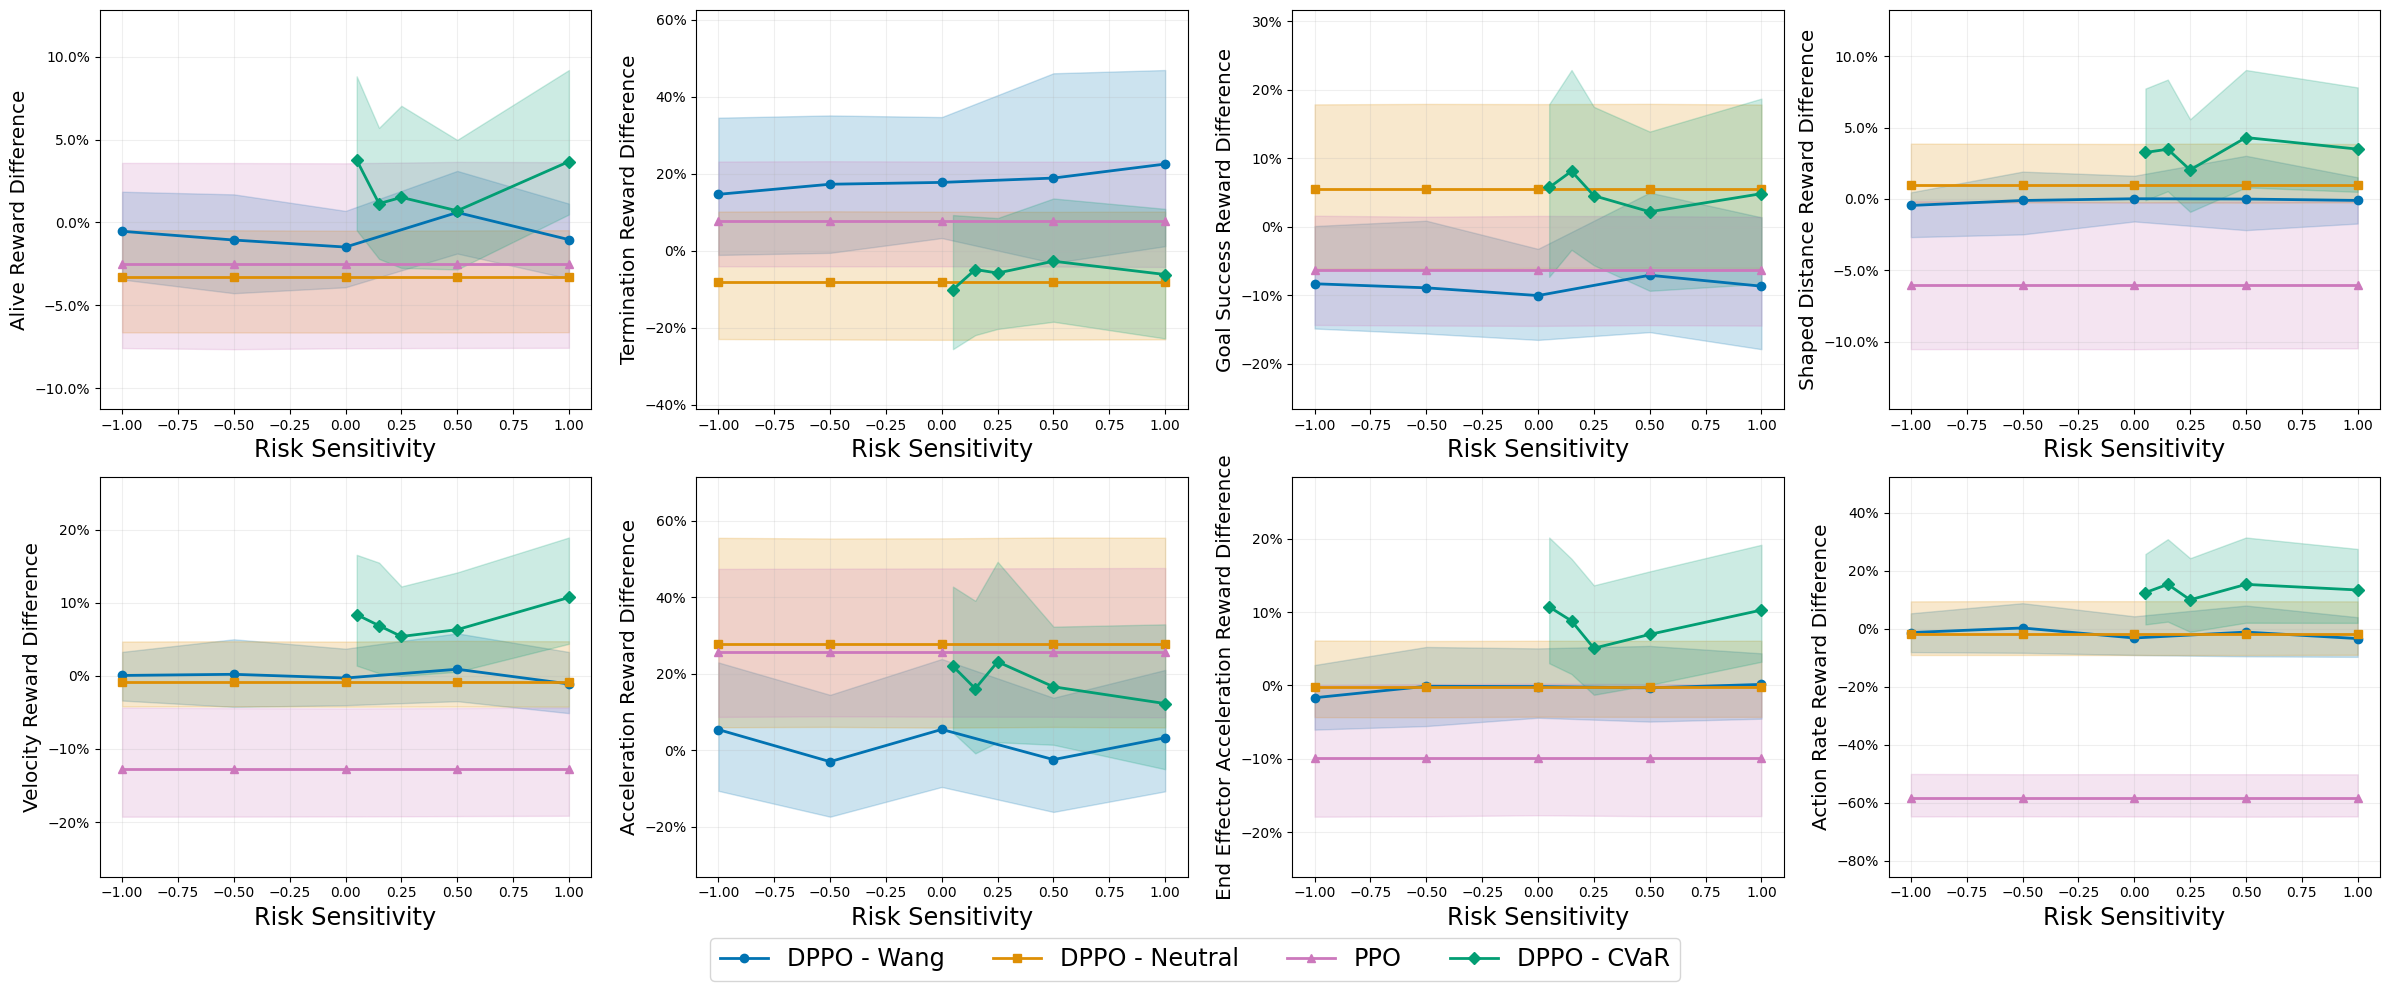

In [157]:
fig, axs = plot_all_nav_task_reward_difference("smaller_range")

In [158]:
# save figure
fig.savefig("nav_task_reward_difference_AAMAS.pdf", dpi=300, bbox_inches='tight')

In [ ]:
plot_all_nav_task_reward("default")

In [ ]:
plot_all_nav_task_reward("no_shaped")

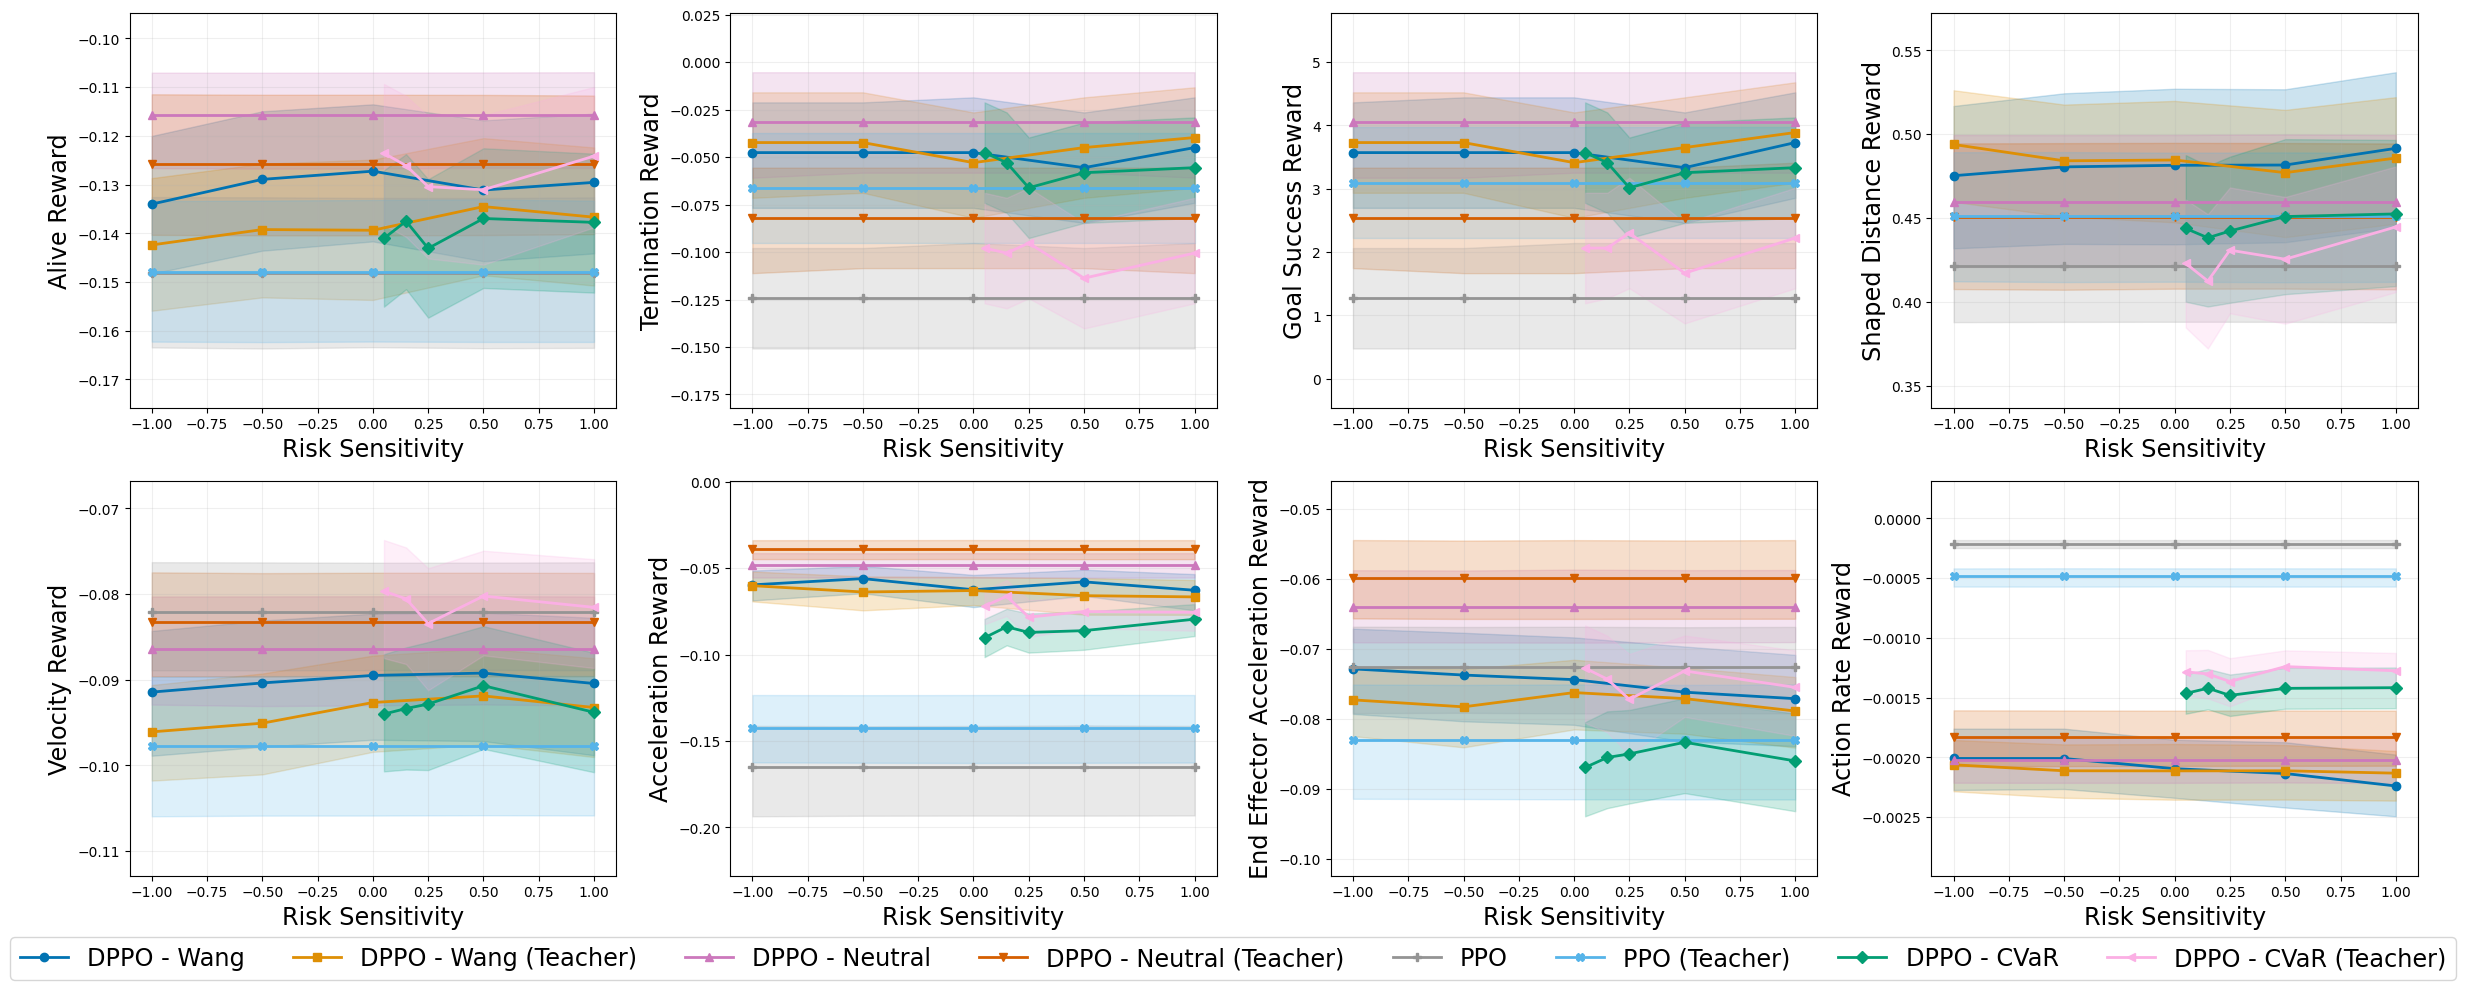

In [150]:
fig, axes = plot_all_nav_task_reward("smaller_range")

In [151]:
fig.savefig("nav_task_rewards_AAMAS.pdf", format="pdf", dpi=500, bbox_inches='tight')

In [87]:
smaller_range_env_contacts_cvar_rliable_data.keys()

dict_keys(['DPPO - CVaR', 'DPPO - CVaR (Teacher)'])

In [37]:
import matplotlib as mpl

In [89]:
smaller_range_success_cvar_rliable_data.keys()

dict_keys(['DPPO - CVaR', 'DPPO - CVaR (Teacher)'])

In [38]:
def plot_nav_task_rates(run_name: str):
    
    # mpl.rcParams.update({
    # "font.size":       9,   # base font size
    # "axes.titlesize":  9,   # subplot titles
    # "axes.labelsize":  9,   # x/y labels
    # "xtick.labelsize": 8,   # tick labels
    # "ytick.labelsize": 8,
    # "legend.fontsize": 8,   # legend entries
    # "legend.title_fontsize": 9,
    # })
    fig, axs = plt.subplots(1, 3, figsize=(22.0, 6.0))


    if run_name == "default":
        plotted_success_wang_rliable_data = success_wang_rliable_data
        plotted_success_cvar_rliable_data = success_cvar_rliable_data
        plotted_time_wang_rliable_data = time_wang_rliable_data
        plotted_time_cvar_rliable_data = time_cvar_rliable_data
        plotted_env_cylinder_contacts_wang_rliable_data = env_cylinder_contacts_rliable_data
        plotted_env_cylinder_contacts_cvar_rliable_data = env_cylinder_contacts_cvar_rliable_data
        plotted_cumulative_rewards_wang_rliable_data = cumulative_rewards_wang_rliable_data
        plotted_cumulative_rewards_cvar_rliable_data = cumulative_rewards_cvar_rliable_data
    elif run_name == "no_shaped":
        plotted_success_wang_rliable_data = no_shaped_success_rliable_data
        plotted_time_wang_rliable_data = no_shaped_time_out_rliable_data
        plotted_env_cylinder_contacts_wang_rliable_data = no_shaped_env_cylinder_contacts_wang_rliable_data
        plotted_cumulative_rewards_wang_rliable_data = no_shaped_cumulative_rewards_wang_rliable_data
        plotted_success_cvar_rliable_data, plotted_env_cylinder_contacts_cvar_rliable_data, plotted_time_cvar_rliable_data, plotted_cumulative_rewards_cvar_rliable_data = None, None, None, None
        cvar_risk_sensitivities = None
    elif run_name == "smaller_range":
        plotted_success_wang_rliable_data = smaller_range_success_rliable_data
        plotted_success_cvar_rliable_data = smaller_range_success_cvar_rliable_data
        plotted_cylinder_contacts_wang_rliable_data = smaller_range_cylinder_contacts_wang_rliable_data
        plotted_cylinder_contacts_cvar_rliable_data = smaller_range_cylinder_contacts_cvar_rliable_data
        plotted_env_contacts_wang_rliable_data = smaller_range_env_contacts_wang_rliable_data
        plotted_env_contacts_cvar_rliable_data = smaller_range_env_contacts_cvar_rliable_data
        plotted_time_wang_rliable_data = smaller_range_time_out_rliable_data
        plotted_time_cvar_rliable_data = smaller_range_time_cvar_rliable_data
        plotted_env_cylinder_contacts_wang_rliable_data = smaller_range_env_cylinder_contacts_wang_rliable_data
        plotted_env_cylinder_contacts_cvar_rliable_data = smaller_range_env_cylinder_contacts_cvar_rliable_data
        plotted_cumulative_rewards_wang_rliable_data = smaller_range_cumulative_rewards_wang_rliable_data
        plotted_cumulative_rewards_cvar_rliable_data = smaller_range_cumulative_rewards_cvar_rliable_data


    ax0 = plot_sample_efficiency_style_curve(plotted_success_wang_rliable_data, 
                                            wang_risk_sensitivities, 
                                            plotted_success_cvar_rliable_data, 
                                            [0.05000000074505806, 0.15000000596046448, 0.25, 0.5, 1.0], 
                                            "success_rate", 
                                            ax=axs[0],
                                            set_major_formatter=True)

    ax1 = plot_sample_efficiency_style_curve(plotted_env_cylinder_contacts_wang_rliable_data, 
                                            wang_risk_sensitivities,
                                            plotted_env_cylinder_contacts_cvar_rliable_data,
                                            [0.05000000074505806, 0.15000000596046448, 0.25, 0.5, 1.0],
                                            "env_cylinder_contacts", 
                                            ax=axs[1],
                                            set_major_formatter=True)
    
    # ax1 = plot_sample_efficiency_style_curve(plotted_cylinder_contacts_wang_rliable_data, 
    #                                         wang_risk_sensitivities,
    #                                         plotted_cylinder_contacts_cvar_rliable_data,
    #                                         [0.05000000074505806, 0.15000000596046448, 0.25, 0.5, 1.0],
    #                                         "cylinder_contact_rate", 
    #                                         ax=axs[0,2],
    #                                         set_major_formatter=True)
    
    # ax1 = plot_sample_efficiency_style_curve(plotted_env_contacts_wang_rliable_data, 
    #                                         wang_risk_sensitivities,
    #                                         plotted_env_contacts_cvar_rliable_data,
    #                                         [0.05000000074505806, 0.15000000596046448, 0.25, 0.5, 1.0],
    #                                         "env_contact_list_per_env", 
    #                                         ax=axs[1, 0],
    #                                         set_major_formatter=True)

    # ax2 = plot_sample_efficiency_style_curve(plotted_time_wang_rliable_data,
    #                                         wang_risk_sensitivities,
    #                                         plotted_time_cvar_rliable_data,
    #                                         [0.05000000074505806, 0.15000000596046448, 0.25, 0.5, 1.0],
    #                                         "time_out_list_per_env", 
    #                                         ax=axs[1,1],
    #                                         set_major_formatter=True)

    ax3 = plot_sample_efficiency_style_curve(plotted_cumulative_rewards_wang_rliable_data,
                                            wang_risk_sensitivities,
                                            plotted_cumulative_rewards_cvar_rliable_data,
                                            [0.05000000074505806, 0.15000000596046448, 0.25, 0.5, 1.0],
                                            "cumulative_rewards", 
                                            ax=axs[2],
                                            set_major_formatter=False)

    # Optionally, retrieve legend handles and labels from one of the subplots.
    handles, labels = axs[0].get_legend_handles_labels()
    
    for ax in axs.flatten():
         # pad each y-axis by 15%
        y0, y1 = ax.get_ylim()
        dy = (y1 - y0) * 0.15
        ax.set_ylim(y0 - dy, y1 + dy)

    # Rearange the labels
    # if len(labels) == 8:
    #     labels = [labels[0], labels[4], labels[6], labels[7], labels[2], labels[5], labels[1], labels[3]]

    # Create a single legend for the entire figure, positioned along the bottom.
    fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='xx-large')

    # Adjust layout to ensure there's room for the global legend.
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()
    
    return fig, axs

In [ ]:
plot_nav_task_rates("default")

In [ ]:
plot_nav_task_rates("no_shaped")

In [67]:
cvar_risk_sensitivities = [0.05000000074505806, 0.15000000596046448, 0.25, 0.5, 1.0]

In [85]:
smaller_range_env_contacts_wang_rliable_data['DPPO - Wang']
# smaller_range_success_rliable_data['DPPO - Wang'].shape


array([[0.44, 0.48, 0.48, 0.44, 0.48],
       [0.44, 0.52, 0.44, 0.44, 0.52],
       [0.64, 0.6 , 0.6 , 0.6 , 0.64],
       [0.28, 0.28, 0.32, 0.32, 0.36],
       [0.4 , 0.36, 0.4 , 0.36, 0.36],
       [0.24, 0.24, 0.28, 0.28, 0.2 ],
       [0.44, 0.48, 0.48, 0.48, 0.56],
       [0.08, 0.08, 0.08, 0.12, 0.08],
       [0.4 , 0.44, 0.48, 0.4 , 0.44],
       [0.16, 0.12, 0.16, 0.16, 0.16],
       [0.56, 0.6 , 0.6 , 0.64, 0.6 ],
       [0.24, 0.28, 0.36, 0.28, 0.32],
       [0.36, 0.4 , 0.28, 0.48, 0.44],
       [0.24, 0.24, 0.28, 0.24, 0.24],
       [0.32, 0.44, 0.36, 0.36, 0.36],
       [0.52, 0.44, 0.56, 0.6 , 0.64],
       [0.28, 0.24, 0.24, 0.24, 0.24],
       [0.28, 0.24, 0.24, 0.28, 0.28],
       [0.44, 0.4 , 0.32, 0.32, 0.44],
       [0.52, 0.56, 0.56, 0.56, 0.52],
       [0.28, 0.28, 0.28, 0.28, 0.28],
       [0.56, 0.6 , 0.64, 0.6 , 0.68],
       [0.28, 0.28, 0.32, 0.36, 0.36],
       [0.4 , 0.32, 0.44, 0.44, 0.48],
       [0.36, 0.32, 0.32, 0.32, 0.32],
       [0.64, 0.64, 0.56,

In [ ]:
fig, axs = plot_nav_task_rates("smaller_range")

In [41]:
fig.savefig("smaller_range_nav_task_rates_AAMAS.pdf", format="pdf", dpi=500, bbox_inches='tight')

In [144]:
def plot_nav_task_rates_difference(run_name: str):

    # mpl.rcParams.update({
    # "font.size":       9,   # base font size
    # "axes.titlesize":  9,   # subplot titles
    # "axes.labelsize":  9,   # x/y labels
    # "xtick.labelsize": 8,   # tick labels
    # "ytick.labelsize": 8,
    # "legend.fontsize": 8,   # legend entries
    # "legend.title_fontsize": 9,
    # })
    fig, axs = plt.subplots(1, 3, figsize=(22.0, 6.0))


    if run_name == "default":
        plotted_success_wang_rliable_data = success_wang_rliable_data
        plotted_success_cvar_rliable_data = success_cvar_rliable_data
        plotted_time_wang_rliable_data = time_wang_rliable_data
        plotted_time_cvar_rliable_data = time_cvar_rliable_data
        plotted_env_cylinder_contacts_wang_rliable_data = env_cylinder_contacts_rliable_data
        plotted_env_cylinder_contacts_cvar_rliable_data = env_cylinder_contacts_cvar_rliable_data
        plotted_cumulative_rewards_wang_rliable_data = cumulative_rewards_wang_rliable_data
        plotted_cumulative_rewards_cvar_rliable_data = cumulative_rewards_cvar_rliable_data
    elif run_name == "no_shaped":
        plotted_success_wang_rliable_data = no_shaped_success_rliable_data
        plotted_time_wang_rliable_data = no_shaped_time_out_rliable_data
        plotted_env_cylinder_contacts_wang_rliable_data = no_shaped_env_cylinder_contacts_wang_rliable_data
        plotted_cumulative_rewards_wang_rliable_data = no_shaped_cumulative_rewards_wang_rliable_data
        plotted_success_cvar_rliable_data, plotted_env_cylinder_contacts_cvar_rliable_data, plotted_time_cvar_rliable_data, plotted_cumulative_rewards_cvar_rliable_data = None, None, None, None
        cvar_risk_sensitivities = None
    elif run_name == "smaller_range":
        plotted_success_wang_rliable_data = smaller_range_success_rliable_data
        plotted_success_cvar_rliable_data = smaller_range_success_cvar_rliable_data
        plotted_cylinder_contacts_wang_rliable_data = smaller_range_cylinder_contacts_wang_rliable_data
        plotted_cylinder_contacts_cvar_rliable_data = smaller_range_cylinder_contacts_cvar_rliable_data
        plotted_env_contacts_wang_rliable_data = smaller_range_env_contacts_wang_rliable_data
        plotted_env_contacts_cvar_rliable_data = smaller_range_env_contacts_cvar_rliable_data
        plotted_time_wang_rliable_data = smaller_range_time_out_rliable_data
        plotted_time_cvar_rliable_data = smaller_range_time_cvar_rliable_data
        plotted_env_cylinder_contacts_wang_rliable_data = smaller_range_env_cylinder_contacts_wang_rliable_data
        plotted_env_cylinder_contacts_cvar_rliable_data = smaller_range_env_cylinder_contacts_cvar_rliable_data
        plotted_cumulative_rewards_wang_rliable_data = smaller_range_cumulative_rewards_wang_rliable_data
        plotted_cumulative_rewards_cvar_rliable_data = smaller_range_cumulative_rewards_cvar_rliable_data


    new_wang_keys = ['DPPO - Wang', 'DPPO - Neutral', 'PPO']
    new_cvar_keys = ['DPPO - CVaR']
    diff_plotted_success_wang_rliable_data = {}
    diff_plotted_env_cylinder_contacts_wang_rliable_data = {}
    diff_plotted_cumulative_rewards_wang_rliable_data = {}
    diff_plotted_success_cvar_rliable_data = {}
    diff_plotted_env_cylinder_contacts_cvar_rliable_data = {}
    diff_plotted_cumulative_rewards_cvar_rliable_data = {}
    for key in new_wang_keys:
        teacher_key = key + " (Teacher)"
        diff_plotted_success_wang_rliable_data.update({key: (plotted_success_wang_rliable_data[key] - plotted_success_wang_rliable_data[teacher_key])/plotted_success_wang_rliable_data[teacher_key]})
        diff_plotted_env_cylinder_contacts_wang_rliable_data.update({key: (plotted_env_cylinder_contacts_wang_rliable_data[key] - plotted_env_cylinder_contacts_wang_rliable_data[teacher_key])/plotted_env_cylinder_contacts_wang_rliable_data[teacher_key]})
        diff_plotted_cumulative_rewards_wang_rliable_data.update({key: (plotted_cumulative_rewards_wang_rliable_data[key] - plotted_cumulative_rewards_wang_rliable_data[teacher_key])})
        
    for key in new_cvar_keys:
        teacher_key = key + " (Teacher)"
        diff_plotted_success_cvar_rliable_data.update({key: (plotted_success_cvar_rliable_data[key] - plotted_success_cvar_rliable_data[teacher_key])/plotted_success_cvar_rliable_data[teacher_key]})
        diff_plotted_env_cylinder_contacts_cvar_rliable_data.update({key: (plotted_env_cylinder_contacts_cvar_rliable_data[key] - plotted_env_cylinder_contacts_cvar_rliable_data[teacher_key])/plotted_env_cylinder_contacts_cvar_rliable_data[teacher_key]})
        diff_plotted_cumulative_rewards_cvar_rliable_data.update({key: (plotted_cumulative_rewards_cvar_rliable_data[key] - plotted_cumulative_rewards_cvar_rliable_data[teacher_key])})


    ax0 = plot_sample_efficiency_style_curve(diff_plotted_success_wang_rliable_data, 
                                            wang_risk_sensitivities, 
                                            diff_plotted_success_cvar_rliable_data, 
                                            [0.05000000074505806, 0.15000000596046448, 0.25, 0.5, 1.0], 
                                            "success_rate_difference", 
                                            ax=axs[0],
                                            set_major_formatter=True)

    ax1 = plot_sample_efficiency_style_curve(diff_plotted_env_cylinder_contacts_wang_rliable_data, 
                                            wang_risk_sensitivities,
                                            diff_plotted_env_cylinder_contacts_cvar_rliable_data,
                                            [0.05000000074505806, 0.15000000596046448, 0.25, 0.5, 1.0],
                                            "env_cylinder_contacts_difference", 
                                            ax=axs[1],
                                            set_major_formatter=True)
    
    # ax1 = plot_sample_efficiency_style_curve(plotted_cylinder_contacts_wang_rliable_data, 
    #                                         wang_risk_sensitivities,
    #                                         plotted_cylinder_contacts_cvar_rliable_data,
    #                                         [0.05000000074505806, 0.15000000596046448, 0.25, 0.5, 1.0],
    #                                         "cylinder_contact_rate", 
    #                                         ax=axs[0,2],
    #                                         set_major_formatter=True)
    
    # ax1 = plot_sample_efficiency_style_curve(plotted_env_contacts_wang_rliable_data, 
    #                                         wang_risk_sensitivities,
    #                                         plotted_env_contacts_cvar_rliable_data,
    #                                         [0.05000000074505806, 0.15000000596046448, 0.25, 0.5, 1.0],
    #                                         "env_contact_list_per_env", 
    #                                         ax=axs[1, 0],
    #                                         set_major_formatter=True)

    # ax2 = plot_sample_efficiency_style_curve(plotted_time_wang_rliable_data,
    #                                         wang_risk_sensitivities,
    #                                         plotted_time_cvar_rliable_data,
    #                                         [0.05000000074505806, 0.15000000596046448, 0.25, 0.5, 1.0],
    #                                         "time_out_list_per_env", 
    #                                         ax=axs[1,1],
    #                                         set_major_formatter=True)

    ax3 = plot_sample_efficiency_style_curve(diff_plotted_cumulative_rewards_wang_rliable_data,
                                            wang_risk_sensitivities,
                                            diff_plotted_cumulative_rewards_cvar_rliable_data,
                                            [0.05000000074505806, 0.15000000596046448, 0.25, 0.5, 1.0],
                                            "cumulative_rewards_difference", 
                                            ax=axs[2],
                                            set_major_formatter=False)

    # Optionally, retrieve legend handles and labels from one of the subplots.
    handles, labels = axs[0].get_legend_handles_labels()
    
    for ax in axs.flatten():
         # pad each y-axis by 15%
        y0, y1 = ax.get_ylim()
        dy = (y1 - y0) * 0.15
        ax.set_ylim(y0 - dy, y1 + dy)

    # Rearange the labels
    # if len(labels) == 8:
    #     labels = [labels[0], labels[4], labels[6], labels[7], labels[2], labels[5], labels[1], labels[3]]

    # Create a single legend for the entire figure, positioned along the bottom.
    fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='xx-large')

    # Adjust layout to ensure there's room for the global legend.
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()
    
    return fig, axs

KeyError: 'DPPO - Wang (Teacher)'

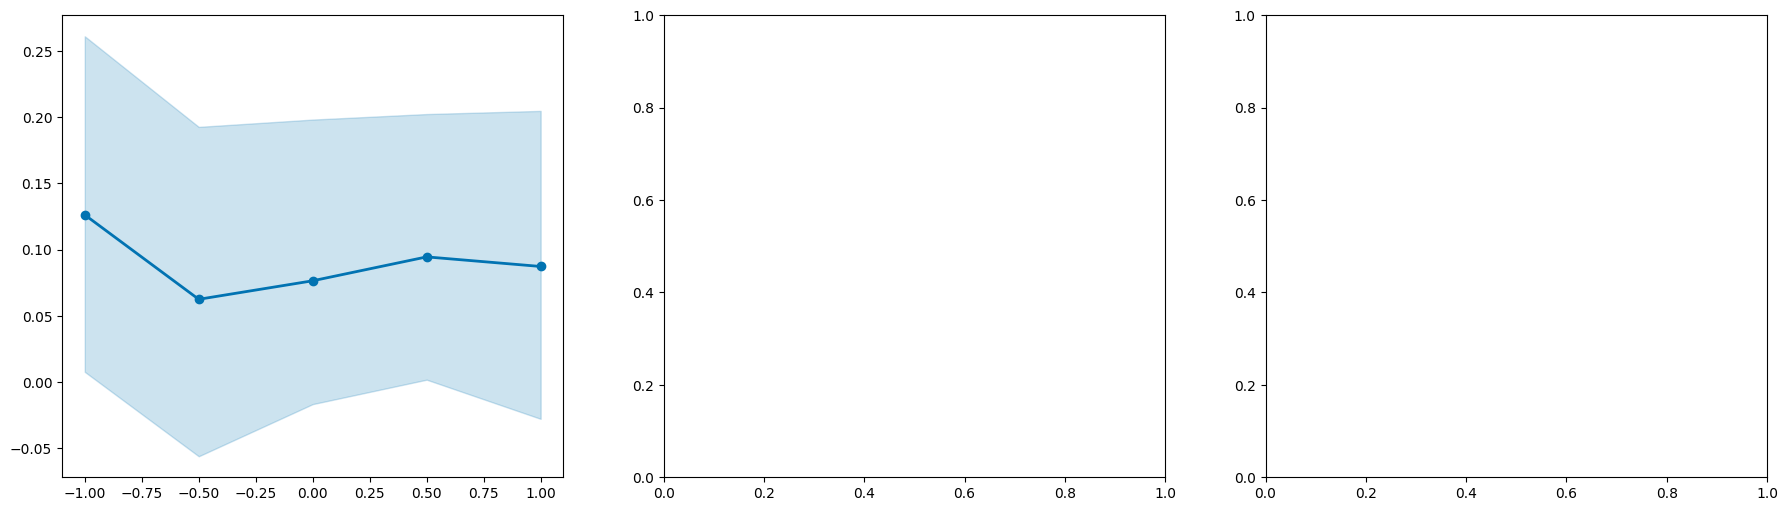

In [145]:
fig, axs = plot_nav_task_rates_difference("smaller_range")

In [54]:
# save the figure
fig.savefig("nav_task_rates_difference_AAMAS.pdf", format="pdf", dpi=500, bbox_inches='tight')

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(32, 6))

ax0 = plot_sample_efficiency_style_curve(no_shaped_success_rliable_data, 
                                         wang_risk_sensitivities, 
                                         None, 
                                         None, 
                                         "success_rate", 
                                         ax=axs[0],
                                         set_major_formatter=True)

ax1 = plot_sample_efficiency_style_curve(no_shaped_env_cylinder_contacts_rliable_data, 
                                         wang_risk_sensitivities,
                                         None,
                                         None,
                                         "env_cylinder_contacts", 
                                         ax=axs[1],
                                         set_major_formatter=True)

# ax1 = plot_sample_efficiency_style_curve(no_shaped_cylinder_rliable_data, 
#                                          wang_risk_sensitivities,
#                                          None,
#                                          None,
#                                          "cylinder_contact_rate", 
#                                          ax=axs[1],
#                                          set_major_formatter=True)

# ax2 = plot_sample_efficiency_style_curve(no_shaped_env_contact_rliable_data,
#                                          wang_risk_sensitivities,
#                                          None,
#                                          None,
#                                          "env_contact_list_per_env", 
#                                          ax=axs[2],
#                                          set_major_formatter=True)

ax3 = plot_sample_efficiency_style_curve(no_shaped_cumulative_rewards_rliable_data,
                                         wang_risk_sensitivities,
                                         None,
                                         None,
                                         "cumulative_rewards", 
                                         ax=axs[2],
                                         set_major_formatter=False)

# Optionally, retrieve legend handles and labels from one of the subplots.
handles, labels = axs[0].get_legend_handles_labels()

# Get the current y-axis limits and increase them by 20%
for ax in axs.flatten():
    y_min, y_max = ax.get_ylim()
    dy = (y_max - y_min) * 0.1
    
    # Adjust the y-limits symmetrically
    ax.set_ylim(y_min - dy, y_max + dy)

# Create a single legend for the entire figure, positioned along the bottom.
fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='xx-large')

# Adjust layout to ensure there's room for the global legend.
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [55]:
statistic_data = {"success_rate": None,
                  "cylinder_contact_rate": None,
                  "time_out_list_per_env": None,
                  "env_contact_list_per_env": None,
                  "give_up_rate": None,
                  "cumulative_rewards": None,
                  "env_cylinder_contacts": None,
                  "alive_per_env": None,
                  "termination_penalty_per_env": None,
                  "end_effector_position_tracking_goal_per_env": None,
                  "end_effector_position_tracking_shaped_per_env": None,
                  "action_rate_per_env": None,
                  "arm_joint_vel_per_env": None,
                  "arm_joint_acc_per_env": None,
                  "base_vel_per_env": None,
                  "base_acc_per_env": None,
                  "ee_acc_per_env": None,
                  "padded_alive_per_env": None,
                  "give_up_reward_term_per_env": None,}

In [ ]:
all_wang_rliable_data.keys()

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(24, 12))

ax0 = plot_sample_efficiency_style_curve(success_wang_rliable_data, 
                                         wang_risk_sensitivities, 
                                         success_cvar_rliable_data, 
                                         cvar_risk_sensitivities, 
                                         "success_rate", 
                                         ax=axs[0, 0])

ax1 = plot_sample_efficiency_style_curve(cylinder_wang_rliable_data,
                                         wang_risk_sensitivities,
                                         cylinder_cvar_rliable_data,
                                         cvar_risk_sensitivities, 
                                         "cylinder_contact_rate", 
                                         ax=axs[0,1])

ax3 = plot_sample_efficiency_style_curve(time_wang_rliable_data, 
                                         wang_risk_sensitivities, 
                                         time_cvar_rliable_data,
                                         cvar_risk_sensitivities, 
                                         "time_out_list_per_env", 
                                         ax=axs[1,0])

ax2 = plot_sample_efficiency_style_curve(env_contact_wang_rliable_data,
                                         wang_risk_sensitivities, 
                                         env_contact_cvar_rliable_data,
                                         cvar_risk_sensitivities, 
                                         "env_contact_list_per_env", 
                                         ax=axs[1,1])

# Optionally, retrieve legend handles and labels from one of the subplots.
handles, labels = axs[0, 0].get_legend_handles_labels()

# Create a single legend for the entire figure, positioned along the bottom.
fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='xx-large')

# Adjust layout to ensure there's room for the global legend.
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()


In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(8, 6))

ax1 = plot_sample_efficiency_style_curve(cumulative_rewards_wang_rliable_data, 
                                         wang_risk_sensitivities, 
                                         cumulative_rewards_cvar_rliable_data, 
                                         cvar_risk_sensitivities, 
                                         "cumulative_rewards", 
                                         ax=axs, 
                                         set_major_formatter=False)

# Optionally, retrieve legend handles and labels from one of the subplots.
handles, labels = axs.get_legend_handles_labels()

# Create a single legend for the entire figure, positioned along the bottom.
fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='xx-large')

# Adjust layout to ensure there's room for the global legend.
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [ ]:
statistic = "cumulative_rewards"

just_cumulative_rewards_wang_rliable_data = None

for key in DPPO_Wang_filenames_dict.keys():
    just_cumulative_rewards_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(DPPO_Wang_filenames_dict[key], key, statistic, just_cumulative_rewards_wang_rliable_data)



In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(8, 6))

ax1 = plot_sample_efficiency_style_curve_just_wang(just_cumulative_rewards_wang_rliable_data, 
                                         wang_risk_sensitivities, 
                                         None, None, "cumulative_rewards", ax=axs, set_major_formatter=False)

# Optionally, retrieve legend handles and labels from one of the subplots.
handles, labels = axs.get_legend_handles_labels()

# Create a single legend for the entire figure, positioned along the bottom.
fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='xx-large')

# Adjust layout to ensure there's room for the global legend.
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()


Cumulative Return Histogram Plotting

In [ ]:
def plot_cumaltive_reward_histogram(data, algorithm, ax):
    """Plot the histogram of cumulative rewards for a given algorithm."""
    # Flatten the data to create a 1D array of cumulative rewards
    # print(f"data keys: {data.keys()}")
    # flattened_data = np.array(data["cumulative_rewards"][algorithm]).flatten()
    # print(f"flattened_data: {flattened_data}")
    # print(f"flattened_data shape: {flattened_data.shape}")
    # print(f"algorithm: {algorithm}")
    
    for i in range(np.array(data["cumulative_rewards"][algorithm]).shape[2]):
        flattened_data = np.array(data["cumulative_rewards"][algorithm][:, :, i]).flatten()
        # Plot the histogram
        ax[i].hist(flattened_data, bins=50, density=True, alpha=0.6, color='g', label=algorithm)
        
        # Set labels and title
        ax[i].set_xlabel('Cumulative Reward')
        ax[i].set_ylabel('Density')
        ax[i].set_title(f'Histogram of Cumulative Rewards for {algorithm} ({wang_risk_sensitivities[i]})')
    
    # Add a legend
    # ax[0].legend()

In [ ]:
# Create a figure and axis for the histogram
# create number of subplots based on the number of algorithms
num_algorithms = len(DPPO_Wang_filenames_dict["DPPO - Wang"])
print(f"DPPO_wang keys: {DPPO_Wang_filenames_dict.keys()}")
print(f"num_algorithms: {num_algorithms}")
fig, axs = plt.subplots(1, num_algorithms, figsize=(24, 6))
# fig, ax = plt.subplots(figsize=(8, 6))
# Plot histogram for each algorithm
# for idx, algorithm in enumerate(DPPO_Wang_filenames_dict.keys()):
    
plot_cumaltive_reward_histogram(all_wang_rliable_data, algorithm, axs)
# Optionally, retrieve legend handles and labels from one of the subplots.
handles, labels = axs[0].get_legend_handles_labels()

# Create a single legend for the entire figure, positioned along the bottom.
fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='xx-large')

# Adjust layout to ensure there's room for the global legend.
# plt.tight_layout(rect=[0, 0.1, 1, 1])
# Show the plot
plt.tight_layout()
plt.show()

Lets plot histogram data without sampling

In [ ]:
cumulative_rewards_dict = {}

# print(f"Loading DPPO Wang cumulative rewards data")
for key in smaller_range_DPPO_Wang_filenames_dict.keys():
    for filename in smaller_range_DPPO_Wang_filenames_dict[key]:
        # Load the YAML file
        print(f"Loading file: {filename}")
        cumulative_rewards_list = []
        data = load_yaml(filename)
        risk_sensitivity = data[0]["risk_sensitivity"]
        for rollout in data:
            cumulative_rewards_list.append(data[rollout]["cumulative_rewards"])
        cumulative_rewards_list = np.array(cumulative_rewards_list)
        cumulative_rewards_dict.update({risk_sensitivity: cumulative_rewards_list})
        
        
# print(f"Loading DPPO Wang teacher cumulative rewards data")
teacher_cumulative_rewards_dict = {}

for key in teacher_smaller_range_DPPO_Wang_filenames_dict.keys():
    for filename in teacher_smaller_range_DPPO_Wang_filenames_dict[key]:
        # Load the YAML file
        print(f"Loading file: {filename}")
        cumulative_rewards_list = []
        data = load_yaml(filename)
        risk_sensitivity = data[0]["risk_sensitivity"]
        for rollout in data:
            cumulative_rewards_list.append(data[rollout]["cumulative_rewards"])
        cumulative_rewards_list = np.array(cumulative_rewards_list)
        teacher_cumulative_rewards_dict.update({risk_sensitivity: cumulative_rewards_list})
        
# print(f"Loading DPPO Wang no shaped cumulative rewards data")
# for key in no_shaped_DPPO_Wang_filenames_dict.keys():
#     for filename in no_shaped_DPPO_Wang_filenames_dict[key]:
#         # Load the YAML file
#         print(f"Loading file: {filename}")
#         cumulative_rewards_list = []
#         data = load_yaml(filename)
#         risk_sensitivity = data[0]["risk_sensitivity"]
#         for rollout in data:
#             cumulative_rewards_list.append(data[rollout]["cumulative_rewards"])
#         cumulative_rewards_list = np.array(cumulative_rewards_list)
#         cumulative_rewards_dict.update({risk_sensitivity: cumulative_rewards_list})
        
# teacher_no_shaped_DPPO_Wang_filenames_dict
# print(f"Loading DPPO Wang no shaped teacher cumulative rewards data")
# for key in teacher_no_shaped_DPPO_Wang_filenames_dict.keys():
#     for filename in teacher_no_shaped_DPPO_Wang_filenames_dict[key]:
#         # Load the YAML file
#         print(f"Loading file: {filename}")
#         cumulative_rewards_list = []
#         data = load_yaml(filename)
#         risk_sensitivity = data[0]["risk_sensitivity"]
#         for rollout in data:
#             cumulative_rewards_list.append(data[rollout]["cumulative_rewards"])
#         cumulative_rewards_list = np.array(cumulative_rewards_list)
#         teacher_cumulative_rewards_dict.update({risk_sensitivity: cumulative_rewards_list})


In [ ]:
from scipy.stats import norm, gaussian_kde

# Create a figure and axis for the histogram
# create number of subplots based on the number of keys in cumulative_rewards_dict
num_algorithms = len(cumulative_rewards_dict.keys())

fig, axs = plt.subplots(1, num_algorithms, figsize=(24, 6))
# Plot histogram for each algorithm
for idx, key in enumerate(cumulative_rewards_dict.keys()):
    flattened_data = np.array(cumulative_rewards_dict[key]).flatten()
    # Plot the histogram
    axs[idx].hist(flattened_data, bins=50, density=True, alpha=0.6, color='g', label=key)
    
    # Set labels and title
    axs[idx].set_xlabel('Cumulative Reward')
    axs[idx].set_ylabel('Density')
    axs[idx].set_title(f'Histogram of Cumulative Rewards for {key}')
    
    # if key == 0.0:
    #     # Plot a kernel density estimate
    # sns.kdeplot(flattened_data, ax=axs[idx], color='blue', label='KDE')
    x_vals = np.linspace(flattened_data.min(), flattened_data.max(), 1000)
    kde = gaussian_kde(flattened_data)
    original_pdf = kde.evaluate(x_vals)

    
    if key == 0.0:
        # Plot the KDE
        # Approximate the cumulative distribution function (CDF)
        # We compute a cumulative sum over the density estimate and normalize.
        cdf_vals = np.cumsum(original_pdf)
        cdf_vals /= cdf_vals[-1]  # normalization so that the CDF goes to 1
    
    # clip x-axis between -4 and 6
    axs[idx].set_xlim(-3, 6)
    axs[idx].set_ylim(0, 0.4)
    # Add grid lines
    axs[idx].grid(True)


gammas = [-1.0, -0.5, 0.0, 0.5, 1.0]    
for idx, key in enumerate(cumulative_rewards_dict.keys()):
    # plot wang metric adjusted KDEs on the plots
    
    transformed_cdf = norm.cdf(norm.ppf(cdf_vals) + gammas[idx])
    wang_adjusted_pdf = np.gradient(transformed_cdf, x_vals)
    
    # if key != 0.0:
    #     # plot the adjusted PDF
    axs[idx].plot(x_vals, wang_adjusted_pdf, color='red', label='Wang Adjusted PDF')
    
    axs[idx].plot(x_vals, original_pdf, color='blue', label='Risk Neutral PDF')
    
handles, labels = axs[0].get_legend_handles_labels()

# Create a single legend for the entire figure, positioned along the bottom.
fig.legend(handles, ['DPPO - Wang', 'Wang Adjusted PDF', 'Data PDF'], loc='lower center', ncol=len(handles), fontsize='xx-large', bbox_to_anchor=(0.5, -0.1))

# Adjust layout to ensure there's room for the global legend.
plt.tight_layout(rect=[0, 0.1, 1, 1])
# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import norm, gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

# Assuming cumulative_rewards_dict is defined and populated with keys corresponding to risk parameters
# and that the key 0.0 corresponds to the risk-neutral case.

num_algorithms = len(cumulative_rewards_dict.keys())
fig, axs = plt.subplots(1, num_algorithms, figsize=(24, 6))

# First, compute the risk-neutral PDF and CDF (i.e. key == 0.0)
risk_neutral_key = 0.0
for key in cumulative_rewards_dict.keys():
    if key == risk_neutral_key:
        flattened_data = np.array(cumulative_rewards_dict[key]).flatten()
        x_vals = np.linspace(flattened_data.min(), flattened_data.max(), 100000)
        kde = gaussian_kde(flattened_data)
        original_pdf = kde.evaluate(x_vals)
        
        # Normalize the original PDF to ensure it integrates to 1
        area = np.trapz(original_pdf, x_vals)
        original_pdf /= area
        
        dx = x_vals[1] - x_vals[0]  # grid spacing
        
        # Compute the risk-neutral CDF using the correct numerical integration (with dx)
        cdf_vals = np.cumsum(original_pdf * dx)
        cdf_vals /= cdf_vals[-1]  # normalize so that the CDF ends at 1
        
        break  # Assuming there's only one risk-neutral key, exit the loop

bin_width = 0.1  # Define the bin width for the histogram

# Plot histogram and KDE for each risk parameter in cumulative_rewards_dict
for idx, key in enumerate(cumulative_rewards_dict.keys()):
    flattened_data = np.array(cumulative_rewards_dict[key]).flatten()
    # Create bin edges with a fixed interval width.
    bin_edges = np.arange(flattened_data.min(), flattened_data.max() + bin_width, bin_width)
    
    axs[idx].hist(flattened_data, bins=bin_edges, density=True, alpha=0.6, color='g', label=f"Data {key}")
    
    axs[idx].set_xlabel('Cumulative Reward')
    axs[idx].set_ylabel('Density')
    axs[idx].set_title(f'Histogram of Cumulative Rewards for {key}')
    axs[idx].grid(True)

# Define a list of gamma values corresponding to each risk-sensitivity key.
# Ensure that the ordering of gammas aligns with the keys.
gammas = [-1.0, -0.5, 0.0, 0.5, 1.0]    

# Now, add the Wang adjusted KDEs to each subplot using the same risk-neutral CDF and x_vals.
for idx, key in enumerate(cumulative_rewards_dict.keys()):
    # Apply the Wang transform to the risk-neutral CDF using the corresponding gamma.
    transformed_cdf = norm.cdf(norm.ppf(cdf_vals) + gammas[idx])
    # Differentiate the transformed CDF using np.gradient with dx as spacing.
    wang_adjusted_pdf = np.gradient(transformed_cdf, dx)
    
    axs[idx].plot(x_vals, wang_adjusted_pdf, color='red', label='Wang Adjusted PDF')
    axs[idx].plot(x_vals, original_pdf, color='blue', label='Risk Neutral PDF')
    # clip x-axis between -4 and 6
    axs[idx].set_xlim(-3, 6)
    axs[idx].set_ylim(0, 0.4)

# Create a single legend for the entire figure, positioned along the bottom.
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, ['DPPO - Wang', 'Wang Adjusted PDF', 'Data PDF'], loc='lower center', ncol=len(handles), fontsize='xx-large')

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()



In [ ]:
area = np.trapz(original_pdf, x_vals)
print("Area under the original PDF:", area)

In [ ]:
from scipy.stats import norm, gaussian_kde
from scipy import integrate, interpolate
import numpy as np
import matplotlib.pyplot as plt

# Assume cumulative_rewards_dict is defined and populated.
# The keys here are assumed to be risk sensitivity indicators (e.g. -1.0, -0.5, 0.0, 0.5, 1.0).

# ------------------------------------------------------
# 1. Create a global x-grid spanning all data.
all_data = np.concatenate([np.array(cumulative_rewards_dict[key]).flatten()
                           for key in cumulative_rewards_dict.keys()])
global_x_min = all_data.min()
global_x_max = all_data.max()
global_x_vals = np.linspace(global_x_min, global_x_max, 100000)
dx = global_x_vals[1] - global_x_vals[0]

# ------------------------------------------------------
# 2. Compute the risk-neutral baseline KDE from the teacher data at key=0.0.
risk_neutral_key = 0.0
if risk_neutral_key not in cumulative_rewards_dict:
    raise ValueError("Risk neutral key (0.0) not found in cumulative_rewards_dict.")
rn_data = np.array(cumulative_rewards_dict[risk_neutral_key]).flatten()
rn_kde = gaussian_kde(rn_data)
rn_pdf = rn_kde.evaluate(global_x_vals)
# Normalize the risk-neutral PDF so that the integral is 1.
rn_pdf /= np.trapz(rn_pdf, global_x_vals)
# Create the risk-neutral CDF for the Wang transform.
rn_cdf = np.cumsum(rn_pdf * dx)
rn_cdf /= rn_cdf[-1]

# ------------------------------------------------------
# 3. Set up the subplots and parameters.
# Sort the keys if needed to ensure a consistent ordering.
keys_sorted = sorted(cumulative_rewards_dict.keys())
num_keys = len(keys_sorted)
fig, axs = plt.subplots(1, num_keys, figsize=(24, 6))

# Define a fixed bin width for the histograms.
bin_width = 0.1

# Define a list of gamma values corresponding to each risk-sensitivity.
# (For example, assume that sorted(keys) aligns with [-1.0, -0.5, 0.0, 0.5, 1.0].)
gammas = [-1.0, -0.5, 0.0, 0.5, 1.0]

# ------------------------------------------------------
# 4. Loop over each risk sensitivity key and create the plots.
for idx, key in enumerate(keys_sorted):
    # -- Plot the histogram of the teacher data.
    data = np.array(cumulative_rewards_dict[key]).flatten()
    bin_edges = np.arange(data.min(), data.max() + bin_width, bin_width)
    axs[idx].hist(data, bins=bin_edges, density=True, alpha=0.6, # bins=bin_edges
                  color='#009E73', label=f"Data {key}")
    
    # -- Compute and plot the actual (non-risk-adjusted) KDE for this key.
    kde = gaussian_kde(data)
    data_pdf = kde.evaluate(global_x_vals)
    data_pdf /= np.trapz(data_pdf, global_x_vals)  # Normalize it.
    axs[idx].plot(global_x_vals, data_pdf, color='#cc78bc', label='Data KDE', linewidth=3)
    
    # -- Compute the expected value of the data pdf and plot it.
    integrand = lambda x: x * kde.evaluate(x)
    expected_value, error = integrate.quad(integrand, global_x_min, global_x_max)
    axs[idx].axvline(expected_value, color='#cc78bc', linestyle='--', linewidth=3, label='Expected Value')
    axs[idx].text(expected_value, 0.1, f" EV: {expected_value:.2f}", fontsize=12)    
    # -- Compute the risk-neutral KDE adjusted by the Wang transform.
    gamma_val = gammas[idx]  # Corresponding risk parameter.
    # Apply the Wang transform: g(p) = Phi(Phi^{-1}(p) + gamma)
    wang_transformed_cdf = norm.cdf(norm.ppf(rn_cdf) + gamma_val)
    wang_adjusted_pdf = np.gradient(wang_transformed_cdf, dx)
    # # -- Compute the expected value of the wang adjusted pdf and plot it.
    # pdf_interp = interpolate.interp1d(global_x_vals, wang_adjusted_pdf, bounds_error=False, fill_value=0)
    # integrand = lambda x: x * pdf_interp(x)
    # expected_value, error = integrate.quad(integrand, global_x_min, global_x_max)
    # axs[idx].axvline(expected_value, color='#de8f05', linestyle='--', linewidth=3, label='Expected Value Wang Adjusted')
    # axs[idx].text(expected_value, 0.1, f" EV: {expected_value:.2f}", fontsize=12)
    
    axs[idx].plot(global_x_vals, wang_adjusted_pdf, color='#de8f05', 
                  label='RN KDE Wang Adjusted', linewidth=3)
    
    # -- Format the plot.
    axs[idx].set_xlabel('Cumulative Reward', fontsize='xx-large')
    axs[idx].set_ylabel('Probabilty Density', fontsize='xx-large')
    axs[idx].set_title(f'Risk Sensitivity: $\\beta$ = {key}', fontsize='xx-large')
    axs[idx].grid(True)
    major_ticks = np.arange(0, 0.8, 0.1)
    minor_ticks = np.arange(0, 0.8, 0.02)
    axs[idx].set_xlim(-3, 1.5)
    axs[idx].set_ylim(0, 0.8)
    axs[idx].set_yticks(major_ticks)
    axs[idx].set_yticks(minor_ticks, minor=True)
    
    axs[idx].grid(which='minor', alpha=0.2)
    axs[idx].grid(which='major', alpha=0.5)
    # clip x-axis between -4 and 6
    axs[idx].set_xlim(-3, 1.5)
    # axs[idx].set_xlim(-3, 5)
    axs[idx].set_ylim(0, 0.8)

# Create a single legend for the entire figure at the bottom.
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, ['DPPO Wang Student Return Histogram', 'Data PDF', 'Data Expected Value', 'Risk Neutral KDE Wang ($\\beta$) Adjusted'], 
           loc='lower center', ncol=len(handles), fontsize='xx-large')

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()


# '#0173b2',   
# '#de8f05',
# '#cc78bc',
# '#d55e00',


In [ ]:
from scipy.stats import norm, gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Assume teacher_cumulative_rewards_dict is defined and populated.
# The keys here are assumed to be risk sensitivity indicators (e.g. -1.0, -0.5, 0.0, 0.5, 1.0).

# ------------------------------------------------------
# 1. Create a global x-grid spanning all data.
all_data = np.concatenate([np.array(teacher_cumulative_rewards_dict[key]).flatten()
                           for key in teacher_cumulative_rewards_dict.keys()])
global_x_min = all_data.min()
global_x_max = all_data.max()
global_x_vals = np.linspace(global_x_min, global_x_max, 100000)
dx = global_x_vals[1] - global_x_vals[0]

# ------------------------------------------------------
# 2. Compute the risk-neutral baseline KDE from the teacher data at key=0.0.
risk_neutral_key = 0.0
if risk_neutral_key not in teacher_cumulative_rewards_dict:
    raise ValueError("Risk neutral key (0.0) not found in teacher_cumulative_rewards_dict.")
rn_data = np.array(teacher_cumulative_rewards_dict[risk_neutral_key]).flatten()
rn_kde = gaussian_kde(rn_data)
rn_pdf = rn_kde.evaluate(global_x_vals)
# Normalize the risk-neutral PDF so that the integral is 1.
rn_pdf /= np.trapz(rn_pdf, global_x_vals)
# Create the risk-neutral CDF for the Wang transform.
rn_cdf = np.cumsum(rn_pdf * dx)
rn_cdf /= rn_cdf[-1]

# ------------------------------------------------------
# 3. Set up the subplots and parameters.
# Sort the keys if needed to ensure a consistent ordering.
keys_sorted = sorted(teacher_cumulative_rewards_dict.keys())
num_keys = len(keys_sorted)
fig, axs = plt.subplots(1, num_keys, figsize=(24, 6))

# Define a fixed bin width for the histograms.
bin_width = 0.1

# Define a list of gamma values corresponding to each risk-sensitivity.
# (For example, assume that sorted(keys) aligns with [-1.0, -0.5, 0.0, 0.5, 1.0].)
gammas = [-1.0, -0.5, 0.0, 0.5, 1.0]

# ------------------------------------------------------
# 4. Loop over each risk sensitivity key and create the plots.
for idx, key in enumerate(keys_sorted):
    # -- Plot the histogram of the teacher data.
    data = np.array(teacher_cumulative_rewards_dict[key]).flatten()
    bin_edges = np.arange(data.min(), data.max() + bin_width, bin_width)
    axs[idx].hist(data, bins=bin_edges, density=True, alpha=0.6,
                  color='#0173b2', label=f"Data {key}")
    
    # -- Compute and plot the actual (non-risk-adjusted) KDE for this key.
    kde = gaussian_kde(data)
    data_pdf = kde.evaluate(global_x_vals)
    data_pdf /= np.trapz(data_pdf, global_x_vals)  # Normalize it.
    axs[idx].plot(global_x_vals, data_pdf, color='#cc78bc', label='Data KDE', linewidth=3)
    
    # -- Compute the risk-neutral KDE adjusted by the Wang transform.
    gamma_val = gammas[idx]  # Corresponding risk parameter.
    # Apply the Wang transform: g(p) = Phi(Phi^{-1}(p) + gamma)
    wang_transformed_cdf = norm.cdf(norm.ppf(rn_cdf) + gamma_val)
    wang_adjusted_pdf = np.gradient(wang_transformed_cdf, dx)
    
    # -- Compute the expected value of the data pdf and plot it.
    integrand = lambda x: x * kde.evaluate(x)
    expected_value, error = integrate.quad(integrand, global_x_min, global_x_max)
    axs[idx].axvline(expected_value, color='#cc78bc', linestyle='--', linewidth=3, label='Expected Value')
    axs[idx].text(expected_value, 0.1, f" EV: {expected_value:.2f}", fontsize=12) 
    
    axs[idx].plot(global_x_vals, wang_adjusted_pdf, color='#de8f05', 
                  label='RN KDE Wang Adjusted', linewidth=3)
    
    # -- Format the plot.
    axs[idx].set_xlabel('Cumulative Reward', fontsize='xx-large')
    axs[idx].set_ylabel('Probabilty Density', fontsize='xx-large')
    axs[idx].set_title(f'Risk Sensitivity: $\\beta$ = {key}', fontsize='xx-large')
    axs[idx].grid(True)
    major_ticks = np.arange(0, 0.8, 0.1)
    minor_ticks = np.arange(0, 0.8, 0.02)
    axs[idx].set_xlim(-3, 1.5)
    axs[idx].set_ylim(0, 0.8)
    # axs[idx].set_xlim(-3, 5)
    axs[idx].set_ylim(0, 0.8)
    axs[idx].set_yticks(major_ticks)
    axs[idx].set_yticks(minor_ticks, minor=True)
    
    axs[idx].grid(which='minor', alpha=0.2)
    axs[idx].grid(which='major', alpha=0.5)
    # clip x-axis between -4 and 6
    # axs[idx].set_xlim(-3, 6)
    # axs[idx].set_ylim(0, 0.45)

# Create a single legend for the entire figure at the bottom.
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, ['DPPO Wang Teacher Return Histograms', 'Data KDE', "Risk Neutral KDE Wang ($\\beta$) Adjusted"], 
           loc='lower center', ncol=len(handles), fontsize='xx-large')

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()


In [ ]:
# Plot teacher and student histograms and data KDE together
# Create a figure and axis for the histogram
num_algorithms = len(cumulative_rewards_dict.keys())
fig, axs = plt.subplots(1, num_algorithms, figsize=(24, 6))
# Plot histogram for each algorithm
for idx, key in enumerate(cumulative_rewards_dict.keys()):
    # Flatten the data to create a 1D array of cumulative rewards
    flattened_data = np.array(cumulative_rewards_dict[key]).flatten()
    # Plot the histogram
    axs[idx].hist(flattened_data, bins=50, density=True, alpha=0.3, color='g', label=f"Student Histogram")
    
    # Set labels and title
    axs[idx].set_xlabel('Cumulative Reward')
    axs[idx].set_ylabel('Density')
    axs[idx].set_title(f'Histogram of Cumulative Rewards for {key}')
    
    # Plot the teacher data
    teacher_flattened_data = np.array(teacher_cumulative_rewards_dict[key]).flatten()
    axs[idx].hist(teacher_flattened_data, bins=50, density=True, alpha=0.3, color='b', label=f"Teacher Histogram")
    # Plot the KDE for the teacher data
    teacher_kde = gaussian_kde(teacher_flattened_data)
    teacher_pdf = teacher_kde.evaluate(global_x_vals)
    # Normalize the teacher PDF
    teacher_pdf /= np.trapz(teacher_pdf, global_x_vals)  # Normalize it.
    axs[idx].plot(global_x_vals, teacher_pdf, color='blue', label='Teacher KDE', linewidth=3)
    # # -- Compute the expected value of the data pdf and plot it.
    # teacher_integrand = lambda x: x * teacher_kde.evaluate(x)
    # teacher_expected_value, error = integrate.quad(teacher_integrand, global_x_min, global_x_max)
    # axs[idx].axvline(teacher_expected_value, color='blue', linestyle='--', linewidth=3, label='Expected Value')
    # axs[idx].text(expected_value, 0.1, f" EV: {expected_value:.2f}", fontsize=12) 
    # Plot the KDE for the student data
    student_kde = gaussian_kde(flattened_data)
    student_pdf = student_kde.evaluate(global_x_vals)
    # Normalize the student PDF
    student_pdf /= np.trapz(student_pdf, global_x_vals)  # Normalize it.
    axs[idx].plot(global_x_vals, student_pdf, color='green', label='Student KDE', linewidth=3)
    # Add grid lines
    axs[idx].grid(True)
    major_ticks = np.arange(0, 0.8, 0.1)
    minor_ticks = np.arange(0, 0.8, 0.02)
    axs[idx].set_xlim(-3, 1.5)
    # axs[idx].set_ylim(0, 0.8)
    # axs[idx].set_xlim(-3, 5)
    axs[idx].set_ylim(0, 0.8)
    axs[idx].set_yticks(major_ticks)
    axs[idx].set_yticks(minor_ticks, minor=True)
    
    axs[idx].grid(which='minor', alpha=0.2)
    axs[idx].grid(which='major', alpha=0.5)
    # clip x-axis between -4 and 6
    # axs[idx].set_xlim(-3, 6)
    # axs[idx].set_ylim(0, 0.45)
    
# Create a single legend for the entire figure at the bottom.
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='xx-large')

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()


In [ ]:
original_pdfs

Lift task plotting


In [ ]:
lift_all_wang_rliable_data["base_vel_per_env"]

In [ ]:
statistic = "all"

lift_all_wang_rliable_data = None

for key in no_termination_lift_DPPO_Wang_filenames_dict.keys():
    lift_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, lift_all_wang_rliable_data)
    
for key in no_termination_lift_DPPO_Neutral_filenames_dict.keys():
    lift_all_wang_rliable_data = read_from_one_yaml_many_times(no_termination_lift_DPPO_Neutral_filenames_dict[key], key, statistic, lift_all_wang_rliable_data)   
    
for key in no_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    lift_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, lift_all_wang_rliable_data)

for key in no_termination_teacher_lift_DPPO_Neutral_filenames_dict.keys():
    lift_all_wang_rliable_data = read_from_one_yaml_many_times(no_termination_teacher_lift_DPPO_Neutral_filenames_dict[key], key, statistic, lift_all_wang_rliable_data)

In [ ]:
# filenames should be sorted by risk sensitivity e.g., [-1.0, -0.5, 0.0, 0.5, 1.0]
statistic = "success_rate"

lift_success_wang_rliable_data = None

for key in no_termination_lift_DPPO_Wang_filenames_dict.keys():
    lift_success_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, lift_success_wang_rliable_data)
    
for key in no_termination_lift_DPPO_Neutral_filenames_dict.keys():
    lift_success_wang_rliable_data = read_from_one_yaml_many_times(no_termination_lift_DPPO_Neutral_filenames_dict[key], key, statistic, lift_success_wang_rliable_data)
    
for key in no_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    lift_success_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, lift_success_wang_rliable_data)
    
for key in no_termination_teacher_lift_DPPO_Neutral_filenames_dict.keys():
    lift_success_wang_rliable_data = read_from_one_yaml_many_times(no_termination_teacher_lift_DPPO_Neutral_filenames_dict[key], key, statistic, lift_success_wang_rliable_data)

In [ ]:
# filenames should be sorted by risk sensitivity e.g., [-1.0, -0.5, 0.0, 0.5, 1.0]
statistic = "env_contact_list_per_env"

lift_contact_wang_rliable_data = None
    

for key in no_termination_lift_DPPO_Wang_filenames_dict.keys():
    lift_contact_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, lift_contact_wang_rliable_data)
    
for key in no_termination_lift_DPPO_Neutral_filenames_dict.keys():
    lift_contact_wang_rliable_data = read_from_one_yaml_many_times(no_termination_lift_DPPO_Neutral_filenames_dict[key], key, statistic, lift_contact_wang_rliable_data)
    
for key in no_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    lift_contact_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, lift_contact_wang_rliable_data)
    
for key in no_termination_teacher_lift_DPPO_Neutral_filenames_dict.keys():
    lift_contact_wang_rliable_data = read_from_one_yaml_many_times(no_termination_teacher_lift_DPPO_Neutral_filenames_dict[key], key, statistic, lift_contact_wang_rliable_data)

In [ ]:
statistic = "undesired_contacts_penalty_per_env"

lift_contact_penalty_wang_rliable_data = None
    
for key in no_termination_lift_DPPO_Wang_filenames_dict.keys():
    lift_contact_penalty_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, lift_contact_penalty_wang_rliable_data)
    
for key in no_termination_lift_DPPO_Neutral_filenames_dict.keys():
    lift_contact_penalty_wang_rliable_data = read_from_one_yaml_many_times(no_termination_lift_DPPO_Neutral_filenames_dict[key], key, statistic, lift_contact_penalty_wang_rliable_data)
    
for key in no_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    lift_contact_penalty_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, lift_contact_penalty_wang_rliable_data)
    
for key in no_termination_teacher_lift_DPPO_Neutral_filenames_dict.keys():
    lift_contact_penalty_wang_rliable_data = read_from_one_yaml_many_times(no_termination_teacher_lift_DPPO_Neutral_filenames_dict[key], key, statistic, lift_contact_penalty_wang_rliable_data)

Data with goal success terminations, lift task - only use this for times and task rates - cumulative reward should be done with the data with no goal success terminations...

In [ ]:
statistic = "all"

with_termination_lift_all_wang_rliable_data = None

for key in with_termination_lift_DPPO_Wang_filenames_dict.keys():
    with_termination_lift_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(with_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, with_termination_lift_all_wang_rliable_data)
    
for key in with_termination_lift_DPPO_Neutral_filenames_dict.keys():
    with_termination_lift_all_wang_rliable_data = read_from_one_yaml_many_times(with_termination_lift_DPPO_Neutral_filenames_dict[key], key, statistic, with_termination_lift_all_wang_rliable_data)   
    
for key in with_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    with_termination_lift_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(with_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, with_termination_lift_all_wang_rliable_data)

for key in with_termination_teacher_lift_DPPO_Neutral_filenames_dict.keys():
    with_termination_lift_all_wang_rliable_data = read_from_one_yaml_many_times(with_termination_teacher_lift_DPPO_Neutral_filenames_dict[key], key, statistic, with_termination_lift_all_wang_rliable_data)

In [ ]:
statistic = "success_rate"

with_termination_lift_success_wang_rliable_data = None

for key in with_termination_lift_DPPO_Wang_filenames_dict.keys():
    with_termination_lift_success_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(with_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, with_termination_lift_success_wang_rliable_data)
    
for key in with_termination_lift_DPPO_Neutral_filenames_dict.keys():
    with_termination_lift_success_wang_rliable_data = read_from_one_yaml_many_times(with_termination_lift_DPPO_Neutral_filenames_dict[key], key, statistic, with_termination_lift_success_wang_rliable_data)
    
for key in with_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    with_termination_lift_success_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(with_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, with_termination_lift_success_wang_rliable_data)
    
for key in with_termination_teacher_lift_DPPO_Neutral_filenames_dict.keys():
    with_termination_lift_success_wang_rliable_data = read_from_one_yaml_many_times(with_termination_teacher_lift_DPPO_Neutral_filenames_dict[key], key, statistic, with_termination_lift_success_wang_rliable_data)
    

In [ ]:
for key in longer_trained_with_termination_lift_DPPO_Wang_filenames_dict.keys():
    longer_trained_with_termination_success_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(longer_trained_with_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, None)

In [ ]:
for key in copy_with_termination_lift_DPPO_Wang_filenames_dict.keys():
    copywith_termination_success_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(copy_with_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, None)

In [ ]:
statistic = "env_contact_list_per_env"

with_termination_lift_contact_wang_rliable_data = None
    

for key in with_termination_lift_DPPO_Wang_filenames_dict.keys():
    with_termination_lift_contact_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(with_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, with_termination_lift_contact_wang_rliable_data)
    
for key in with_termination_lift_DPPO_Neutral_filenames_dict.keys():
    with_termination_lift_contact_wang_rliable_data = read_from_one_yaml_many_times(with_termination_lift_DPPO_Neutral_filenames_dict[key], key, statistic, with_termination_lift_contact_wang_rliable_data)
    
for key in with_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    with_termination_lift_contact_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(with_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, with_termination_lift_contact_wang_rliable_data)
    
for key in with_termination_teacher_lift_DPPO_Neutral_filenames_dict.keys():
    with_termination_lift_contact_wang_rliable_data = read_from_one_yaml_many_times(with_termination_teacher_lift_DPPO_Neutral_filenames_dict[key], key, statistic, with_termination_lift_contact_wang_rliable_data)

In [ ]:
statistic = "undesired_contacts_penalty_per_env"

with_termination_lift_contact_penalty_wang_rliable_data = None
    
for key in with_termination_lift_DPPO_Wang_filenames_dict.keys():
    with_termination_lift_contact_penalty_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(with_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, with_termination_lift_contact_penalty_wang_rliable_data)
    
for key in with_termination_lift_DPPO_Neutral_filenames_dict.keys():
    with_termination_lift_contact_penalty_wang_rliable_data = read_from_one_yaml_many_times(with_termination_lift_DPPO_Neutral_filenames_dict[key], key, statistic, with_termination_lift_contact_penalty_wang_rliable_data)
    
for key in with_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    with_termination_lift_contact_penalty_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(with_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, with_termination_lift_contact_penalty_wang_rliable_data)
    
for key in with_termination_teacher_lift_DPPO_Neutral_filenames_dict.keys():
    with_termination_lift_contact_penalty_wang_rliable_data = read_from_one_yaml_many_times(with_termination_teacher_lift_DPPO_Neutral_filenames_dict[key], key, statistic, with_termination_lift_contact_penalty_wang_rliable_data)

In [ ]:
statistic = "all"

pretrained_with_termination_lift_all_wang_rliable_data = None

for key in pretrained_with_termination_lift_DPPO_Wang_filenames_dict.keys():
    pretrained_with_termination_lift_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(pretrained_with_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, pretrained_with_termination_lift_all_wang_rliable_data)
      
for key in with_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    pretrained_with_termination_lift_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(with_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, pretrained_with_termination_lift_all_wang_rliable_data)

In [ ]:
statistic = "success_rate"
pretrained_with_termination_lift_success_wang_rliable_data = None

for key in pretrained_with_termination_lift_DPPO_Wang_filenames_dict.keys():
    pretrained_with_termination_lift_success_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(pretrained_with_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, pretrained_with_termination_lift_success_wang_rliable_data)
    
for key in with_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    pretrained_with_termination_lift_success_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(with_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, pretrained_with_termination_lift_success_wang_rliable_data)

In [ ]:
statistic = "all"

pretrained_no_termination_lift_all_wang_rliable_data = None

for key in pretrained_no_termination_lift_DPPO_Wang_filenames_dict.keys():
    pretrained_no_termination_lift_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(pretrained_no_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, pretrained_no_termination_lift_all_wang_rliable_data)
      
for key in no_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    pretrained_no_termination_lift_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(no_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, pretrained_no_termination_lift_all_wang_rliable_data)

In [ ]:
statistic = "all"

harder_task_no_termination_lift_all_wang_rliable_data = None

for key in harder_task_no_termination_lift_DPPO_Wang_filenames_dict.keys():
    harder_task_no_termination_lift_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(harder_task_no_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, harder_task_no_termination_lift_all_wang_rliable_data)
for key in harder_task_no_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    harder_task_no_termination_lift_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(harder_task_no_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, harder_task_no_termination_lift_all_wang_rliable_data)
    
for key in harder_task_no_termination_lift_DPPO_Neutral_filenames_dict.keys():
    harder_task_no_termination_lift_all_wang_rliable_data = read_from_one_yaml_many_times(harder_task_no_termination_lift_DPPO_Neutral_filenames_dict[key], key, statistic, harder_task_no_termination_lift_all_wang_rliable_data)
for key in harder_task_no_termination_teacher_lift_DPPO_Neutral_filenames_dict.keys():
    harder_task_no_termination_lift_all_wang_rliable_data = read_from_one_yaml_many_times(harder_task_no_termination_teacher_lift_DPPO_Neutral_filenames_dict[key], key, statistic, harder_task_no_termination_lift_all_wang_rliable_data)

In [ ]:
harder_task_no_termination_lift_all_wang_rliable_data["success_rate"]["DPPO - Wang"].shape

In [ ]:
statistic = "all"

harder_task_with_termination_lift_all_wang_rliable_data = None

for key in harder_task_with_termination_lift_DPPO_Wang_filenames_dict.keys():
    harder_task_with_termination_lift_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(harder_task_with_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, harder_task_with_termination_lift_all_wang_rliable_data)
for key in harder_task_with_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    harder_task_with_termination_lift_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(harder_task_with_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, harder_task_with_termination_lift_all_wang_rliable_data)
    
for key in harder_task_with_termination_lift_DPPO_Neutral_filenames_dict.keys():
    harder_task_with_termination_lift_all_wang_rliable_data = read_from_one_yaml_many_times(harder_task_with_termination_lift_DPPO_Neutral_filenames_dict[key], key, statistic, harder_task_with_termination_lift_all_wang_rliable_data)
for key in harder_task_with_termination_teacher_lift_DPPO_Neutral_filenames_dict.keys():
    harder_task_with_termination_lift_all_wang_rliable_data = read_from_one_yaml_many_times(harder_task_with_termination_teacher_lift_DPPO_Neutral_filenames_dict[key], key, statistic, harder_task_with_termination_lift_all_wang_rliable_data)

In [ ]:
harder_task_no_termination_lift_all_wang_rliable_data['time_out_list_per_env']['DPPO - Wang'].shape

In [ ]:
lift_statistic_y_labels = {
      "success_rate": "Task Success Rate",
      "cylinder_contact_rate": "Cylinder Contact Rate",
      "time_out_list_per_env": "Time Out Rate",
      "env_contact_list_per_env": "Environment Contact Rate",
      "give_up_rate": "Give Up Rate",
      "cumulative_rewards": "Cumulative Return",
      "cvar_cumulative_rewards": r'CVaR$_{20\%}$ of Cumulative Return',
      "env_cylinder_contacts": "Contact Rate",
      "alive_per_env": "Alive Reward",
      "termination_penalty_per_env": "Termination Reward",
      "end_effector_position_tracking_goal_per_env": "Goal Success Reward",
      "end_effector_position_tracking_shaped_per_env": "Shaped Distance Reward",
      "action_rate_per_env": "Action Rate Reward",
      "arm_joint_vel_per_env": "Velocity Reward",
      "arm_joint_acc_per_env": "Acceleration Reward",
      "base_vel_per_env": "Velocity Reward",
      "base_acc_per_env": "Acceleration Reward",
      "ee_acc_per_env": "End Effector Acceleration Reward",
      "padded_alive_per_env": "Padded Alive Reward",
      "give_up_reward_term_per_env": "Give Up Reward",
      "undesired_contacts_penalty_per_env": "Cumulative Undesired Contact Penalty",
      "object_out_of_reach_list_per_env": "Object Out of Reach Penalty",
      "success_times": "Time to Success",
      "failed_times": "Time to Failure",
      "all_times": "Time to Completion",
      "reaching_reward_per_env": "Reaching Reward",
      "is_grasped_object_per_env": "Grasping Reward",
      "object_goal_distance_when_grasped_per_env": "Grasping Distance Reward",
      "static_vel_reward_when_placed_per_env": "Static Velocity Reward",
      "success_reward_per_env": "Success Reward",}

In [ ]:
reward_names = ["reaching_reward_per_env",
                "is_grasped_object_per_env",
                "object_goal_distance_when_grasped_per_env",
                "static_vel_reward_when_placed_per_env",
                "success_reward_per_env",
                "action_rate_per_env",
                "arm_joint_vel_per_env",
                # "base_vel_per_env",
                # "termination_penalty_per_env",
                "undesired_contacts_penalty_per_env"]

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# ax2 = plot_sample_efficiency_style_curve_just_wang(longer_trained_with_termination_success_wang_rliable_data,
#                                          wang_risk_sensitivities,
#                                          None,
#                                          None,
#                                          "success_rate",
#                                          ax=axs[2],
#                                          set_major_formatter=True,)

ax0 = plot_sample_efficiency_style_curve(pretrained_with_termination_lift_all_wang_rliable_data["success_times"], 
                                         wang_risk_sensitivities, 
                                         None,
                                         None,
                                         "success_times", 
                                         ax=axs[0],
                                         set_major_formatter=True,
                                         statistic_y_labels=lift_statistic_y_labels)

ax1 = plot_sample_efficiency_style_curve(pretrained_with_termination_lift_all_wang_rliable_data["failed_times"], 
                                         wang_risk_sensitivities,
                                         None,
                                         None,
                                         "failed_times", 
                                         ax=axs[1],
                                         set_major_formatter=True,
                                         statistic_y_labels=lift_statistic_y_labels)

# ax3 = plot_sample_efficiency_style_curve_just_wang(copywith_termination_success_wang_rliable_data,
#                                                    wang_risk_sensitivities,
#                                                     None,
#                                                     None,
#                                                     "success_rate",
#                                                     ax=axs[3],
#                                                     set_major_formatter=True,)

# ax0 = plot_sample_efficiency_style_curve(lift_contact_wang_rliable_data, 
#                                          wang_risk_sensitivities, 
#                                          None,
#                                          None,
#                                          "env_contact_list_per_env", 
#                                          ax=axs[0],
#                                          set_major_formatter=True,
#                                          statistic_y_labels=lift_statistic_y_labels)

# ax1 = plot_sample_efficiency_style_curve(with_termination_lift_contact_wang_rliable_data, 
#                                          wang_risk_sensitivities,
#                                          None,
#                                          None,
#                                          "env_contact_list_per_env", 
#                                          ax=axs[1],
#                                          set_major_formatter=True,
#                                          statistic_y_labels=lift_statistic_y_labels)

# ax2 = plot_sample_efficiency_style_curve(lift_all_wang_rliable_data["undesired_contacts_penalty_per_env"],
#                                          wang_risk_sensitivities,
#                                          None,
#                                          None,
#                                          "undesired_contacts_penalty_per_env", 
#                                          ax=axs[1, 1],
#                                          set_major_formatter=False,
#                                          statistic_y_labels=lift_statistic_y_labels)

# ax3 = plot_sample_efficiency_style_curve(with_termination_lift_all_wang_rliable_data["time_out_list_per_env"],
#                                          wang_risk_sensitivities,
#                                          None,
#                                          None,
#                                          "time_out_list_per_env", 
#                                          ax=axs[2],
#                                          set_major_formatter=True)

# ax4 = plot_sample_efficiency_style_curve(lift_all_wang_rliable_data["env_contact_list_per_env"],
#                                          wang_risk_sensitivities,
#                                          None,
#                                          None,
#                                          "env_contact_list_per_env", 
#                                          ax=axs[1, 0],
#                                          set_major_formatter=True,
#                                          statistic_y_labels=lift_statistic_y_labels)

# ax5 = plot_sample_efficiency_style_curve(lift_all_wang_rliable_data["object_out_of_reach_list_per_env"],
#                                          wang_risk_sensitivities,
#                                          None,
#                                          None,
#                                          "object_out_of_reach_list_per_env", 
#                                          ax=axs[2, 1],
#                                          set_major_formatter=True,
#                                          statistic_y_labels=lift_statistic_y_labels)

# Optionally, retrieve legend handles and labels from one of the subplots.
handles, labels = axs[0].get_legend_handles_labels()

for ax in axs.flatten():
    y_min, y_max = ax.get_ylim()
    dy = (y_max - y_min) * 0.15
    
    # Adjust the y-limits symmetrically
    ax.set_ylim(y_min - dy, y_max + dy)

# Create a single legend for the entire figure, positioned along the bottom.
fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='large')

# Adjust layout to ensure there's room for the global legend.
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [ ]:
sns.color_palette("colorblind", 3).as_hex()
print(sns.color_palette("colorblind", 10).as_hex())

In [ ]:
sns.color_palette("viridis", 5).as_hex()
print(sns.color_palette("viridis", 5).as_hex()[0])
print(sns.color_palette("viridis", 5).as_hex()[2])
print(sns.color_palette("viridis", 5).as_hex()[4])

In [ ]:
def plot_lift_task_rates(no_termination_rliable_data: dict, termination_rliable_data: dict, 
                            lift_statistic_y_labels: dict):
    
    fig, axs = plt.subplots(1, 2, figsize=(11, 6), dpi=300)


    ax0 = plot_sample_efficiency_style_curve_cvar(no_termination_rliable_data["cumulative_rewards"], 
                                            wang_risk_sensitivities, 
                                            None,
                                            None,
                                            "cvar_cumulative_rewards", 
                                            ax=axs[0],
                                            set_major_formatter=False,
                                            statistic_y_labels=lift_statistic_y_labels,
                                            cvar_alpha=0.2)


    ax3 = plot_sample_efficiency_style_curve(no_termination_rliable_data["cumulative_rewards"],
                                             wang_risk_sensitivities,
                                             None,
                                             None,
                                             "cumulative_rewards", 
                                             ax=axs[1],
                                             set_major_formatter=False,
                                             statistic_y_labels=lift_statistic_y_labels)

    
    # ax5 = plot_sample_efficiency_style_curve_cvar(no_termination_rliable_data["env_contact_list_per_env"],
    #                                         wang_risk_sensitivities,
    #                                         None,
    #                                         None,
    #                                         "env_contact_list_per_env", 
    #                                         ax=axs[2],
    #                                         set_major_formatter=True,
    #                                         statistic_y_labels=lift_statistic_y_labels)
    
    # ax5 = plot_sample_efficiency_style_curve_cvar(no_termination_rliable_data["cumulative_rewards"],
    #                                         wang_risk_sensitivities,
    #                                         None,
    #                                         None,
    #                                         "cumulative_rewards", 
    #                                         ax=axs[3],
    #                                         set_major_formatter=False,
    #                                         statistic_y_labels=lift_statistic_y_labels)
        
        
    
    

    # Optionally, retrieve legend handles and labels from one of the subplots.
    handles, labels = axs[0].get_legend_handles_labels()

    for ax in axs.flatten():
        y_min, y_max = ax.get_ylim()
        dy = (y_max - y_min) * 0.15
        
        # Adjust the y-limits symmetrically
        ax.set_ylim(y_min - dy, y_max + dy)

    # Create a single legend for the entire figure, positioned along the bottom.
    fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='x-large') # ncol=len(handles)

    # Adjust layout to ensure there's room for the global legend.
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()
    

    return fig, axs

In [ ]:
harder_task_no_termination_lift_all_wang_rliable_data['all_times'].keys()

In [ ]:
fig, axs = plot_lift_task_rates(harder_task_no_termination_lift_all_wang_rliable_data, harder_task_with_termination_lift_all_wang_rliable_data, lift_statistic_y_labels)

In [ ]:
# save the figure
fig.savefig(f"harder_task_task_rates.pdf", bbox_inches='tight', dpi=300)

In [ ]:
def plot_lift_task_rates_difference(no_termination_rliable_data: dict, termination_rliable_data: dict, 
                            lift_statistic_y_labels: dict):
    
    fig, axs = plt.subplots(1, 4, figsize=(22, 6), dpi=300)
    
    new_wang_keys = ['DPPO - Wang', 'DPPO - Neutral']

    success_rate_diff, time_out_diff, success_times_diff, failed_times_diff, env_contact_diff = {}, {}, {}, {}, {}

    for key in new_wang_keys:
        teacher_key = key + " (Teacher)"
        success_rate_diff.update({key: termination_rliable_data["success_rate"][key] - termination_rliable_data["success_rate"][teacher_key]})
        time_out_diff.update({key: termination_rliable_data["time_out_list_per_env"][key] - termination_rliable_data["time_out_list_per_env"][teacher_key]})
        success_times_diff.update({key: termination_rliable_data["success_times"][key] - termination_rliable_data["success_times"][teacher_key]})
        failed_times_diff.update({key: no_termination_rliable_data["failed_times"][key] - no_termination_rliable_data["failed_times"][teacher_key]})
        env_contact_diff.update({key: termination_rliable_data["env_contact_list_per_env"][key] - termination_rliable_data["env_contact_list_per_env"][teacher_key]})

    ax0 = plot_sample_efficiency_style_curve(success_rate_diff, 
                                            wang_risk_sensitivities, 
                                            None,
                                            None,
                                            "success_rate", 
                                            ax=axs[0],
                                            set_major_formatter=True,
                                            statistic_y_labels=lift_statistic_y_labels)


    ax3 = plot_sample_efficiency_style_curve(time_out_diff,
                                             wang_risk_sensitivities,
                                             None,
                                             None,
                                             "time_out_list_per_env", 
                                             ax=axs[1],
                                             set_major_formatter=True)

    
    ax5 = plot_sample_efficiency_style_curve(success_times_diff,
                                            wang_risk_sensitivities,
                                            None,
                                            None,
                                            "success_times", 
                                            ax=axs[2],
                                            set_major_formatter=False,
                                            statistic_y_labels=lift_statistic_y_labels)
    
    ax5 = plot_sample_efficiency_style_curve(failed_times_diff,
                                            wang_risk_sensitivities,
                                            None,
                                            None,
                                            "failed_times", 
                                            ax=axs[3],
                                            set_major_formatter=False,
                                            statistic_y_labels=lift_statistic_y_labels)
        
        
    
    

    # Optionally, retrieve legend handles and labels from one of the subplots.
    handles, labels = axs[0].get_legend_handles_labels()

    for ax in axs.flatten():
        y_min, y_max = ax.get_ylim()
        dy = (y_max - y_min) * 0.15
        
        # Adjust the y-limits symmetrically
        ax.set_ylim(y_min - dy, y_max + dy)
        
    # Add "Difference" to all y-axis labels
    for ax in axs:
        y_label = ax.get_ylabel()
        ax.set_ylabel(f"{y_label} Difference", fontsize='x-large')

    # Create a single legend for the entire figure, positioned along the bottom.
    fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='x-large') # ncol=len(handles)

    # Adjust layout to ensure there's room for the global legend.
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()
    

    return fig, axs

In [ ]:
fig, axs = plot_lift_task_rates_difference(harder_task_no_termination_lift_all_wang_rliable_data, harder_task_with_termination_lift_all_wang_rliable_data, lift_statistic_y_labels)

In [ ]:
# save the figure
fig.savefig(f"harder_task_lift_task_rates_difference.pdf", bbox_inches='tight', dpi=300)

In [ ]:
import matplotlib.gridspec as gridspec

def plot_lift_rewards(all_rliable_data: dict, termination_rliable_data):
    fig, axs = plt.subplots(3, 3, figsize=(28,12)) # figsize=(40, 8)
    axes = axs.flatten()  # or axs.ravel()

    for ax, name in zip(axes, reward_names):
        # if termination_rliable_data is not None and "termination_penalty_per_env" in name:
        #     print(f"test")
        #     plot_sample_efficiency_style_curve_cvar(
        #         rliable_data_wang=termination_rliable_data[name],
        #         wang_risk_sensitivities=wang_risk_sensitivities,
        #         rliable_data_cvar=None,
        #         cvar_risk_sensitivities=None,
        #         statistic=name,
        #         ax=ax,
        #         set_major_formatter=False,
        #         statistic_y_labels=lift_statistic_y_labels,
        #     )
        # else:
            
            plot_sample_efficiency_style_curve_cvar(
                rliable_data_wang=all_rliable_data[name],
                wang_risk_sensitivities=wang_risk_sensitivities,
                rliable_data_cvar=None,
                cvar_risk_sensitivities=None,
                statistic=name,
                ax=ax,
                set_major_formatter=False,
                statistic_y_labels=lift_statistic_y_labels,
            )

    # Optionally, retrieve legend handles and labels from one of the subplots.
    handles, labels = ax.get_legend_handles_labels()

    # Create a single legend for the entire figure, positioned along the bottom.
    fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='xx-large')

    # Get the current y-axis limits and increase them by 20%
    for ax in axs.flatten():
        y_min, y_max = ax.get_ylim()
        dy = (y_max - y_min) * 0.10
        
        # Adjust the y-limits symmetrically
        ax.set_ylim(y_min - dy, y_max + dy)

    # Adjust layout to ensure there's room for the global legend.
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()
    return fig, axs

In [ ]:
reward_names = ["reaching_reward_per_env",
                "is_grasped_object_per_env",
                "object_goal_distance_when_grasped_per_env",
                "static_vel_reward_when_placed_per_env",
                "success_reward_per_env",
                "action_rate_per_env",
                "arm_joint_vel_per_env",
                # "base_vel_per_env",
                "termination_penalty_per_env",
                "undesired_contacts_penalty_per_env"]

In [ ]:
len(reward_names)

In [ ]:
harder_task_with_termination_lift_all_wang_rliable_data['termination_penalty_per_env']

In [ ]:
fig, axs = plot_lift_rewards(harder_task_no_termination_lift_all_wang_rliable_data, harder_task_with_termination_lift_all_wang_rliable_data)

In [ ]:
fig.savefig(f"harder_task_lift_rewards.pdf", bbox_inches='tight', dpi=300)

In [ ]:
import matplotlib.gridspec as gridspec

def plot_lift_rewards_difference(all_rliable_data: dict,):
    fig, axs = plt.subplots(3, 3, figsize=(28,12), constrained_layout=True) # figsize=(40, 8)
    axes = axs.flatten()  # or axs.ravel()

    new_wang_keys = ['DPPO - Wang', 'DPPO - Neutral']

    for ax, name in zip(axes, reward_names):
        data = {}
        for key in new_wang_keys:
            teacher_key = key + " (Teacher)"
            data.update({key: all_rliable_data[name][key] - all_rliable_data[name][teacher_key]})
        plot_sample_efficiency_style_curve(
            rliable_data_wang=data,
            wang_risk_sensitivities=wang_risk_sensitivities,
            rliable_data_cvar=None,
            cvar_risk_sensitivities=None,
            statistic=name,
            ax=ax,
            set_major_formatter=False,
            statistic_y_labels=lift_statistic_y_labels,
        )

    # Optionally, retrieve legend handles and labels from one of the subplots.
    handles, labels = ax.get_legend_handles_labels()

    # Create a single legend for the entire figure, positioned along the bottom.
    fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='xx-large')

    # Get the current y-axis limits and increase them by 20%
    for ax in axs.flatten():
        y_min, y_max = ax.get_ylim()
        dy = (y_max - y_min) * 0.10
        
        # Adjust the y-limits symmetrically
        ax.set_ylim(y_min - dy, y_max + dy)
        
    # Add "Difference" to all y-axis labels
    for ax in axes:
        y_label = ax.get_ylabel()
        ax.set_ylabel(f"{y_label} \nDifference", fontsize='xx-large')

    # Adjust layout to ensure there's room for the global legend.
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()
    return fig, axs

In [ ]:
fig, axs = plot_lift_rewards_difference(harder_task_no_termination_lift_all_wang_rliable_data)

In [ ]:
fig.savefig(f"harder_task_lift_rewards_difference.pdf", bbox_inches='tight', dpi=300)

Small batch experiments!! These are the ones will multiple rollouts on one task...

In [ ]:
statistic = "all"

small_batch_no_termination_all_wang_rliable_data = None

for key in small_batch_no_termination_lift_DPPO_Wang_filenames_dict.keys():
    small_batch_no_termination_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(small_batch_no_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, small_batch_no_termination_all_wang_rliable_data)
for key in small_batch_no_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    small_batch_no_termination_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(small_batch_no_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, small_batch_no_termination_all_wang_rliable_data)
for key in small_batch_no_termination_lift_DPPO_Neutral_filenames_dict.keys():
    small_batch_no_termination_all_wang_rliable_data = read_from_one_yaml_many_times(small_batch_no_termination_lift_DPPO_Neutral_filenames_dict[key], key, statistic, small_batch_no_termination_all_wang_rliable_data)
for key in small_batch_no_termination_teacher_lift_DPPO_Neutral_filenames_dict.keys():
    small_batch_no_termination_all_wang_rliable_data = read_from_one_yaml_many_times(small_batch_no_termination_teacher_lift_DPPO_Neutral_filenames_dict[key], key, statistic, small_batch_no_termination_all_wang_rliable_data)

In [ ]:
statistic = "all"

small_batch_with_termination_all_wang_rliable_data = None
for key in small_batch_with_termination_lift_DPPO_Wang_filenames_dict.keys():
    small_batch_with_termination_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(small_batch_with_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, small_batch_with_termination_all_wang_rliable_data)
for key in small_batch_with_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    small_batch_with_termination_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(small_batch_with_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, small_batch_with_termination_all_wang_rliable_data)
for key in small_batch_with_termination_lift_DPPO_Neutral_filenames_dict.keys():
    small_batch_with_termination_all_wang_rliable_data = read_from_one_yaml_many_times(small_batch_with_termination_lift_DPPO_Neutral_filenames_dict[key], key, statistic, small_batch_with_termination_all_wang_rliable_data)
for key in small_batch_with_termination_teacher_lift_DPPO_Neutral_filenames_dict.keys():
    small_batch_with_termination_all_wang_rliable_data = read_from_one_yaml_many_times(small_batch_with_termination_teacher_lift_DPPO_Neutral_filenames_dict[key], key, statistic, small_batch_with_termination_all_wang_rliable_data)

In [ ]:
small_batch_no_termination_all_wang_rliable_data['success_rate'].keys()

In [ ]:
fig, axs = plot_lift_task_rates(small_batch_no_termination_all_wang_rliable_data, small_batch_with_termination_all_wang_rliable_data, lift_statistic_y_labels)

In [ ]:
fig.savefig(f"small_batch_task_rates.pdf", bbox_inches='tight', dpi=300)

In [ ]:
fig, axs = plot_lift_rewards(small_batch_no_termination_all_wang_rliable_data)

In [ ]:
fig.savefig(f"small_batch_task_rewards.pdf", bbox_inches='tight', dpi=300)

In [ ]:
statistic = "all"

hard_small_batch_no_termination_all_wang_rliable_data = None

for key in hard_small_batch_no_termination_lift_DPPO_Wang_filenames_dict.keys():
    hard_small_batch_no_termination_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(hard_small_batch_no_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, hard_small_batch_no_termination_all_wang_rliable_data)
for key in hard_small_batch_no_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    hard_small_batch_no_termination_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(hard_small_batch_no_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, hard_small_batch_no_termination_all_wang_rliable_data)
for key in hard_small_batch_no_termination_lift_DPPO_Neutral_filenames_dict.keys():
    hard_small_batch_no_termination_all_wang_rliable_data = read_from_one_yaml_many_times(hard_small_batch_no_termination_lift_DPPO_Neutral_filenames_dict[key], key, statistic, hard_small_batch_no_termination_all_wang_rliable_data)
for key in hard_small_batch_no_termination_teacher_lift_DPPO_Neutral_filenames_dict.keys():
    hard_small_batch_no_termination_all_wang_rliable_data = read_from_one_yaml_many_times(hard_small_batch_no_termination_teacher_lift_DPPO_Neutral_filenames_dict[key], key, statistic, hard_small_batch_no_termination_all_wang_rliable_data)

In [ ]:
statistic = "all"

hard_small_batch_with_termination_all_wang_rliable_data = None

for key in hard_small_batch_with_termination_lift_DPPO_Wang_filenames_dict.keys():
    hard_small_batch_with_termination_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(hard_small_batch_with_termination_lift_DPPO_Wang_filenames_dict[key], key, statistic, hard_small_batch_with_termination_all_wang_rliable_data)
for key in hard_small_batch_with_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    hard_small_batch_with_termination_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(hard_small_batch_with_termination_teacher_lift_DPPO_Wang_filenames_dict[key], key, statistic, hard_small_batch_with_termination_all_wang_rliable_data)
for key in hard_small_batch_with_termination_lift_DPPO_Neutral_filenames_dict.keys():
    hard_small_batch_with_termination_all_wang_rliable_data = read_from_one_yaml_many_times(hard_small_batch_with_termination_lift_DPPO_Neutral_filenames_dict[key], key, statistic, hard_small_batch_with_termination_all_wang_rliable_data)
for key in hard_small_batch_with_termination_teacher_lift_DPPO_Neutral_filenames_dict.keys():
    hard_small_batch_with_termination_all_wang_rliable_data = read_from_one_yaml_many_times(hard_small_batch_with_termination_teacher_lift_DPPO_Neutral_filenames_dict[key], key, statistic, hard_small_batch_with_termination_all_wang_rliable_data)

In [ ]:
hard_small_batch_with_termination_all_wang_rliable_data.keys()

In [ ]:
fig, axs = plot_lift_task_rates(hard_small_batch_no_termination_all_wang_rliable_data, hard_small_batch_with_termination_all_wang_rliable_data, lift_statistic_y_labels)

In [ ]:
fig.savefig(f"cvar_0.2_lift_cumulative_returns.pdf", bbox_inches='tight', dpi=300)

In [ ]:
def aggregate_cvar(scores: np.ndarray, alpha: float = 0.05) -> float:
    """Computes the α-Conditional Value at Risk (CVaR) across runs and tasks.

    Args:
      scores: A matrix of shape (num_runs x num_tasks), where scores[n][m]
        is the score on run n of task m.
      alpha: Fraction of the tail to average (e.g. 0.05 for 5% CVaR).

    Returns:
      The mean of the lowest α-fraction of all scores.
    """
    flat = scores.flatten()
    # sort in ascending order
    sorted_scores = np.sort(flat)
    # determine how many values are in the lowest α tail
    k = max(1, int(np.ceil(alpha * sorted_scores.size)))
    # average those worst k values
    return sorted_scores[:k].mean()
  
def plot_sample_efficiency_style_curve_cvar(rliable_data_wang, wang_risk_sensitivities, rliable_data_cvar=None, cvar_risk_sensitivities=None, statistic=None, ax=None, set_major_formatter=True, statistic_y_labels=None, cvar_alpha=0.20):   
  wang_algorithms = ['DPPO - Wang', # 'DPPO - Wang (Medium)','DPPO - Wang (Easy)',   
                'DPPO - Wang (Teacher)',
                'DPPO - Neutral', # 'DPPO - Neutral (Medium)', 'DPPO - Neutral (Easy)',
                'DPPO - Neutral (Teacher)',
                # 'PPO', # 'PPO (Medium)', 'PPO (Easy)',
                # 'PPO (Teacher)',
                ]
  cvar_algorithms = ['DPPO - CVaR',
                    'DPPO - CVaR (Teacher)'
                    ] #, 'DPPO - CVaR (Medium)', 'DPPO - CVaR (Easy)']
  if statistic_y_labels is None:
    statistic_y_labels = {
      "success_rate": "Task Success Rate",
      "success_rate_difference": "Task Success Rate Difference",
      "cylinder_contact_rate": "Cylinder Contact Rate",
      "time_out_list_per_env": "Time Out Rate",
      "env_contact_list_per_env": "Environment Contact Rate",
      "give_up_rate": "Give Up Rate",
      "cumulative_rewards": "Cumulative Return",
      "cumulative_rewards_difference": "Cumulative Return Difference",
      "env_cylinder_contacts": "Contact Rate",
      "env_cylinder_contacts_difference": "Contact Rate Difference",
      "alive_per_env": "Alive Reward",
      "termination_penalty_per_env": "Termination Reward",
      "end_effector_position_tracking_goal_per_env": "Goal Success Reward",
      "end_effector_position_tracking_shaped_per_env": "Shaped Distance Reward",
      "action_rate_per_env": "Action Rate Reward",
      "arm_joint_vel_per_env": "Velocity Reward",
      "arm_joint_acc_per_env": "Acceleration Reward",
      "base_vel_per_env": "Velocity Reward",
      "base_acc_per_env": "Acceleration Reward",
      "ee_acc_per_env": "End Effector Acceleration Reward",
      "padded_alive_per_env": "Padded Alive Reward",
      "give_up_reward_term_per_env": "Give Up Reward",}
  
  
  wang_frames = np.array([x for x in range(len(wang_risk_sensitivities))]) - 1
  # wang_ale_frames_scores_dict = {algorithm: score[:, :, wang_frames] for algorithm, score
  #                           in rliable_data_wang.items()}
  wang_ale_frames_scores_dict = {algorithm: score[:, wang_frames] for algorithm, score
                            in rliable_data_wang.items()}
  wang_cvar = lambda scores: np.array([aggregate_cvar(scores[..., frame], alpha=cvar_alpha)
                                for frame in range(scores.shape[-1])])
  
  # wang_iqm = lambda scores: np.array([metrics.aggregate_mean(scores[..., frame])
  #                               for frame in range(scores.shape[-1])])
  wang_iqm_scores, wang_iqm_cis = rly.get_interval_estimates(
    wang_ale_frames_scores_dict, wang_cvar, reps=50000)
  wang_frames = np.array(wang_risk_sensitivities) - 1
  # wang_colors = {
  #   wang_algorithms[0]: '#0173b2', 
  #   wang_algorithms[1]: '#0173b2', 
  #   wang_algorithms[2]: '#0173b2',
  #   wang_algorithms[3]: '#de8f05', 
  #   wang_algorithms[4]: '#de8f05', 
  #   wang_algorithms[5]: '#de8f05',
  # }
  # wang_colors = {
  #   wang_algorithms[0]: '#0173b2',   
  #   wang_algorithms[1]: '#de8f05',
  #   wang_algorithms[2]: '#cc78bc',
  #   wang_algorithms[3]: '#d55e00',
  # }
  # wang_markers = {
  #   wang_algorithms[0]: 'o',
  #   wang_algorithms[1]: 's',
  #   wang_algorithms[2]: '^',
  #   wang_algorithms[3]: 'v',
  # }
  
  wang_colors = {
    wang_algorithms[0]: '#0173b2',   # blue
    wang_algorithms[1]: '#de8f05',   # orangeus filled
      # wang_algorithms[5]: 'X',  # x
    wang_algorithms[2]: '#cc78bc',   # purple
    wang_algorithms[3]: '#d55e00',   # red
    # wang_algorithms[4]: '#949494',   # grey
    # wang_algorithms[5]: '#56b4e9',   # sky blue
  }

  wang_markers = {
      wang_algorithms[0]: 'o',  # circle
      wang_algorithms[1]: 's',  # square
      wang_algorithms[2]: '^',  # triangle up
      wang_algorithms[3]: 'v',  # triangle down
      # wang_algorithms[4]: 'P',  # plus filled
      # wang_algorithms[5]: 'X',  # x filled
  }

  if rliable_data_cvar is not None:
    cvar_frames = np.array([x for x in range(len(cvar_risk_sensitivities))]) - 1
    # cvar_ale_frames_scores_dict = {algorithm: score[:, :, cvar_frames] for algorithm, score
    #                           in rliable_data_cvar.items()}
    cvar_ale_frames_scores_dict = {algorithm: score[:, cvar_frames] for algorithm, score
                              in rliable_data_cvar.items()}
    cvar_iqm = lambda scores: np.array([metrics.aggregate_iqm(scores[..., frame])
                                  for frame in range(scores.shape[-1])])
    
    # cvar_iqm = lambda scores: np.array([metrics.aggregate_mean(scores[..., frame])
    #                               for frame in range(scores.shape[-1])])
    cvar_iqm_scores, cvar_iqm_cis = rly.get_interval_estimates(
      cvar_ale_frames_scores_dict, cvar_iqm, reps=50000)
    cvar_frames = np.array(cvar_risk_sensitivities) - 1
    cvar_colors = {
      cvar_algorithms[0]: '#029e73', 
      # cvar_algorithms[1]: '#fbafe4', 
      # cvar_algorithms[2]: '#029e73',
    }
    cvar_markers = {
      cvar_algorithms[0]: 'D', 
      # cvar_algorithms[1]: '<', 
      # cvar_algorithms[2]: 's',
    }
  
  
  ax = plot_sample_efficiency_curve(
      wang_frames+1, wang_iqm_scores, wang_iqm_cis, algorithms=wang_algorithms,
      xlabel=r'Risk Sensitivity',
      ylabel=statistic_y_labels[statistic],
      colors=wang_colors,
      markers=wang_markers, 
      ax=ax)
  # ax.legend(fontsize='x-large')
  
  if rliable_data_cvar is not None:
    ax = plot_sample_efficiency_curve(
        cvar_frames+1, cvar_iqm_scores, cvar_iqm_cis, algorithms=cvar_algorithms,
        xlabel=r'Risk Sensitivity',
        ylabel=statistic_y_labels[statistic], 
        colors=cvar_colors,
        markers=cvar_markers,
        ax=ax)
  # ax.legend(fontsize='x-large')
  
  if set_major_formatter:
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
  
  return ax

In [ ]:
fig, axs = plot_lift_rewards(hard_small_batch_no_termination_all_wang_rliable_data, hard_small_batch_with_termination_all_wang_rliable_data)

In [ ]:
fig.savefig(f"cvar_0.2_lift_rewards.pdf", bbox_inches='tight', dpi=300)

In [ ]:
plot_lift_rewards(pretrained_with_termination_lift_all_wang_rliable_data)

In [ ]:
statistic = "all"

lift_no_goal_all_wang_rliable_data = None

for key in lift_no_goal_DPPO_Wang_filenames_dict.keys():
    lift_no_goal_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(lift_no_goal_DPPO_Wang_filenames_dict[key], key, statistic, lift_no_goal_all_wang_rliable_data)
    
for key in lift_no_goal_DPPO_Neutral_filenames_dict.keys():
    lift_no_goal_all_wang_rliable_data = read_from_one_yaml_many_times(lift_no_goal_DPPO_Neutral_filenames_dict[key], key, statistic, lift_no_goal_all_wang_rliable_data)   
    
for key in teacher_lift_no_goal_DPPO_Wang_filenames_dict.keys():
    lift_no_goal_all_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_lift_no_goal_DPPO_Wang_filenames_dict[key], key, statistic, lift_no_goal_all_wang_rliable_data)
for key in teacher_lift_no_goal_DPPO_Neutral_filenames_dict.keys():
    lift_no_goal_all_wang_rliable_data = read_from_one_yaml_many_times(teacher_lift_no_goal_DPPO_Neutral_filenames_dict[key], key, statistic, lift_no_goal_all_wang_rliable_data)

In [ ]:
import matplotlib.gridspec as gridspec

fig, axs = plt.subplots(2, 4, figsize=(12,8)) # figsize=(40, 8)
axes = axs.flatten()  # or axs.ravel()

for ax, name in zip(axes, reward_names):
    plot_sample_efficiency_style_curve(
        rliable_data_wang=lift_no_goal_all_wang_rliable_data[name],
        wang_risk_sensitivities=wang_risk_sensitivities,
        rliable_data_cvar=None,
        cvar_risk_sensitivities=None,
        statistic=name,
        ax=ax,
        set_major_formatter=False,
        statistic_y_labels=lift_statistic_y_labels,
    )

# Optionally, retrieve legend handles and labels from one of the subplots.
handles, labels = ax.get_legend_handles_labels()

# Create a single legend for the entire figure, positioned along the bottom.
fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='large')

# Get the current y-axis limits and increase them by 20%
for ax in axs.flatten():
    y_min, y_max = ax.get_ylim()
    dy = (y_max - y_min) * 0.10
    
    # Adjust the y-limits symmetrically
    ax.set_ylim(y_min - dy, y_max + dy)

# Adjust layout to ensure there's room for the global legend.
# plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [ ]:
statistic = "success_rate"

no_goal_lift_success_wang_rliable_data = None

for key in lift_no_goal_DPPO_Wang_filenames_dict.keys():
    no_goal_lift_success_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(lift_no_goal_DPPO_Wang_filenames_dict[key], key, statistic, no_goal_lift_success_wang_rliable_data)
    
for key in lift_no_goal_DPPO_Neutral_filenames_dict.keys():
    no_goal_lift_success_wang_rliable_data = read_from_one_yaml_many_times(lift_no_goal_DPPO_Neutral_filenames_dict[key], key, statistic, no_goal_lift_success_wang_rliable_data)
    
for key in teacher_lift_no_goal_DPPO_Wang_filenames_dict.keys():
    no_goal_lift_success_wang_rliable_data, wang_risk_sensitivities = read_from_many_yaml_risk_aware(teacher_lift_no_goal_DPPO_Wang_filenames_dict[key], key, statistic, no_goal_lift_success_wang_rliable_data)
    
for key in teacher_lift_no_goal_DPPO_Neutral_filenames_dict.keys():
    no_goal_lift_success_wang_rliable_data = read_from_one_yaml_many_times(teacher_lift_no_goal_DPPO_Neutral_filenames_dict[key], key, statistic, no_goal_lift_success_wang_rliable_data)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6))

ax0 = plot_sample_efficiency_style_curve(no_goal_lift_success_wang_rliable_data, 
                                         wang_risk_sensitivities, 
                                         None,
                                         None,
                                         "success_rate", 
                                         ax=axs[0],
                                         set_major_formatter=True,
                                         statistic_y_labels=lift_statistic_y_labels)

# ax1 = plot_sample_efficiency_style_curve(lift_no_goal_all_wang_rliable_data["success_times"], 
#                                          wang_risk_sensitivities,
#                                          None,
#                                          None,
#                                          "success_times", 
#                                          ax=axs[1, 0],
#                                          set_major_formatter=False,
#                                          statistic_y_labels=lift_statistic_y_labels)

# ax2 = plot_sample_efficiency_style_curve(lift_no_goal_all_wang_rliable_data["failed_times"],
#                                          wang_risk_sensitivities,
#                                          None,
#                                          None,
#                                          "failed_times", 
#                                          ax=axs[1, 1],
#                                          set_major_formatter=False,
#                                          statistic_y_labels=lift_statistic_y_labels)

ax3 = plot_sample_efficiency_style_curve(lift_no_goal_all_wang_rliable_data["time_out_list_per_env"],
                                         wang_risk_sensitivities,
                                         None,
                                         None,
                                         "time_out_list_per_env", 
                                         ax=axs[1],
                                         set_major_formatter=True)

ax4 = plot_sample_efficiency_style_curve(lift_no_goal_all_wang_rliable_data["env_contact_list_per_env"],
                                         wang_risk_sensitivities,
                                         None,
                                         None,
                                         "env_contact_list_per_env", 
                                         ax=axs[2],
                                         set_major_formatter=True,
                                         statistic_y_labels=lift_statistic_y_labels)

# ax5 = plot_sample_efficiency_style_curve(lift_no_goal_all_wang_rliable_data["object_out_of_reach_list_per_env"],
#                                          wang_risk_sensitivities,
#                                          None,
#                                          None,
#                                          "object_out_of_reach_list_per_env", 
#                                          ax=axs[2, 1],
#                                          set_major_formatter=True,
#                                          statistic_y_labels=lift_statistic_y_labels)

# Optionally, retrieve legend handles and labels from one of the subplots.
handles, labels = axs[0].get_legend_handles_labels()

# for ax in axs.flatten():
#     y_min, y_max = ax.get_ylim()
#     dy = (y_max - y_min) * 0.15
    
#     # Adjust the y-limits symmetrically
#     ax.set_ylim(y_min - dy, y_max + dy)

# Create a single legend for the entire figure, positioned along the bottom.
fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='large')

# Adjust layout to ensure there's room for the global legend.
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [ ]:
lift_cumulative_rewards_dict = {}
print(f"Loading DPPO Wang lift cumulative rewards data")
for key in no_termination_lift_DPPO_Wang_filenames_dict.keys():
    for filename in no_termination_lift_DPPO_Wang_filenames_dict[key]:
        # Load the YAML file
        print(f"Loading file: {filename}")
        cumulative_rewards_list = []
        data = load_yaml(filename)
        risk_sensitivity = data[0]["risk_sensitivity"]
        for rollout in data:
            cumulative_rewards_list.append(data[rollout]["cumulative_rewards"])
        cumulative_rewards_list = np.array(cumulative_rewards_list)
        lift_cumulative_rewards_dict.update({risk_sensitivity: cumulative_rewards_list})
        
lift_teacher_cumulative_rewards_dict = {}
print(f"Loading DPPO Wang lift teacher cumulative rewards data")
for key in no_termination_teacher_lift_DPPO_Wang_filenames_dict.keys():
    for filename in no_termination_teacher_lift_DPPO_Wang_filenames_dict[key]:
        # Load the YAML file
        print(f"Loading file: {filename}")
        cumulative_rewards_list = []
        data = load_yaml(filename)
        risk_sensitivity = data[0]["risk_sensitivity"]
        for rollout in data:
            cumulative_rewards_list.append(data[rollout]["cumulative_rewards"])
        cumulative_rewards_list = np.array(cumulative_rewards_list)
        lift_teacher_cumulative_rewards_dict.update({risk_sensitivity: cumulative_rewards_list})


In [ ]:
from scipy.stats import norm, gaussian_kde
from scipy import integrate, interpolate
import numpy as np
import matplotlib.pyplot as plt
# Assume cumulative_rewards_dict is defined and populated.
# The keys here are assumed to be risk sensitivity indicators (e.g. -1.0, -0.5, 0.0, 0.5, 1.0).

# ------------------------------------------------------
# 1. Create a global x-grid spanning all data.
all_data = np.concatenate([np.array(lift_cumulative_rewards_dict[key]).flatten()
                           for key in lift_cumulative_rewards_dict.keys()])
global_x_min = all_data.min()
global_x_max = all_data.max()
global_x_vals = np.linspace(global_x_min, global_x_max, 100000)
dx = global_x_vals[1] - global_x_vals[0]

# ------------------------------------------------------
# 2. Compute the risk-neutral baseline KDE from the teacher data at key=0.0.
risk_neutral_key = 0.0
if risk_neutral_key not in lift_cumulative_rewards_dict:
    raise ValueError("Risk neutral key (0.0) not found in lift_cumulative_rewards_dict.")
rn_data = np.array(lift_cumulative_rewards_dict[risk_neutral_key]).flatten()
rn_kde = gaussian_kde(rn_data)
rn_pdf = rn_kde.evaluate(global_x_vals)
# Normalize the risk-neutral PDF so that the integral is 1.
rn_pdf /= np.trapz(rn_pdf, global_x_vals)
# Create the risk-neutral CDF for the Wang transform.
rn_cdf = np.cumsum(rn_pdf * dx)
rn_cdf /= rn_cdf[-1]

# ------------------------------------------------------
# 3. Set up the subplots and parameters.
# Sort the keys if needed to ensure a consistent ordering.
keys_sorted = sorted(lift_cumulative_rewards_dict.keys())
num_keys = len(keys_sorted)
fig, axs = plt.subplots(1, num_keys, figsize=(24, 6))

# Define a fixed bin width for the histograms.
bin_width = 0.1

# Define a list of gamma values corresponding to each risk-sensitivity.
# (For example, assume that sorted(keys) aligns with [-1.0, -0.5, 0.0, 0.5, 1.0].)
gammas = [-1.0, -0.5, 0.0, 0.5, 1.0]

# ------------------------------------------------------
# 4. Loop over each risk sensitivity key and create the plots.
for idx, key in enumerate(keys_sorted):
    # -- Plot the histogram of the teacher data.
    data = np.array(lift_cumulative_rewards_dict[key]).flatten()
    bin_edges = np.arange(data.min(), data.max() + bin_width, bin_width)
    axs[idx].hist(data, bins=50, density=True, alpha=0.6, # bins=bin_edges
                  color='#009E73', label=f"Data {key}")
    
    # -- Compute and plot the actual (non-risk-adjusted) KDE for this key.
    kde = gaussian_kde(data)
    data_pdf = kde.evaluate(global_x_vals)
    data_pdf /= np.trapz(data_pdf, global_x_vals)  # Normalize it.
    axs[idx].plot(global_x_vals, data_pdf, color='#cc78bc', label='Data KDE', linewidth=3)
    
    # -- Compute the expected value of the data pdf and plot it.
    integrand = lambda x: x * kde.evaluate(x)
    expected_value, error = integrate.quad(integrand, global_x_min, global_x_max)
    axs[idx].axvline(expected_value, color='#cc78bc', linestyle='--', linewidth=3, label='Expected Value')
    axs[idx].text(expected_value, 0.03, f" EV: {expected_value:.2f}", fontsize=12)    
    # -- Compute the risk-neutral KDE adjusted by the Wang transform.
    gamma_val = gammas[idx]  # Corresponding risk parameter.
    # Apply the Wang transform: g(p) = Phi(Phi^{-1}(p) + gamma)
    wang_transformed_cdf = norm.cdf(norm.ppf(rn_cdf) + gamma_val)
    wang_adjusted_pdf = np.gradient(wang_transformed_cdf, dx)
    # # -- Compute the expected value of the wang adjusted pdf and plot it.
    # pdf_interp = interpolate.interp1d(global_x_vals, wang_adjusted_pdf, bounds_error=False, fill_value=0)
    # integrand = lambda x: x * pdf_interp(x)
    # expected_value, error = integrate.quad(integrand, global_x_min, global_x_max)
    # axs[idx].axvline(expected_value, color='#de8f05', linestyle='--', linewidth=3, label='Expected Value Wang Adjusted')
    # axs[idx].text(expected_value, 0.1, f" EV: {expected_value:.2f}", fontsize=12)
    
    axs[idx].plot(global_x_vals, wang_adjusted_pdf, color='#de8f05', 
                  label='RN KDE Wang Adjusted', linewidth=3)
    
    # -- Format the plot.
    axs[idx].set_xlabel('Cumulative Reward', fontsize='xx-large')
    axs[idx].set_ylabel('Probabilty Density', fontsize='xx-large')
    axs[idx].set_title(f'Risk Sensitivity: $\\beta$ = {key}', fontsize='xx-large')
    axs[idx].grid(True)
    major_ticks = np.arange(0, 0.04, 0.02)
    minor_ticks = np.arange(0, 0.04, 0.0025)
    
    axs[idx].set_yticks(major_ticks)
    axs[idx].set_yticks(minor_ticks, minor=True)
    
    # set the y-axis limits
    axs[idx].set_ylim(0, 0.04)
    
    axs[idx].grid(which='minor', alpha=0.2)
    axs[idx].grid(which='major', alpha=0.5)
    # clip x-axis between -4 and 6
    # axs[idx].set_xlim(-3, 6)
    # axs[idx].set_ylim(0, 0.45)

# Create a single legend for the entire figure at the bottom.
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, ['DPPO Wang Student Return Histogram', 'Data PDF', 'Data Expected Value', 'Risk Neutral KDE Wang ($\\beta$) Adjusted'], 
           loc='lower center', ncol=len(handles), fontsize='xx-large')

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [ ]:
# Assume teacher_cumulative_rewards_dict is defined and populated.
# The keys here are assumed to be risk sensitivity indicators (e.g. -1.0, -0.5, 0.0, 0.5, 1.0).

# ------------------------------------------------------
# 1. Create a global x-grid spanning all data.
all_data = np.concatenate([np.array(lift_teacher_cumulative_rewards_dict[key]).flatten()
                           for key in lift_teacher_cumulative_rewards_dict.keys()])
global_x_min = all_data.min()
global_x_max = all_data.max()
global_x_vals = np.linspace(global_x_min, global_x_max, 100000)
dx = global_x_vals[1] - global_x_vals[0]

# ------------------------------------------------------
# 2. Compute the risk-neutral baseline KDE from the teacher data at key=0.0.
risk_neutral_key = 0.0
if risk_neutral_key not in lift_teacher_cumulative_rewards_dict:
    raise ValueError("Risk neutral key (0.0) not found in teacher_cumulative_rewards_dict.")
rn_data = np.array(lift_teacher_cumulative_rewards_dict[risk_neutral_key]).flatten()
rn_kde = gaussian_kde(rn_data)
rn_pdf = rn_kde.evaluate(global_x_vals)
# Normalize the risk-neutral PDF so that the integral is 1.
rn_pdf /= np.trapz(rn_pdf, global_x_vals)
# Create the risk-neutral CDF for the Wang transform.
rn_cdf = np.cumsum(rn_pdf * dx)
rn_cdf /= rn_cdf[-1]

# ------------------------------------------------------
# 3. Set up the subplots and parameters.
# Sort the keys if needed to ensure a consistent ordering.
keys_sorted = sorted(lift_teacher_cumulative_rewards_dict.keys())
num_keys = len(keys_sorted)
fig, axs = plt.subplots(1, num_keys, figsize=(24, 6))

# Define a fixed bin width for the histograms.
bin_width = 0.1

# Define a list of gamma values corresponding to each risk-sensitivity.
# (For example, assume that sorted(keys) aligns with [-1.0, -0.5, 0.0, 0.5, 1.0].)
gammas = [-1.0, -0.5, 0.0, 0.5, 1.0]

# ------------------------------------------------------
# 4. Loop over each risk sensitivity key and create the plots.
for idx, key in enumerate(keys_sorted):
    # -- Plot the histogram of the teacher data.
    data = np.array(lift_teacher_cumulative_rewards_dict[key]).flatten()
    bin_edges = np.arange(data.min(), data.max() + bin_width, bin_width)
    axs[idx].hist(data, bins=50, density=True, alpha=0.6,
                  color='#0173b2', label=f"Data {key}")
    
    # -- Compute and plot the actual (non-risk-adjusted) KDE for this key.
    kde = gaussian_kde(data)
    data_pdf = kde.evaluate(global_x_vals)
    data_pdf /= np.trapz(data_pdf, global_x_vals)  # Normalize it.
    axs[idx].plot(global_x_vals, data_pdf, color='#cc78bc', label='Data KDE', linewidth=3)
    
    # -- Compute the risk-neutral KDE adjusted by the Wang transform.
    gamma_val = gammas[idx]  # Corresponding risk parameter.
    # Apply the Wang transform: g(p) = Phi(Phi^{-1}(p) + gamma)
    wang_transformed_cdf = norm.cdf(norm.ppf(rn_cdf) + gamma_val)
    wang_adjusted_pdf = np.gradient(wang_transformed_cdf, dx)
    
    # -- Compute the expected value of the data pdf and plot it.
    integrand = lambda x: x * kde.evaluate(x)
    expected_value, error = integrate.quad(integrand, global_x_min, global_x_max)
    axs[idx].axvline(expected_value, color='#cc78bc', linestyle='--', linewidth=3, label='Expected Value')
    axs[idx].text(expected_value, 0.02, f" EV: {expected_value:.2f}", fontsize=12) 
    
    axs[idx].plot(global_x_vals, wang_adjusted_pdf, color='#de8f05', 
                  label='RN KDE Wang Adjusted', linewidth=3)
    
    # -- Format the plot.
    axs[idx].set_xlabel('Cumulative Reward', fontsize='xx-large')
    axs[idx].set_ylabel('Probabilty Density', fontsize='xx-large')
    axs[idx].set_title(f'Risk Sensitivity: $\\beta$ = {key}', fontsize='xx-large')
    axs[idx].grid(True)
    major_ticks = np.arange(0, 0.8, 0.1)
    minor_ticks = np.arange(0, 0.8, 0.02)
    # axs[idx].set_xlim(-3, 1.5)
    # axs[idx].set_ylim(0, 0.8)
    axs[idx].set_yticks(major_ticks)
    axs[idx].set_yticks(minor_ticks, minor=True)
    
    axs[idx].grid(which='minor', alpha=0.2)
    axs[idx].grid(which='major', alpha=0.5)
    # clip x-axis between -4 and 6
    # axs[idx].set_xlim(-3, 6)
    # axs[idx].set_ylim(0, 0.45)
    axs[idx].set_ylim(0, 0.04)
    

# Create a single legend for the entire figure at the bottom.
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, ['DPPO Wang Teacher Return Histograms', 'Data KDE', "Risk Neutral KDE Wang ($\\beta$) Adjusted"], 
           loc='lower center', ncol=len(handles), fontsize='xx-large')

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()


In [ ]:
from scipy.stats import norm, gaussian_kde
from scipy import integrate, interpolate
import numpy as np
import matplotlib.pyplot as plt
# Assume cumulative_rewards_dict is defined and populated.
# The keys here are assumed to be risk sensitivity indicators (e.g. -1.0, -0.5, 0.0, 0.5, 1.0).

# ------------------------------------------------------
# 1. Create a global x-grid spanning all data.
all_data = np.concatenate([np.array(lift_cumulative_rewards_dict[key]).flatten()
                           for key in lift_cumulative_rewards_dict.keys()])
global_x_min = all_data.min()
global_x_max = all_data.max()
global_x_vals = np.linspace(global_x_min, global_x_max, 100000)
dx = global_x_vals[1] - global_x_vals[0]

# ------------------------------------------------------
# 2. Compute the risk-neutral baseline KDE from the teacher data at key=0.0.
risk_neutral_key = 0.0
if risk_neutral_key not in lift_cumulative_rewards_dict:
    raise ValueError("Risk neutral key (0.0) not found in lift_cumulative_rewards_dict.")
rn_data = np.array(lift_cumulative_rewards_dict[risk_neutral_key]).flatten()
rn_kde = gaussian_kde(rn_data)
rn_pdf = rn_kde.evaluate(global_x_vals)
# Normalize the risk-neutral PDF so that the integral is 1.
rn_pdf /= np.trapz(rn_pdf, global_x_vals)
# Create the risk-neutral CDF for the Wang transform.
rn_cdf = np.cumsum(rn_pdf * dx)
rn_cdf /= rn_cdf[-1]

# ------------------------------------------------------
# 3. Set up the subplots and parameters.
# Sort the keys if needed to ensure a consistent ordering.
keys_sorted = sorted(lift_cumulative_rewards_dict.keys())
num_keys = len(keys_sorted)
fig, axs = plt.subplots(1, num_keys, figsize=(24, 6))

# Define a fixed bin width for the histograms.
bin_width = 0.1

# Define a list of gamma values corresponding to each risk-sensitivity.
# (For example, assume that sorted(keys) aligns with [-1.0, -0.5, 0.0, 0.5, 1.0].)
gammas = [-1.0, -0.5, 0.0, 0.5, 1.0]

# ------------------------------------------------------
# 4. Loop over each risk sensitivity key and create the plots.
quantile_levels = np.arange(0.2, 1.0, 0.2)  # 20%, 40%, 60%, 80%
for idx, key in enumerate(keys_sorted):
    # -- Plot the histogram of the teacher data.
    data = np.array(lift_cumulative_rewards_dict[key]).flatten()
    bin_edges = np.arange(data.min(), data.max() + bin_width, bin_width)
    axs[idx].hist(data, bins=50, density=True, alpha=0.6, color='#009E73', label=f"Data {key}")
    
    # -- Compute and plot the actual (non-risk-adjusted) KDE for this key.
    kde = gaussian_kde(data)
    data_pdf = kde.evaluate(global_x_vals)
    data_pdf /= np.trapz(data_pdf, global_x_vals)
    axs[idx].plot(global_x_vals, data_pdf, color='#cc78bc', label='Data KDE', linewidth=3)
    
    # -- Compute and plot the empirical quantiles at 20% intervals.
    quantiles = np.quantile(data, quantile_levels)
    for q, lvl in zip(quantiles, quantile_levels):
        axs[idx].axvline(q, linestyle=':', linewidth=2, label=f"{int(lvl*100)}% Quantile")
    
    # -- Compute the expected value of the data pdf and plot it.
    integrand = lambda x: x * kde.evaluate(x)
    expected_value, error = integrate.quad(integrand, global_x_min, global_x_max)
    axs[idx].axvline(expected_value, color='#cc78bc', linestyle='--', linewidth=3, label='Expected Value')
    axs[idx].text(expected_value, 0.03, f" EV: {expected_value:.2f}", fontsize=12)    
    
    # -- Compute the risk-neutral KDE adjusted by the Wang transform.
    gamma_val = gammas[idx]
    wang_transformed_cdf = norm.cdf(norm.ppf(rn_cdf) + gamma_val)
    wang_adjusted_pdf = np.gradient(wang_transformed_cdf, dx)
    axs[idx].plot(global_x_vals, wang_adjusted_pdf, color='#de8f05', 
                  label='RN KDE Wang Adjusted', linewidth=3)
    
    # -- Format the plot.
    axs[idx].set_xlabel('Cumulative Reward', fontsize='xx-large')
    axs[idx].set_ylabel('Probability Density', fontsize='xx-large')
    axs[idx].set_title(f'Risk Sensitivity: $\\beta$ = {key}', fontsize='xx-large')
    axs[idx].grid(True)
    axs[idx].set_yticks(np.arange(0, 0.1, 0.05))
    axs[idx].set_yticks(np.arange(0, 0.1, 0.01), minor=True)
    axs[idx].set_ylim(0, 0.08)
    axs[idx].grid(which='minor', alpha=0.2)
    axs[idx].grid(which='major', alpha=0.5)

# Create a single legend for the entire figure at the bottom.
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(handles), fontsize='xx-large')

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [ ]:
# # print min and max cumulative rewards
# min_rewards = [min(x) for x in cumulative_rewards]
# max_rewards = [max(x) for x in cumulative_rewards]
# print(min_rewards)
# print(max_rewards)

# # get min and max rewards across all runs
# min_reward = min(min_rewards)
# max_reward = max(max_rewards)

# print(min_reward)
# print(max_reward)

In [ ]:
# # normalise rewards between min and max across all runs 
# normalised_rewards = []
# for run in cumulative_rewards:
#     normalised_rewards.append([(x - min_reward) / (max_reward - min_reward) for x in run])

In [ ]:
# algorithms = ['DPPO']
# cumulative_rewards_dict = {'DPPO': np.array(normalised_rewards)}
# # Load ALE scores as a dictionary mapping algorithms to their human normalized
# # score matrices, each of which is of size `(num_runs x num_games)`.
# # atari_200m_normalized_score_dict = ...
# # Human normalized score thresholds
# cumulative_reward_thresholds = np.linspace(0.0, 1.0, 11)
# score_distributions, score_distributions_cis = rly.create_performance_profile(
#     cumulative_rewards_dict, cumulative_reward_thresholds)
# # Plot score distributions
# fig, ax = plt.subplots(ncols=1, figsize=(7, 5))
# plot_utils.plot_performance_profiles(
#   score_distributions, cumulative_reward_thresholds,
#   performance_profile_cis=score_distributions_cis,
#   colors=dict(zip(algorithms, sns.color_palette('colorblind'))),
#   xlabel=r'Normalized Return $(\tau)$',
#   ax=ax)

Legend saved as iros_horizontal_legend.svg!


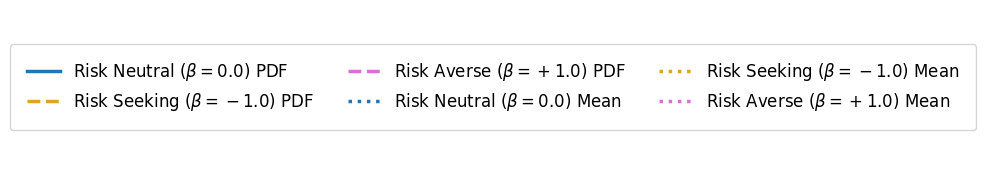

In [2]:
import matplotlib.pyplot as plt

# Create a small, wide figure
fig, ax = plt.subplots(figsize=(12, 2))

# 1. Spoof the data lines with your specific styles
# Risk Neutral (Solid/Dotted Blue)
pdf_neutral, = ax.plot([], [], color='tab:blue', linestyle='-', linewidth=2.5, 
                       label=r'Risk Neutral ($\beta=0.0$) PDF')
mean_neutral, = ax.plot([], [], color='tab:blue', linestyle=':', linewidth=2.5, 
                        label=r'Risk Neutral ($\beta=0.0$) Mean')

# Risk Seeking (Dashed/Dotted Gold)
pdf_seeking, = ax.plot([], [], color='goldenrod', linestyle='--', linewidth=2.5, 
                       label=r'Risk Seeking ($\beta=-1.0$) PDF')
mean_seeking, = ax.plot([], [], color='goldenrod', linestyle=':', linewidth=2.5, 
                        label=r'Risk Seeking ($\beta=-1.0$) Mean')

# Risk Averse (Dashed/Dotted Purple-Pink)
pdf_averse, = ax.plot([], [], color='orchid', linestyle='--', linewidth=2.5, 
                      label=r'Risk Averse ($\beta=+1.0$) PDF')
mean_averse, = ax.plot([], [], color='orchid', linestyle=':', linewidth=2.5, 
                       label=r'Risk Averse ($\beta=+1.0$) Mean')

# 2. Group the handles so PDFs are on the top row, Means on the bottom row
handles = [pdf_neutral, pdf_seeking, pdf_averse, 
           mean_neutral, mean_seeking, mean_averse]

# 3. Create the horizontal legend
legend = ax.legend(handles=handles, 
                   ncol=3,               # 3 columns to make it horizontal
                   loc='center',         # Center it in the figure
                   frameon=True,         # Keep the bounding box
                   fontsize=12,          # Bump up font size for readability
                   borderpad=1)          # Give the text some breathing room

# 4. Hide the axes entirely so ONLY the legend renders
ax.axis('off')

# 5. Export directly to SVG for Inkscape
plt.savefig('iros_horizontal_legend.pdf', format='pdf', bbox_inches='tight')
print("Legend saved as iros_horizontal_legend.svg!")